#Support for KDD submission 463 (2026)

In [ ]:
# ============================================================
# SETUP — get inputs (code + data) and configure output location
# ============================================================
# This notebook reproduces the DCNAR experiments for KDD '26 paper 463.
# Inputs (the src/ modules and data/my_data.csv) are pulled by cloning
# the public repository directly into the Colab session.

# 1) Clone the repository (inputs: source modules + data)
![ -d SIGKDD2026-463 ] || git clone https://github.com/vkuskova/SIGKDD2026-463.git

# 2) Put the source modules on the Python path so the
#    'from train_NAVAR import ...' style imports below resolve.
import sys, os
REPO = 'SIGKDD2026-463'
SRC  = os.path.join(REPO, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

# 3) (Optional) Mount Google Drive ONLY to persist outputs across sessions.
#    Colab sessions are ephemeral; results are also written locally under
#    ./outputs and can be downloaded directly without Drive.
USE_DRIVE = True  # set False to skip Drive and keep outputs in the session only
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    GDRIVE_OUT = '/content/drive/MyDrive/DCNAR/KDD_463_Responses'
    os.makedirs(GDRIVE_OUT, exist_ok=True)
else:
    GDRIVE_OUT = 'outputs'
    os.makedirs(GDRIVE_OUT, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#0. Install dependencies
!pip -q install numpy pandas scikit-learn torch #- required libraries or
#!pip -q install -r requirements.txt # from requirements file

In [ ]:
# ============================================================
# DCNAR Paper Routine (END-TO-END)
#
# Assumptions:
# - You have: navar_tvnar_pipeline.run_navar_tvnar and PanelSpec
# - You have other required DCNAR routines, including NAVAR.py, tvNAR.py, etc.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional
from train_NAVAR import train_NAVAR

from sklearn.linear_model import Ridge, MultiTaskElasticNet

# Optional LSTM
USE_LSTM = True
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
except Exception:
    USE_LSTM = False

In [ ]:
# -----------------------------
# Step 0. Config
# -----------------------------

@dataclass
class CFG:
    data_path: str = "SIGKDD2026-463/data/my_data.csv"
    country_col: str = "country_id"
    time_col: str = "year"
    dropna: bool = True

    # global split
    train_years: int = 25
    val_years: int = 10
    H_eval: int = 10
    H_irf: int = 10

    # NAVAR / tvNAR
    maxlags: int = 8
    tvnar_lags: int = 1
    tvnar_lambda_policy: str = "last"  # "last" or "mean"

    # structure supply
    top_k: int = 4
    alpha_dm: float = 0.05
    keep_self: bool = False
    normalize_rows: bool = False  # keep consistent with your previous runs

    # DM ablation settings (to obtain pvals)
    use_edge_ablation_for_pvals: bool = True
    ablation_val_proportion: float = 0.10
    ablation_normalize_for_eval: bool = True
    ablation_batch_size: int = 512

    # Baselines
    ridge_p: int = 1
    ridge_alpha_grid: Tuple[float, ...] = (0.01, 0.1, 1.0, 10.0, 100.0, 1000.0)

    enet_p: int = 1
    enet_alpha_grid: Tuple[float, ...] = (0.01, 0.1, 1.0, 10.0, 100.0)
    enet_l1_ratio_grid: Tuple[float, ...] = (0.1, 0.5, 0.9)

    tune_h: int = 10  # fixed, leak-free internal tuning horizon

    # fan charts
    B_paths: int = 500
    block_len: int = 7

    # LSTM
    lstm_seq_len: int = 8
    lstm_hidden: int = 64
    lstm_layers: int = 1
    lstm_dropout: float = 0.2
    lstm_epochs: int = 60
    lstm_batch: int = 256
    lstm_lr: float = 1e-3
    lstm_mc_samples: int = 500

    out_dir: str = "paper_run_unionW"


cfg = CFG(
    data_path="SIGKDD2026-463/data/my_data.csv",
    train_years=25,
    val_years=10,
    H_eval=10,
    H_irf=10,
    normalize_rows=False,
)

#assert cfg.H_eval == cfg.val_years, "Set H_eval == val_years for clean indexing."

In [ ]:
# -----------------------------
# Step 1. Load data (encoding-safe) and infer var_cols
# -----------------------------

def read_csv_robust(path: str) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin1")

def infer_var_cols(df: pd.DataFrame, country_col: str, time_col: str) -> List[str]:
    cols = [c for c in df.columns if c not in (country_col, time_col)]
    cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    return cols

df = read_csv_robust(cfg.data_path)
var_cols = infer_var_cols(df, cfg.country_col, cfg.time_col)

if cfg.dropna:
    df = df.dropna(subset=var_cols).copy()

df = df.sort_values([cfg.country_col, cfg.time_col]).reset_index(drop=True)

print("Loaded:", df.shape, "N vars:", len(var_cols))

Loaded: (4865, 18) N vars: 16


In [ ]:
# -----------------------------
# Step 2. Global split (same for all methods)
# -----------------------------

def panel_split_fixed_lengths(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, List]:
    train_parts, val_parts, valid = [], [], []
    for cid, g in df.groupby(cfg.country_col, sort=False):
        g = g.sort_values(cfg.time_col)
        if len(g) < cfg.train_years + cfg.val_years:
            continue
        tr = g.iloc[:cfg.train_years].copy()
        va = g.iloc[cfg.train_years:cfg.train_years + cfg.val_years].copy()
        if len(tr) == cfg.train_years and len(va) == cfg.val_years:
            train_parts.append(tr)
            val_parts.append(va)
            valid.append(cid)
    if not valid:
        raise ValueError("No countries satisfy train_years + val_years.")
    return pd.concat(train_parts, ignore_index=True), pd.concat(val_parts, ignore_index=True), valid

train_df, val_df, valid_countries = panel_split_fixed_lengths(df)
print("Countries:", len(valid_countries), "train rows:", len(train_df), "val rows:", len(val_df))

Countries: 139 train rows: 3475 val rows: 1390


In [ ]:
# Re-infer variable columns from THIS dataset and THIS split
var_cols = [
    c for c in train_df.columns
    if c not in (cfg.country_col, cfg.time_col)
    and np.issubdtype(train_df[c].dtype, np.number)
]

print("Recomputed var_cols from train_df:", len(var_cols))
print("Example vars:", var_cols[:10])



Recomputed var_cols from train_df: 16
Example vars: ['Freedom_of_expression', 'Freedom_of_association', 'Suffrage', 'Clean_elections', 'Elected_officials', 'Individual_liberty', 'Judicial_constraints', 'Legislative_constraints', 'Civil_participation', 'Direct_vote']


In [ ]:
# ------------------------------------------------------------
# Step 3. Train NAVAR on TRAIN ONLY and extract S (+ optional DM pvals)
# ------------------------------------------------------------

import os
import numpy as np
import pandas as pd

from navar_tvnar_pipeline import run_navar_tvnar, PanelSpec

def get_navar_scores(results: dict) -> np.ndarray:
    navar = results.get("navar", {})
    if "S" in navar:
        return np.asarray(navar["S"], float)
    if "causal_matrix" in navar:
        return np.asarray(navar["causal_matrix"], float)
    if "causal_matrix" in results:
        return np.asarray(results["causal_matrix"], float)
    raise KeyError("NAVAR scores not found. Inspect results['navar'].keys().")

def find_pvals_df(results: dict):
    # primary location
    navar_blk = results.get("navar", {})
    na = navar_blk.get("network_artifacts", None)
    if isinstance(na, dict) and na.get("pvals_df", None) is not None:
        return na["pvals_df"]
    # fallbacks
    for key in ["artifacts", "network_artifacts", "ablation", "edge_ablation"]:
        blk = results.get(key, None)
        if isinstance(blk, dict) and blk.get("pvals_df", None) is not None:
            return blk["pvals_df"]
    return None

def run_navar_train_only(train_df: pd.DataFrame, var_cols: list[str], cfg) -> dict:
    os.makedirs(cfg.out_dir, exist_ok=True)
    train_path = os.path.join(cfg.out_dir, "train_only.csv")

    train_df_sorted = train_df.sort_values([cfg.country_col, cfg.time_col]).reset_index(drop=True)
    train_df_sorted.to_csv(train_path, index=False)

    # Run pipeline to train NAVAR and (optionally) compute DM p-values.
    # We don't rely on pipeline W; we will build W variants ourselves in Step 4.5.
    res = run_navar_tvnar(
        csv_path=train_path,
        out_dir=None,
        panel=PanelSpec(country_col=cfg.country_col, time_col=cfg.time_col, variable_cols=var_cols, sort=True),
        dropna=True,

        # NAVAR hyperparams
        maxlags=cfg.maxlags,
        hidden_nodes=16,
        epochs=300,
        learning_rate=3e-4,
        batch_size=128,
        lambda1=0.15,
        dropout=0.1,
        weight_decay=0.001,
        hidden_layers=1,
        normalize=False,

        # network params ignored for our W variants
        navar_matrix_transpose=False,
        network_method="topk",
        top_k=cfg.top_k,
        keep_self=cfg.keep_self,
        normalize_rows=False,   # IMPORTANT: do NOT force mixture weights here

        # DM p-values (optional)
        use_edge_ablation=True,
        edge_ablation_keep_all_sig=False,
        alpha=cfg.alpha_dm,
        ablation_val_proportion=cfg.ablation_val_proportion,
        ablation_normalize_for_eval=cfg.ablation_normalize_for_eval,
        ablation_batch_size=cfg.ablation_batch_size,

        # tvNAR args (ignored; we will fit ourselves)
        tvnar_lags=1,
        grid_size=50,
        bandwidth=0.2,
        kernel="gaussian",
        ridge=1e-4,
        tau_mode="within_series",
        center=False,
    )

    S = get_navar_scores(res)
    pvals_df = find_pvals_df(res)

    # Panel split spec for tvNAR later
    lengths = train_df_sorted.groupby(cfg.country_col, sort=False).size().tolist()
    split_spec = lengths[0] if len(set(lengths)) == 1 else lengths

    return {
        "train_df_sorted": train_df_sorted,
        "train_path": train_path,
        "S": S,
        "pvals_df": pvals_df,
        "split_spec": split_spec,
        "pipeline_raw": res,
    }

NAVAR_OUT = run_navar_train_only(train_df, var_cols, cfg)
S = NAVAR_OUT["S"]
pvals_df = NAVAR_OUT["pvals_df"]
split_spec = NAVAR_OUT["split_spec"]

print("NAVAR S shape:", S.shape, "| pvals_df available:", pvals_df is not None)
# ============================================================
# DEFINE Y_train ONCE (authoritative training matrix)
# ============================================================
train_df_sorted = NAVAR_OUT["train_df_sorted"]   # <-- THIS is the only valid source
Y_train = train_df_sorted[var_cols].to_numpy(float)
T, V = Y_train.shape

print("Defined Y_train:", Y_train.shape)



iteration 30. Loss: 0.37566474080085754  Val loss: 0
iteration 60. Loss: 0.1403285712003708  Val loss: 0
iteration 90. Loss: 0.09999826550483704  Val loss: 0
iteration 120. Loss: 0.07785876840353012  Val loss: 0
iteration 150. Loss: 0.061794448643922806  Val loss: 0
iteration 180. Loss: 0.04997860640287399  Val loss: 0
iteration 210. Loss: 0.04145524278283119  Val loss: 0
iteration 240. Loss: 0.03607724606990814  Val loss: 0
iteration 270. Loss: 0.033660657703876495  Val loss: 0
iteration 300. Loss: 0.03270109370350838  Val loss: 0
Computing FULL predictions on validation windows: 236 ...
Ablating source 1/16: Freedom_of_expression ...
Ablating source 2/16: Freedom_of_association ...
Ablating source 3/16: Suffrage ...
Ablating source 4/16: Clean_elections ...
Ablating source 5/16: Elected_officials ...
Ablating source 6/16: Individual_liberty ...
Ablating source 7/16: Judicial_constraints ...
Ablating source 8/16: Legislative_constraints ...
Ablating source 9/16: Civil_participation ..

In [ ]:
# ------------------------------------------------------------
# Step 4  Build candidate W variants
# ------------------------------------------------------------

# Design principles enforced here:
# - Directionality explicit (row = outgoing influence)
# - Top-k by |S| (not by sign)
# - Binary edges by |S| > 0
# - Diagonal always zeroed (self-dynamics handled by lags)
# - Optional, safe row-normalization (L1 over abs)
# - DM p-values aligned to var_cols

import numpy as np

# ----------------------------
# Utilities
# ----------------------------

def zero_diagonal(W: np.ndarray) -> np.ndarray:
    W = W.copy()
    np.fill_diagonal(W, 0.0)
    return W


def row_normalize_L1_signed(W: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Row-normalize by L1 norm (sum of absolute weights), sign-preserving.
    """
    W = np.asarray(W, float)
    denom = np.sum(np.abs(W), axis=1, keepdims=True)
    denom = np.where(denom < eps, 1.0, denom)
    return W / denom
# ----------------------------
# Mask construction
# ----------------------------

def make_mask_topk_by_magnitude(
    S: np.ndarray,
    k: int,
    keep_self: bool = False
) -> np.ndarray:
    """
    Row-wise top-k selection by |S|.
    """
    S = np.asarray(S, float)
    N = S.shape[0]
    M = np.zeros((N, N), dtype=bool)

    for i in range(N):
        row = S[i].copy()
        if not keep_self:
            row[i] = 0.0

        idx = np.argsort(np.abs(row))[::-1][:k]
        idx = idx[np.abs(row[idx]) > 0]
        M[i, idx] = True

    if not keep_self:
        np.fill_diagonal(M, False)

    return M

# ----------------------------
# W builders
# ----------------------------

def make_W_dense(
    S: np.ndarray,
    binary: bool
) -> np.ndarray:
    """
    Dense W baseline (all non-self edges).
    """
    W = np.asarray(S, float).copy()
    W = zero_diagonal(W)
    if binary:
        W = (np.abs(W) > 0).astype(float)
    return W
def make_W_from_mask(
    S: np.ndarray,
    M: np.ndarray,
    binary: bool
) -> np.ndarray:
    """
    Masked W using original signed weights.
    """
    S = np.asarray(S, float)
    M = np.asarray(M, bool)

    W = np.where(M, S, 0.0)

    if binary:
        W = (np.abs(W) > 0).astype(float)

    return zero_diagonal(W)

# ----------------------------
# Build masks
# ----------------------------

# Top-k mask (by magnitude)
M_topk = make_mask_topk_by_magnitude(
    S,
    k=cfg.top_k,
    keep_self=cfg.keep_self
)
# DM-based mask (if available)
if pvals_df is not None:
    P = (
        pvals_df
        .reindex(index=var_cols, columns=var_cols)
        .to_numpy(float)
    )
    M_dm = (P < cfg.alpha_dm)
    if not cfg.keep_self:
        np.fill_diagonal(M_dm, False)
else:
    M_dm = None

if M_dm is None:
    print("NOTE: pvals_df not available; cannot build navar_ablated variants.")
else:
    # Pure ablation mask (DM only)
    M_abl = M_dm.copy()
    if not cfg.keep_self:
        np.fill_diagonal(M_abl, False)
# Union mask
M_union = M_topk if M_dm is None else (M_topk | M_dm)
# ----------------------------
# Assemble W variants
# ----------------------------

W_VARIANTS = {
    # Dense baselines
    "navar_dense_weighted": make_W_dense(S, binary=False),
    "navar_dense_binary":   make_W_dense(S, binary=True),
    #Ablated
    "navar_ablated_weighted": make_W_from_mask(S, M_abl, binary=False),
    "navar_ablated_binary": make_W_from_mask(S, M_abl, binary=True),
    # Top-k structure
    "topk_weighted":        make_W_from_mask(S, M_topk, binary=False),
    "topk_binary":          make_W_from_mask(S, M_topk, binary=True),
    # Union (top-k ∪ DM)
    "union_weighted":       make_W_from_mask(S, M_union, binary=False),
    "union_binary":         make_W_from_mask(S, M_union, binary=True),
}

# Optional row-normalized variants (safe)
if getattr(cfg, "normalize_rows", False):
    for name, W in list(W_VARIANTS.items()):
        W_VARIANTS[name + "_rownorm"] = row_normalize_L1_signed(W)
# ----------------------------
# Sanity checks
# ----------------------------
V = len(var_cols)
for name, W in W_VARIANTS.items():
    if W.shape != (V, V):
        raise ValueError(f"W[{name}] has shape {W.shape}, expected {(V, V)}")
    if not cfg.keep_self and not np.allclose(np.diag(W), 0.0):
        raise ValueError(f"W[{name}] has nonzero diagonal entries")

print("Built W variants:")
for name, W in W_VARIANTS.items():
    nnz = int((np.abs(W) > 0).sum())
    print(f"  {name:22s} | nnz = {nnz:4d}")


Built W variants:
  navar_dense_weighted   | nnz =  240
  navar_dense_binary     | nnz =  240
  navar_ablated_weighted | nnz =  155
  navar_ablated_binary   | nnz =  155
  topk_weighted          | nnz =   64
  topk_binary            | nnz =   64
  union_weighted         | nnz =  173
  union_binary           | nnz =  173


In [ ]:
# ------------------------------------------------------------
# Step 4.5  Select the needed matrix
# ------------------------------------------------------------
# Best choice (from prior experiments is ablated weighted matrix)
ACTIVE_W_NAME = "navar_ablated_weighted"
assert ACTIVE_W_NAME in W_VARIANTS

W_active = W_VARIANTS[ACTIVE_W_NAME]
print("ACTIVE W =", ACTIVE_W_NAME, "| shape:", W_active.shape)


ACTIVE W = navar_ablated_weighted | shape: (16, 16)


In [ ]:
# ------------------------------------------------------------
# Step 4.5.1  Optional export navar causal matrix
# ------------------------------------------------------------

import pandas as pd

# Create labeled causal matrix
causal_df = pd.DataFrame(
    W_active
)

# Save WITH row & column names
causal_df.to_csv("navar_causal_matrix.csv")


In [ ]:
# ============================================================
# STEPS 5–11 — tvNAR with comparison to other methods
# ============================================================
# Requires from Steps 1–4.5:
#   - cfg, train_df, val_df, valid_countries, var_cols
#   - W_VARIANTS: dict[str] -> (N,N)
#   - TVNAR_FITS: dict[str] -> {"tv":..., "lam_vecs":...} (from fit_tvnar_on_W)
#   - ACTIVE_W_NAME: str
#
# Also requires baseline helpers already in your notebook:
#   - ridge_fit, ridge_forecast, ridge_fan_paths
#   - enet_fit, enet_forecast, enet_fan_paths
# Optional:
#   - lstm_prob_summary, lstm_irf_vec (if you trained LSTM earlier)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Tuple


In [ ]:
# ------------------------------------------------------------
# Step 5  Train tvNAR  (now also produces lam_vecs[p, N])
# ------------------------------------------------------------
from tvNAR import fit_tvNAR_lambda_paths
import numpy as np

def tvnar_one_step_with_active_W(
    Y: np.ndarray,
    W_variants: dict,
    active_w_name: str = ACTIVE_W_NAME,
    t_idx: int | None = None,
    bandwidth: float = 0.2,
    ridge: float = 1e-4,
    kernel: str = "gaussian",
    center: bool = False,
):
    # ---- validate inputs ----
    Y = np.asarray(Y, float)
    if Y.ndim != 2:
        raise ValueError(f"Y must be 2D [T,N], got shape {Y.shape}")
    T, N = Y.shape

    if active_w_name not in W_variants:
        raise KeyError(f"active_w_name='{active_w_name}' not in W_variants. Available: {list(W_variants.keys())[:10]}...")

    W_active = np.asarray(W_variants[active_w_name], float)
    if W_active.shape != (N, N):
        raise ValueError(f"W_active shape {W_active.shape} does not match (N,N)=({N},{N}).")

    if t_idx is None:
        t_idx = T - 1
    t_idx = int(t_idx)
    if t_idx < 2 or t_idx >= T:
        raise ValueError(f"t_idx must satisfy 2 <= t_idx < T. Got t_idx={t_idx}, T={T}.")

    # Optional centering
    if center:
        mu = Y[:t_idx].mean(axis=0, keepdims=True)
        Yc = Y - mu
    else:
        Yc = Y

    W_hat = W_active + np.eye(N)

    tau = t_idx / T
    taus = np.arange(1, t_idx) / T
    u = (taus - tau) / bandwidth

    if kernel == "gaussian":
        w = np.exp(-0.5 * u * u)
    elif kernel == "epanechnikov":
        w = 0.75 * (1.0 - u * u) * (np.abs(u) <= 1.0)
    else:
        raise ValueError("kernel must be 'gaussian' or 'epanechnikov'")

    w_sum = float(w.sum())
    if w_sum <= 0:
        raise ValueError("All kernel weights are zero; increase bandwidth or choose a different t_idx.")
    w = w / (w_sum + 1e-12)

    X_blocks = []
    y_blocks = []
    for s, ws in zip(range(1, t_idx), w):
        y_prev = Yc[s - 1]
        X_s = W_hat * y_prev[None, :]
        X_blocks.append(np.sqrt(ws) * X_s)
        y_blocks.append(np.sqrt(ws) * Yc[s])

    X = np.vstack(X_blocks)
    y_vec = np.concatenate(y_blocks, axis=0)

    XtX = X.T @ X + ridge * np.eye(N)
    Xty = X.T @ y_vec
    lambda_hat = np.linalg.solve(XtX, Xty)

    y_prev = Yc[t_idx - 1]
    X_tminus1 = W_hat * y_prev[None, :]
    y_hat = X_tminus1 @ lambda_hat

    if center:
        y_hat = y_hat + mu.ravel()

    return {
        "W_active": W_active,
        "active_w_name": active_w_name,
        "t_idx": t_idx,
        "tau": tau,
        "lambda_hat": lambda_hat,
        "y_hat": y_hat,
    }


# ----------------------------
# (A) One-step tvNAR sanity call (optional)
# ----------------------------
out = tvnar_one_step_with_active_W(
    Y=Y_train,
    W_variants=W_VARIANTS,
    active_w_name=ACTIVE_W_NAME,
    t_idx=None,
    bandwidth=float(getattr(cfg, "bandwidth", 0.2)) if hasattr(cfg, "bandwidth") else 0.2,
    ridge=float(getattr(cfg, "tvnar_ridge", 1e-4)) if hasattr(cfg, "tvnar_ridge") else 1e-4,
    kernel="gaussian",
    center=False,
)

print("ACTIVE W =", out["active_w_name"])
print("t_idx =", out["t_idx"], "| tau =", out["tau"])
print("lambda_hat shape:", out["lambda_hat"].shape)
print("y_hat shape:", out["y_hat"].shape)


# ----------------------------
# (B) Fit tvNAR properly and create lam_vecs[p, N] for IRFs
#     This is the piece that was missing.
# ----------------------------
W_active = np.asarray(W_VARIANTS[ACTIVE_W_NAME], float)

tv = fit_tvNAR_lambda_paths(
    Y=Y_train,
    W=W_active,
    split_timeseries=split_spec,      # from NAVAR_OUT
    grid_size=50,
    bandwidth=float(getattr(cfg, "bandwidth", 0.2)) if hasattr(cfg, "bandwidth") else 0.2,
    kernel="gaussian",
    ridge=float(getattr(cfg, "tvnar_ridge", 1e-4)) if hasattr(cfg, "tvnar_ridge") else 1e-4,
    tau_mode="within_series",
    center=False,
)

lam_grid = np.asarray(tv["lambda"], float)      # [grid_size, N]
lam_last = lam_grid[-1] if cfg.tvnar_lambda_policy == "last" else lam_grid.mean(axis=0)

p = int(getattr(cfg, "tvnar_lags", 1))
lam_vecs = np.vstack([lam_last[None, :] for _ in range(p)])   # [p, N]

print("tvNAR fit complete | lambda grid:", lam_grid.shape, "| lam_vecs:", lam_vecs.shape)

# Optionally store for downstream use
TVNAR_FIT = {"tv": tv, "lam_grid": lam_grid, "lam_vecs": lam_vecs, "W_active": W_active}


ACTIVE W = navar_ablated_weighted
t_idx = 3474 | tau = 0.9997122302158273
lambda_hat shape: (16,)
y_hat shape: (16,)
tvNAR fit complete | lambda grid: (50, 16) | lam_vecs: (1, 16)


In [ ]:
# ------------------------------------------------------------
# Step 6  empirical predictive distribution accuracy (CRPS)
# ------------------------------------------------------------


# End-to-end: empirical predictive distribution accuracy (CRPS)
# comparing: VAR (ridge VAR(1)), TV-VAR (kernel-weighted ridge VAR(1)),
# LSTM (MC Dropout), and DCNAR (one-step tvNAR using ACTIVE_W from NAVAR).
#
# Assumes you already have (from your NAVAR run):
#   - train_df_sorted  (DataFrame used to train NAVAR)
#   - var_cols         (list of variable column names)
#   - W_VARIANTS       (dict of W variants built in Step 4.5)
#   - ACTIVE_W_NAME    (string key into W_VARIANTS)

import numpy as np

# ----------------------------
# 0) Grab training data (same data NAVAR was run on)
# ----------------------------
#Y_train = train_df_sorted[var_cols].to_numpy(float)  # [T, V] #Should use global Y_train above
T, V = Y_train.shape

# Evaluation setup: last H points of *training* (rolling one-step evaluation)
H = int(getattr(cfg, "H_eval", 10))
H = max(5, min(H, T - 3))
fit_end = T - H                      # fit models on Y_train[:fit_end]
eval_indices = np.arange(fit_end, T) # evaluate one-step at these t's (predict Y[t] from history <= t-1)

B = int(getattr(cfg, "B_paths", 500))  # number of predictive draws per t
B = max(50, B)

rng = np.random.default_rng(getattr(cfg, "seed", 1))

In [ ]:
# ----------------------------
# Step 6.1 Proper score: CRPS for empirical samples (fast O(B log B))
# ----------------------------
def crps_1d_from_samples(samples_1d: np.ndarray, y_true: float) -> float:
    """
    CRPS for empirical samples in 1D using sorted-sample closed form.
    samples_1d: [B]
    """
    x = np.sort(samples_1d.astype(float))
    Bn = x.size
    # term1 = E|X - y|
    term1 = np.mean(np.abs(x - y_true))
    # term2 = 0.5 E|X - X'| computed from sorted samples:
    # sum_{i,j} |x_i - x_j| = 2 * sum_{i=1..B} (2i - B - 1) x_i
    i = np.arange(1, Bn + 1, dtype=float)
    sum_abs = 2.0 * np.sum((2.0 * i - Bn - 1.0) * x)
    term2 = 0.5 * (sum_abs / (Bn * Bn))
    return float(term1 - term2)

def crps_mean(Y_true: np.ndarray, Y_samps: np.ndarray) -> float:
    """
    Mean CRPS over time and variables.
    Y_true:  [H, V]
    Y_samps: [B, H, V]
    """
    Bn, Hn, Vn = Y_samps.shape
    total = 0.0
    count = 0
    for h in range(Hn):
        for v in range(Vn):
            total += crps_1d_from_samples(Y_samps[:, h, v], Y_true[h, v])
            count += 1
    return total / max(count, 1)

In [ ]:
# ----------------------------
# Step 6.2 VAR(1) ridge (constant coefficient matrix)
# ----------------------------
def fit_var1_ridge(Y: np.ndarray, ridge: float = 1e-4):
    """
    Fit Y_t = A Y_{t-1} + e_t for t=1..T-1.
    Returns A [V, V], residuals [T-1, V]
    """
    Y0 = Y[:-1]   # [T-1, V]
    Y1 = Y[1:]    # [T-1, V]
    XtX = Y0.T @ Y0 + ridge * np.eye(V)
    A_T = np.linalg.solve(XtX, Y0.T @ Y1)  # [V, V]  (this is A^T if you think in rows)
    A = A_T.T                               # [V, V]
    resid = Y1 - (Y0 @ A.T)                 # [T-1, V]
    return A, resid

def var1_bootstrap_sampler(A: np.ndarray, resid_pool: np.ndarray, y_prev: np.ndarray, B: int):
    """
    Empirical predictive draws for Y_t given Y_{t-1}=y_prev:
      y_hat = A y_prev + e*, with e* resampled from residual pool.
    Returns [B, V].
    """
    idx = rng.integers(0, resid_pool.shape[0], size=B)
    eps = resid_pool[idx]  # [B, V]
    base = (A @ y_prev)    # [V]
    return base[None, :] + eps


In [ ]:
# ----------------------------
# Step 6.3 TV-VAR(1): kernel-weighted ridge, estimate A(t*) locally
# ----------------------------
def kernel_weights(taus: np.ndarray, tau_star: float, bandwidth: float, kernel: str = "gaussian"):
    u = (taus - tau_star) / bandwidth
    if kernel == "gaussian":
        w = np.exp(-0.5 * u * u)
    elif kernel == "epanechnikov":
        w = 0.75 * (1.0 - u * u) * (np.abs(u) <= 1.0)
    else:
        raise ValueError("kernel must be 'gaussian' or 'epanechnikov'")
    s = float(w.sum())
    if s <= 0:
        w = np.ones_like(w)
        s = float(w.sum())
    return w / (s + 1e-12)

def fit_tvvar1_local_A(Y_fit: np.ndarray, t_star_in_fit: int, bandwidth: float = 0.2, ridge: float = 1e-4, kernel: str = "gaussian"):
    """
    Local (kernel) ridge estimate of A(t*) using Y_fit only.
    Y_fit: [Tfit, V]
    t_star_in_fit: index in [1..Tfit-1] representing the prediction time within fit segment
    Uses samples s=1..Tfit-1, weights around tau_star = t_star/Tfit.
    Returns A_star [V,V] and a weighted residual pool [Tfit-1,V] to bootstrap from.
    """
    Tfit = Y_fit.shape[0]
    # build regression pairs
    Y0 = Y_fit[:-1]  # [Tfit-1,V]
    Y1 = Y_fit[1:]   # [Tfit-1,V]
    taus = np.arange(1, Tfit) / Tfit
    tau_star = t_star_in_fit / Tfit
    w = kernel_weights(taus, tau_star, bandwidth, kernel=kernel)  # [Tfit-1]
    sw = np.sqrt(w)[:, None]  # [Tfit-1,1]
    Xw = Y0 * sw
    Yw = Y1 * sw

    XtX = Xw.T @ Xw + ridge * np.eye(V)
    A_T = np.linalg.solve(XtX, Xw.T @ Yw)
    A = A_T.T
    resid = Y1 - (Y0 @ A.T)   # [Tfit-1,V]

    # Create a residual sampling pool that respects weights (importance resampling)
    # We'll sample indices proportional to w when drawing eps.
    return A, resid, w

def tvvar1_sampler(Y_fit: np.ndarray, t_star_global: int, bandwidth: float, ridge: float, kernel: str, B: int):
    """
    Produce B empirical draws for Y[t_star] given history, using local A(t*).
    """
    # Map global t* (in full training) into local coordinates within Y_fit
    # We fit using Y_fit = Y_train[:fit_end]. For evaluation points, t_star_global is in [fit_end..T-1],
    # but local A(t*) should be estimated from fit data only. So we anchor A at the end of fit window.
    # Use t_star_in_fit = Tfit-1 (last feasible) as best approximation.
    Tfit = Y_fit.shape[0]
    t_star_in_fit = Tfit - 1
    A_star, resid, w = fit_tvvar1_local_A(Y_fit, t_star_in_fit, bandwidth=bandwidth, ridge=ridge, kernel=kernel)

    # residual importance resampling
    idx = rng.choice(np.arange(resid.shape[0]), size=B, replace=True, p=w / (w.sum() + 1e-12))
    eps = resid[idx]
    y_prev = Y_train[t_star_global - 1]
    base = (A_star @ y_prev)
    return base[None, :] + eps

In [ ]:
# ----------------------------
# Step 7 tvNAR one-step (paper form), using ACTIVE_W from NAVAR
#     Model: Y_t = X_{t-1} lambda(tau_t) + e_t, with X_{t-1} = (W+I) ⊙ Y_{t-1}
# ----------------------------
def tvnar_lambda_hat(Y_fit: np.ndarray, W: np.ndarray, t_idx: int, bandwidth: float = 0.2, ridge: float = 1e-4, kernel: str = "gaussian"):
    """
    Estimate lambda(tau_t) using kernel-weighted ridge on fit data up to t_idx-1 (within Y_fit).
    t_idx must satisfy 2 <= t_idx < len(Y_fit).
    Returns lambda_hat [V].
    """
    Tfit = Y_fit.shape[0]
    if not (2 <= t_idx < Tfit):
        raise ValueError("t_idx out of bounds for tvnar_lambda_hat")

    tau = t_idx / Tfit
    taus = np.arange(1, t_idx) / Tfit
    w = kernel_weights(taus, tau, bandwidth, kernel=kernel)  # [t_idx-1]

    W_hat = W + np.eye(V)

    X_blocks = []
    y_blocks = []
    for s, ws in zip(range(1, t_idx), w):
        y_prev = Y_fit[s - 1]                 # [V]
        X_s = W_hat * y_prev[None, :]         # [V,V]
        X_blocks.append(np.sqrt(ws) * X_s)
        y_blocks.append(np.sqrt(ws) * Y_fit[s])

    X = np.vstack(X_blocks)                  # [(t_idx-1)*V, V]
    y_vec = np.concatenate(y_blocks, axis=0) # [(t_idx-1)*V]

    XtX = X.T @ X + ridge * np.eye(V)
    Xty = X.T @ y_vec
    return np.linalg.solve(XtX, Xty)

def tvnar_one_step_mean(Y_fit: np.ndarray, W: np.ndarray, t_idx: int, bandwidth: float, ridge: float, kernel: str):
    """
    Deterministic mean prediction for Y_fit[t_idx] based on lambda_hat(t_idx).
    """
    lam = tvnar_lambda_hat(Y_fit, W, t_idx, bandwidth=bandwidth, ridge=ridge, kernel=kernel)
    W_hat = W + np.eye(V)
    y_prev = Y_fit[t_idx - 1]
    y_hat = (W_hat * y_prev[None, :]) @ lam
    return y_hat, lam

def tvnar_sampler(Y_fit: np.ndarray, W: np.ndarray, t_star_global: int, bandwidth: float, ridge: float, kernel: str, B: int):
    """
    Empirical predictive draws for Y[t_star_global] using:
      mean tvNAR one-step + resampled residuals from a recent residual pool within Y_fit.
    """
    # Use last feasible index in fit segment to estimate time-varying lambda and residual pool.
    Tfit = Y_fit.shape[0]
    t_idx = Tfit - 1

    # Build residual pool from the last R points inside fit (compute mean predictions + residuals)
    R = min(300, Tfit - 2)
    start = max(2, Tfit - R)
    resid_pool = []
    for tt in range(start, Tfit):
        y_hat_tt, _ = tvnar_one_step_mean(Y_fit, W, tt, bandwidth=bandwidth, ridge=ridge, kernel=kernel)
        resid_pool.append(Y_fit[tt] - y_hat_tt)
    resid_pool = np.vstack(resid_pool)  # [R-?, V]

    # Mean at the evaluation point (use the last fit lambda as local approximation)
    # For strict purity, we keep all non-tvNAR models fit on Y_fit and tvNAR also uses Y_fit.
    # Predict at t_star_global from actual y_prev in full training (still inside training range).
    y_prev = Y_train[t_star_global - 1]
    # Estimate lambda at end-of-fit and use it
    lam_end = tvnar_lambda_hat(Y_fit, W, t_idx, bandwidth=bandwidth, ridge=ridge, kernel=kernel)
    W_hat = W + np.eye(V)
    mean_pred = (W_hat * y_prev[None, :]) @ lam_end

    idx = rng.integers(0, resid_pool.shape[0], size=B)
    eps = resid_pool[idx]
    return mean_pred[None, :] + eps

Running bandwidth sensitivity analysis...
Bandwidths: [0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
Countries: ['Albania', 'United States of America', 'Mexico']
Shock variable: Freedom_of_expression

Computing CRPS for each bandwidth...
  bandwidth=0.05... CRPS=0.016159
  bandwidth=0.10... CRPS=0.016218
  bandwidth=0.15... CRPS=0.016243
  bandwidth=0.20... CRPS=0.016261
  bandwidth=0.30... CRPS=0.016286
  bandwidth=0.40... CRPS=0.016302

Computing IRF properties for each bandwidth and country...

=== Table 1: CRPS by Bandwidth ===
               CRPS    Current
Bandwidth                     
0.05       0.016159           
0.10       0.016218           
0.15       0.016243           
0.20       0.016261  ← current
0.30       0.016286           
0.40       0.016302           

=== Table 2: IRF Qualitative Properties by Bandwidth ===
                 Country  Bandwidth  Sign consistent  Monotonic  Sign changes  Peak horizon Current
                 Albania       0.05             True       True       

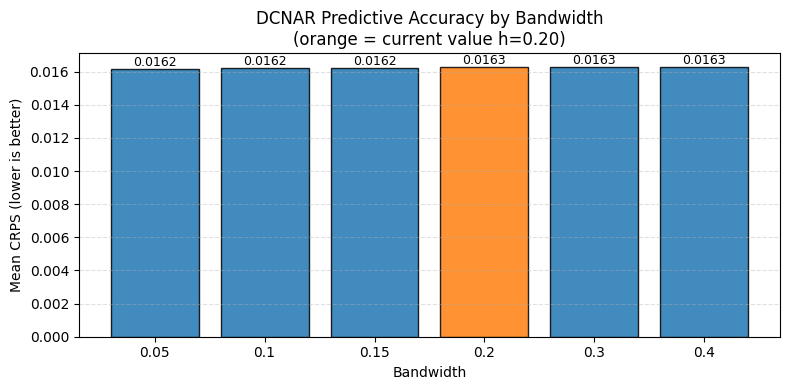

Saved: crps_by_bandwidth.png


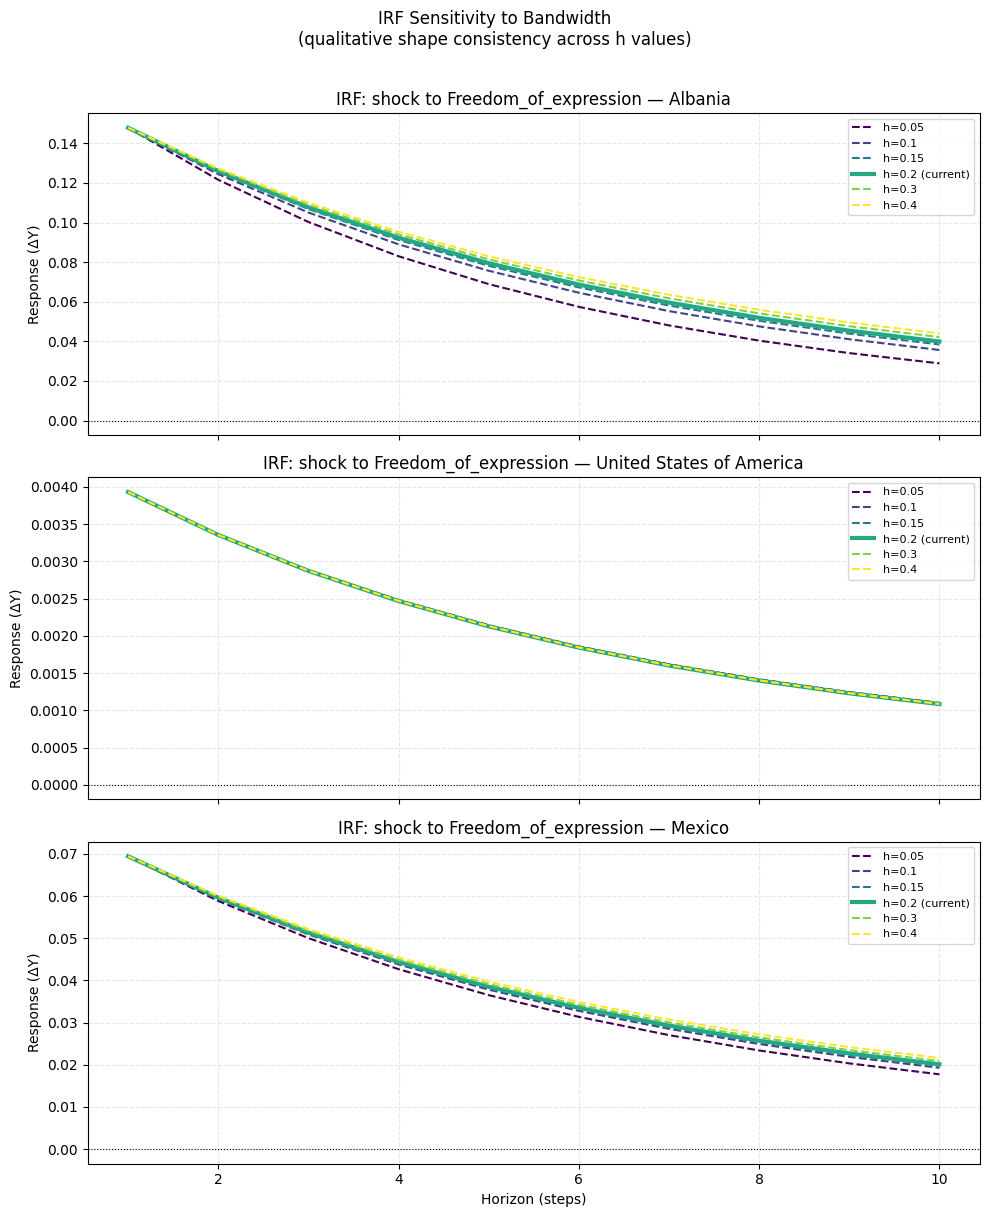

Saved: irf_by_bandwidth.png

=== REBUTTAL SUMMARY ===

CRPS by bandwidth (for table in rebuttal):
   Bandwidth       CRPS         Note
------------------------------------
        0.05   0.016159             
        0.10   0.016218             
        0.15   0.016243             
        0.20   0.016261  <-- current
        0.30   0.016286             
        0.40   0.016302             

IRF sign consistency across bandwidths:
Country                             Consistent across all bw?
--------------------------------------------------------------
Albania                                                   Yes
United States of America                                  Yes
Mexico                                                    Yes

All outputs saved to: paper_run_unionW/bandwidth_sensitivity


NameError: name 'GDRIVE_OUT' is not defined

In [ ]:
# ============================================================
# BANDWIDTH SENSITIVITY ANALYSIS
# (requires: tvnar_lambda_hat, tvnar_one_step_mean, kernel_weights,
#  Y_train, W_VARIANTS, ACTIVE_W_NAME, var_cols, cfg, fit_end)
# ============================================================

# -------------------------------------------------------
# 0. Google Drive mount (run this cell first in Colab)
# -------------------------------------------------------
# from google.colab import drive
# drive.mount('/content/drive')
# GDRIVE_OUT = "/content/drive/MyDrive/KDD_463_sensitivity"
# os.makedirs(GDRIVE_OUT, exist_ok=True)

# -------------------------------------------------------
# 1. Configuration
# -------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Output directory — change to GDRIVE_OUT if using Colab
SENS_OUT = os.path.join(cfg.out_dir, "bandwidth_sensitivity")
os.makedirs(SENS_OUT, exist_ok=True)

# Bandwidth grid — current value (0.2) is included
BANDWIDTHS = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40]
BW_CURRENT = 0.20  # highlight this in tables/plots

# Countries and shock variable for IRF analysis
COUNTRIES_SENS = ["Albania", "United States of America", "Mexico"]
SHOCK_VAR_NAME = "Freedom_of_expression" if "Freedom_of_expression" in var_cols else var_cols[0]
shock_var = var_cols.index(SHOCK_VAR_NAME)
H_sens = 10

# Fixed model parameters
W_active = np.asarray(W_VARIANTS[ACTIVE_W_NAME], float)
ridge_sens = float(getattr(cfg, "tvnar_ridge", 1e-4)) if hasattr(cfg, "tvnar_ridge") else 1e-4
V = len(var_cols)

# -------------------------------------------------------
# 2. Helper: get country series from training panel
# -------------------------------------------------------
def get_country_series_sens(country_name):
    sub = train_df_sorted[
        train_df_sorted[cfg.country_col] == country_name
    ].sort_values(cfg.time_col)
    if len(sub) == 0:
        raise KeyError(f"Country '{country_name}' not found.")
    return sub[var_cols].to_numpy(float)

# -------------------------------------------------------
# 3. Helper: run counterfactual IRF for one country + bandwidth
# -------------------------------------------------------
def run_irf_for_bandwidth(series_train, W, bandwidth, shock_var, H=10,
                           ridge=1e-4, kernel="gaussian"):
    """
    Returns delta IRF [H, V] = shocked_path - base_path.
    Uses one-sided kernel: taus = arange(1, t_idx) only.
    """
    L, N = series_train.shape
    if L < 3:
        return None

    # Estimate lambda at last training point
    t_idx = L - 1
    tau = t_idx / L
    taus = np.arange(1, t_idx) / L
    u = (taus - tau) / bandwidth

    if kernel == "gaussian":
        w = np.exp(-0.5 * u * u)
    elif kernel == "epanechnikov":
        w = 0.75 * (1.0 - u * u) * (np.abs(u) <= 1.0)
    else:
        raise ValueError("kernel must be 'gaussian' or 'epanechnikov'")

    w_sum = float(w.sum())
    if w_sum <= 0:
        return None
    w = w / (w_sum + 1e-12)

    W_hat = W + np.eye(N)
    X_blocks, y_blocks = [], []
    for s, ws in zip(range(1, t_idx), w):
        y_prev = series_train[s - 1]
        X_s = W_hat * y_prev[None, :]
        X_blocks.append(np.sqrt(ws) * X_s)
        y_blocks.append(np.sqrt(ws) * series_train[s])

    X = np.vstack(X_blocks)
    y_vec = np.concatenate(y_blocks)
    XtX = X.T @ X + ridge * np.eye(N)
    lam = np.linalg.solve(XtX, X.T @ y_vec)

    # Propagate base and shocked paths
    shock_size = float(np.std(series_train[:, shock_var]) + 1e-12)
    buf_base = series_train[-1:].copy()
    buf_shock = series_train[-1:].copy()

    base_path = np.zeros((H, N))
    shock_path = np.zeros((H, N))

    for h in range(H):
        y_prev_b = buf_base[-1]
        y_prev_s = buf_shock[-1]

        yhat_b = (W_hat * y_prev_b[None, :]) @ lam
        yhat_s = (W_hat * y_prev_s[None, :]) @ lam

        # Apply shock only at h=0
        if h == 0:
            yhat_s[shock_var] += shock_size

        base_path[h] = yhat_b
        shock_path[h] = yhat_s

        buf_base = np.vstack([buf_base, yhat_b])
        buf_shock = np.vstack([buf_shock, yhat_s])

    return shock_path - base_path  # [H, N]

# -------------------------------------------------------
# 4. Helper: IRF qualitative properties
# -------------------------------------------------------
def irf_properties(delta):
    """
    delta: [H, V] — IRF of shocked variable on itself (col = shock_var)
    Returns dict of qualitative properties for the shock variable response.
    """
    resp = delta[:, shock_var]
    sign_consistent = bool(np.all(resp >= 0) or np.all(resp <= 0))
    monotonic = bool(
        np.all(np.diff(resp) <= 0) or np.all(np.diff(resp) >= 0)
    )
    sign_changes = int(np.sum(np.diff(np.sign(resp)) != 0))
    peak_horizon = int(np.argmax(np.abs(resp))) + 1
    initial_sign = "positive" if resp[0] >= 0 else "negative"
    return {
        "sign_consistent": sign_consistent,
        "monotonic": monotonic,
        "sign_changes": sign_changes,
        "peak_horizon": peak_horizon,
        "initial_sign": initial_sign,
        "resp": resp,
    }

# -------------------------------------------------------
# 5. CRPS sensitivity across bandwidths
# -------------------------------------------------------
def crps_1d_from_samples(samples_1d, y_true):
    x = np.sort(samples_1d.astype(float))
    Bn = x.size
    term1 = np.mean(np.abs(x - y_true))
    i = np.arange(1, Bn + 1, dtype=float)
    sum_abs = 2.0 * np.sum((2.0 * i - Bn - 1.0) * x)
    term2 = 0.5 * (sum_abs / (Bn * Bn))
    return float(term1 - term2)

def crps_for_bandwidth(Y_fit, W, bandwidth, H_eval, B=300,
                        ridge=1e-4, kernel="gaussian", seed=42):
    """
    Compute mean CRPS over last H_eval points of Y_fit
    using tvNAR with given bandwidth.
    """
    rng = np.random.default_rng(seed)
    Tfit, Vfit = Y_fit.shape
    fit_end_local = Tfit - H_eval
    eval_indices = np.arange(fit_end_local, Tfit)

    W_hat = W + np.eye(Vfit)
    crps_vals = []

    for t in eval_indices:
        # Estimate lambda one-sided up to t
        t_idx = t
        tau = t_idx / Tfit
        taus_local = np.arange(1, t_idx) / Tfit
        if len(taus_local) == 0:
            continue
        u = (taus_local - tau) / bandwidth
        if kernel == "gaussian":
            w = np.exp(-0.5 * u * u)
        else:
            w = 0.75 * (1.0 - u * u) * (np.abs(u) <= 1.0)
        w_sum = float(w.sum())
        if w_sum <= 0:
            continue
        w = w / (w_sum + 1e-12)

        X_blocks, y_blocks = [], []
        for s, ws in zip(range(1, t_idx), w):
            y_prev = Y_fit[s - 1]
            X_s = W_hat * y_prev[None, :]
            X_blocks.append(np.sqrt(ws) * X_s)
            y_blocks.append(np.sqrt(ws) * Y_fit[s])

        if len(X_blocks) == 0:
            continue

        X = np.vstack(X_blocks)
        y_vec = np.concatenate(y_blocks)
        XtX = X.T @ X + ridge * np.eye(Vfit)
        lam = np.linalg.solve(XtX, X.T @ y_vec)

        y_prev_t = Y_fit[t - 1]
        y_mean = (W_hat * y_prev_t[None, :]) @ lam

        # Residual pool from recent history
        pool_start = max(2, t - 50)
        resid_pool = []
        for tt in range(pool_start, t):
            tau_tt = tt / Tfit
            taus_tt = np.arange(1, tt) / Tfit
            if len(taus_tt) == 0:
                continue
            u_tt = (taus_tt - tau_tt) / bandwidth
            if kernel == "gaussian":
                w_tt = np.exp(-0.5 * u_tt * u_tt)
            else:
                w_tt = 0.75 * (1.0 - u_tt * u_tt) * (np.abs(u_tt) <= 1.0)
            w_tt_sum = float(w_tt.sum())
            if w_tt_sum <= 0:
                continue
            w_tt = w_tt / (w_tt_sum + 1e-12)
            X_tt, y_tt = [], []
            for s, ws in zip(range(1, tt), w_tt):
                yp = Y_fit[s - 1]
                X_tt.append(np.sqrt(ws) * (W_hat * yp[None, :]))
                y_tt.append(np.sqrt(ws) * Y_fit[s])
            if len(X_tt) == 0:
                continue
            X_tt = np.vstack(X_tt)
            y_tt = np.concatenate(y_tt)
            XtX_tt = X_tt.T @ X_tt + ridge * np.eye(Vfit)
            lam_tt = np.linalg.solve(XtX_tt, X_tt.T @ y_tt)
            yp_tt = Y_fit[tt - 1]
            yhat_tt = (W_hat * yp_tt[None, :]) @ lam_tt
            resid_pool.append(Y_fit[tt] - yhat_tt)

        if len(resid_pool) == 0:
            continue
        resid_pool = np.vstack(resid_pool)
        idx = rng.integers(0, len(resid_pool), size=B)
        samples = y_mean[None, :] + resid_pool[idx]  # [B, V]

        y_true_t = Y_fit[t]
        crps_t = np.mean([
            crps_1d_from_samples(samples[:, v], y_true_t[v])
            for v in range(Vfit)
        ])
        crps_vals.append(crps_t)

    return float(np.mean(crps_vals)) if crps_vals else np.nan

# -------------------------------------------------------
# 6. Run sensitivity analysis
# -------------------------------------------------------
print("Running bandwidth sensitivity analysis...")
print(f"Bandwidths: {BANDWIDTHS}")
print(f"Countries: {COUNTRIES_SENS}")
print(f"Shock variable: {SHOCK_VAR_NAME}")
print()

Y_fit_sens = Y_train[:fit_end]

# --- 6a. CRPS across bandwidths ---
print("Computing CRPS for each bandwidth...")
crps_results = {}
for bw in BANDWIDTHS:
    print(f"  bandwidth={bw:.2f}...", end=" ", flush=True)
    crps_val = crps_for_bandwidth(
        Y_fit=Y_fit_sens,
        W=W_active,
        bandwidth=bw,
        H_eval=min(10, len(Y_fit_sens) // 4),
        B=200,
        ridge=ridge_sens,
    )
    crps_results[bw] = crps_val
    print(f"CRPS={crps_val:.6f}")

# --- 6b. IRF qualitative properties across bandwidths and countries ---
print("\nComputing IRF properties for each bandwidth and country...")
irf_results = {}

for country in COUNTRIES_SENS:
    try:
        series = get_country_series_sens(country)
    except KeyError as e:
        print(f"  Skipping {country}: {e}")
        continue

    irf_results[country] = {}
    for bw in BANDWIDTHS:
        delta = run_irf_for_bandwidth(
            series_train=series,
            W=W_active,
            bandwidth=bw,
            shock_var=shock_var,
            H=H_sens,
            ridge=ridge_sens,
        )
        if delta is not None:
            irf_results[country][bw] = irf_properties(delta)
        else:
            irf_results[country][bw] = None

# -------------------------------------------------------
# 7. Build summary tables
# -------------------------------------------------------

# --- Table 1: CRPS by bandwidth ---
crps_df = pd.DataFrame([
    {
        "Bandwidth": bw,
        "CRPS": crps_results[bw],
        "Current": "← current" if bw == BW_CURRENT else ""
    }
    for bw in BANDWIDTHS
])
crps_df = crps_df.set_index("Bandwidth")
print("\n=== Table 1: CRPS by Bandwidth ===")
print(crps_df.to_string())
crps_df.to_csv(os.path.join(SENS_OUT, "crps_by_bandwidth.csv"))

# --- Table 2: IRF qualitative properties ---
rows = []
for country in COUNTRIES_SENS:
    if country not in irf_results:
        continue
    for bw in BANDWIDTHS:
        props = irf_results[country].get(bw)
        if props is None:
            continue
        rows.append({
            "Country": country,
            "Bandwidth": bw,
            "Sign consistent": props["sign_consistent"],
            "Monotonic": props["monotonic"],
            "Sign changes": props["sign_changes"],
            "Peak horizon": props["peak_horizon"],
            "Current": "←" if bw == BW_CURRENT else ""
        })

irf_df = pd.DataFrame(rows)
print("\n=== Table 2: IRF Qualitative Properties by Bandwidth ===")
print(irf_df.to_string(index=False))
irf_df.to_csv(os.path.join(SENS_OUT, "irf_properties_by_bandwidth.csv"), index=False)

# -------------------------------------------------------
# 8. Plots
# -------------------------------------------------------

# --- Plot 1: CRPS vs bandwidth ---
fig, ax = plt.subplots(figsize=(8, 4))
bws = list(crps_results.keys())
crps_vals = [crps_results[b] for b in bws]
colors = ["tab:orange" if b == BW_CURRENT else "tab:blue" for b in bws]
bars = ax.bar([str(b) for b in bws], crps_vals, color=colors, edgecolor="black", alpha=0.85)
ax.set_xlabel("Bandwidth")
ax.set_ylabel("Mean CRPS (lower is better)")
ax.set_title("DCNAR Predictive Accuracy by Bandwidth\n(orange = current value h=0.20)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
for bar, val in zip(bars, crps_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SENS_OUT, "crps_by_bandwidth.png"), dpi=150)
plt.show()
print("Saved: crps_by_bandwidth.png")

# --- Plot 2: IRF curves by bandwidth per country ---
n_countries = len([c for c in COUNTRIES_SENS if c in irf_results])
n_bws = len(BANDWIDTHS)

fig, axes = plt.subplots(
    n_countries, 1,
    figsize=(10, 4 * n_countries),
    sharex=True
)
if n_countries == 1:
    axes = [axes]

cmap = plt.cm.viridis(np.linspace(0, 1, n_bws))

for ax, country in zip(axes, [c for c in COUNTRIES_SENS if c in irf_results]):
    for idx, bw in enumerate(BANDWIDTHS):
        props = irf_results[country].get(bw)
        if props is None:
            continue
        lw = 3.0 if bw == BW_CURRENT else 1.5
        ls = "-" if bw == BW_CURRENT else "--"
        label = f"h={bw}" + (" (current)" if bw == BW_CURRENT else "")
        ax.plot(range(1, H_sens + 1), props["resp"],
                color=cmap[idx], lw=lw, ls=ls, label=label)
    ax.axhline(0, color="black", lw=0.8, ls=":")
    ax.set_title(f"IRF: shock to {SHOCK_VAR_NAME} — {country}")
    ax.set_ylabel("Response (ΔY)")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Horizon (steps)")
plt.suptitle("IRF Sensitivity to Bandwidth\n(qualitative shape consistency across h values)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SENS_OUT, "irf_by_bandwidth.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: irf_by_bandwidth.png")

# -------------------------------------------------------
# 9. Summary statistics for rebuttal table
# -------------------------------------------------------
print("\n=== REBUTTAL SUMMARY ===")
print("\nCRPS by bandwidth (for table in rebuttal):")
print(f"{'Bandwidth':>12} {'CRPS':>10} {'Note':>12}")
print("-" * 36)
for bw in BANDWIDTHS:
    note = "<-- current" if bw == BW_CURRENT else ""
    print(f"{bw:>12.2f} {crps_results[bw]:>10.6f} {note:>12}")

print("\nIRF sign consistency across bandwidths:")
print(f"{'Country':<35} {'Consistent across all bw?':>25}")
print("-" * 62)
for country in COUNTRIES_SENS:
    if country not in irf_results:
        continue
    signs = [
        irf_results[country][bw]["initial_sign"]
        for bw in BANDWIDTHS
        if irf_results[country].get(bw) is not None
    ]
    all_consistent = len(set(signs)) == 1
    print(f"{country:<35} {'Yes' if all_consistent else 'No — check plot':>25}")

print(f"\nAll outputs saved to: {SENS_OUT}")

# -------------------------------------------------------
# 10. Optional: copy to Google Drive
# -------------------------------------------------------
import shutil
shutil.copytree(SENS_OUT, os.path.join(GDRIVE_OUT, "bandwidth_sensitivity"),
                dirs_exist_ok=True)
print(f"Copied to Google Drive: {GDRIVE_OUT}")

Computing lambda paths for Albania (T=25)...
  DCNAR: (23, 16), TV-VAR diag: (23, 16)
Computing lambda paths for United States of America (T=25)...
  DCNAR: (23, 16), TV-VAR diag: (23, 16)
Computing lambda paths for Mexico (T=25)...
  DCNAR: (23, 16), TV-VAR diag: (23, 16)
CSVs saved.


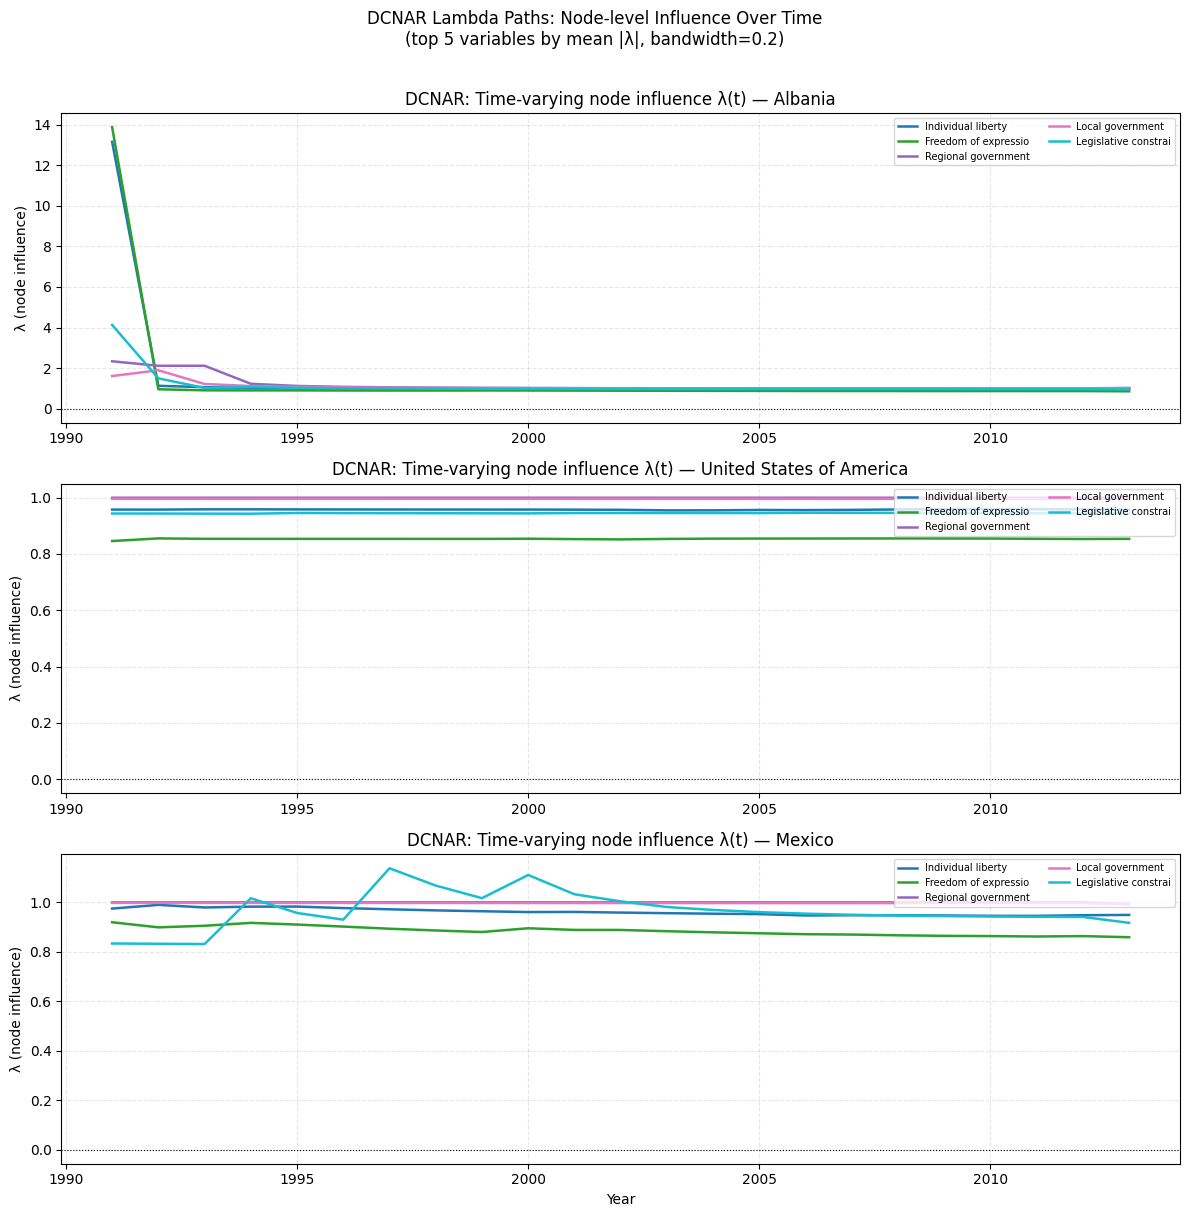

Saved: fig1_lambda_paths_dcnar.png


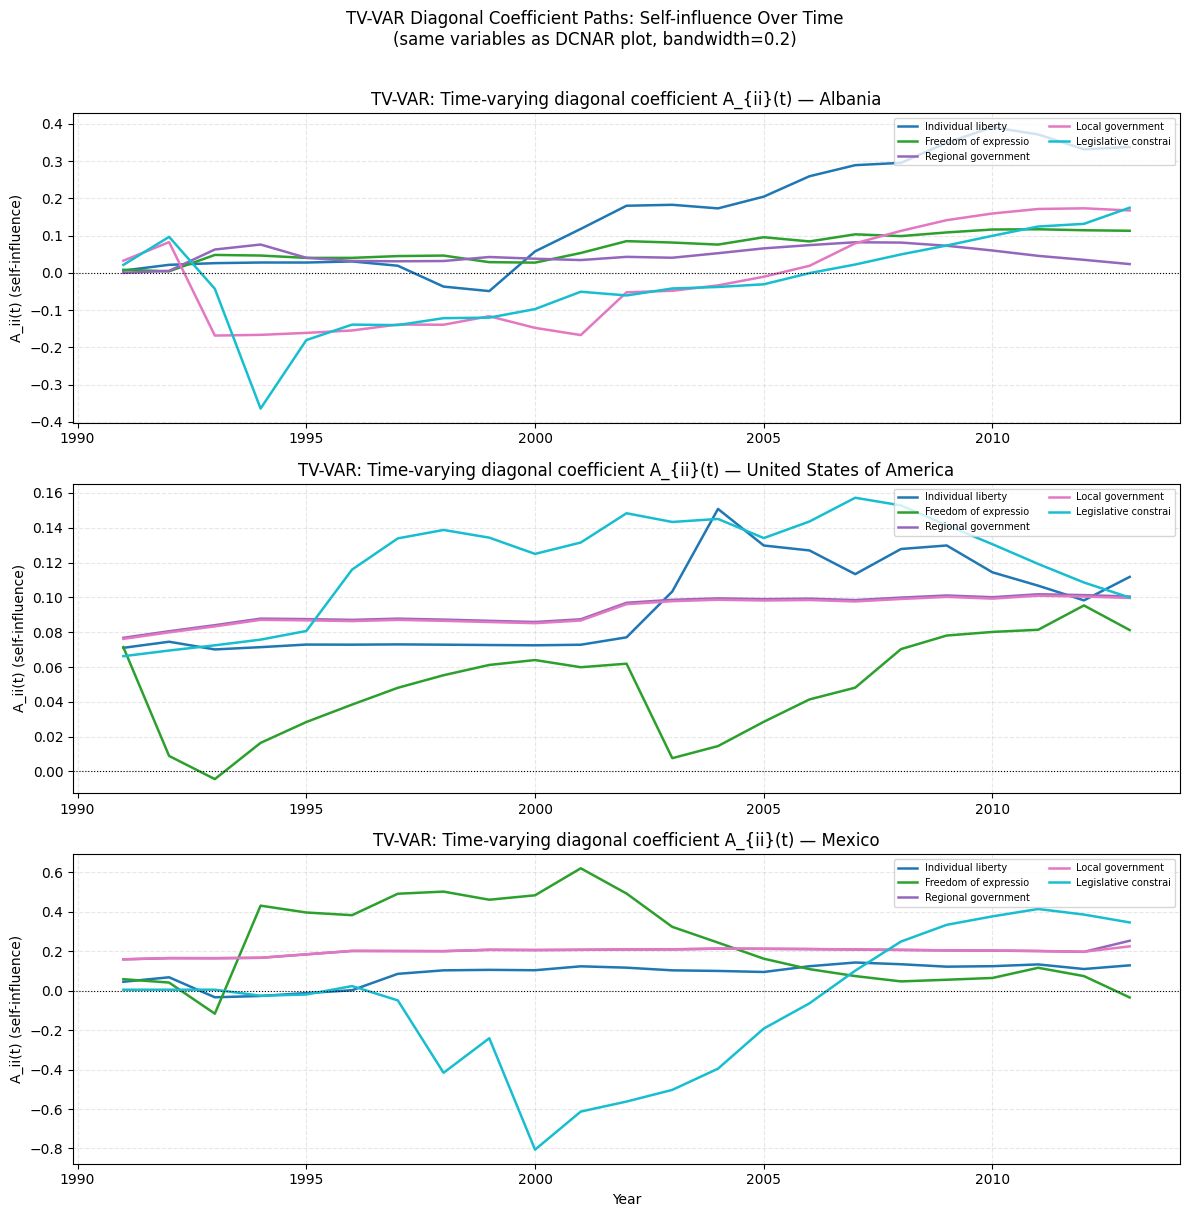

Saved: fig2_tvvar_diag_paths.png


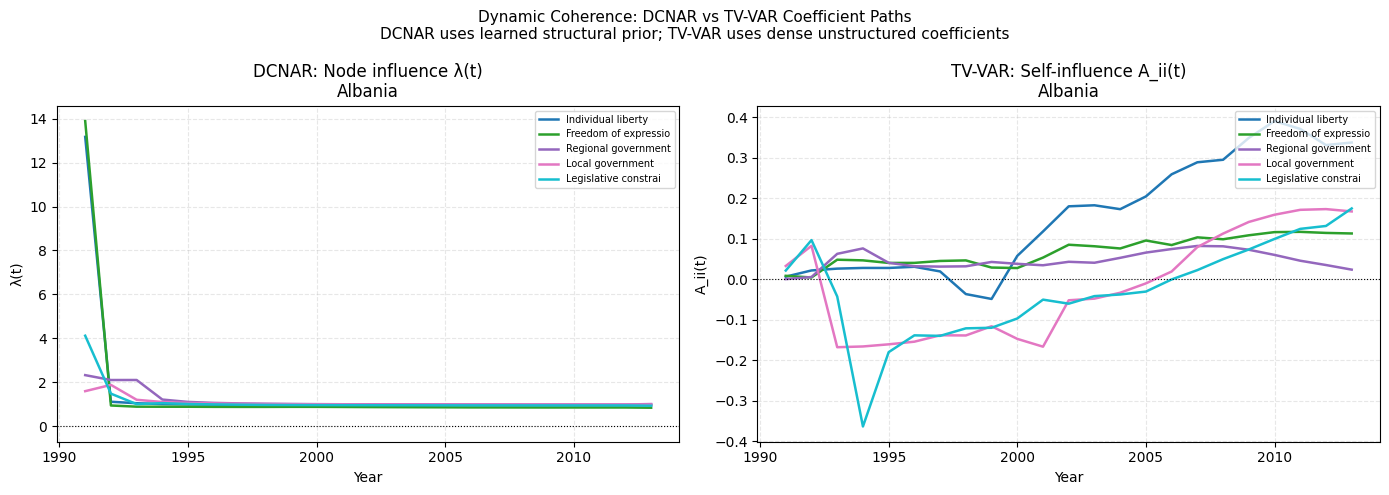

Saved: fig3_dcnar_vs_tvvar_comparison.png


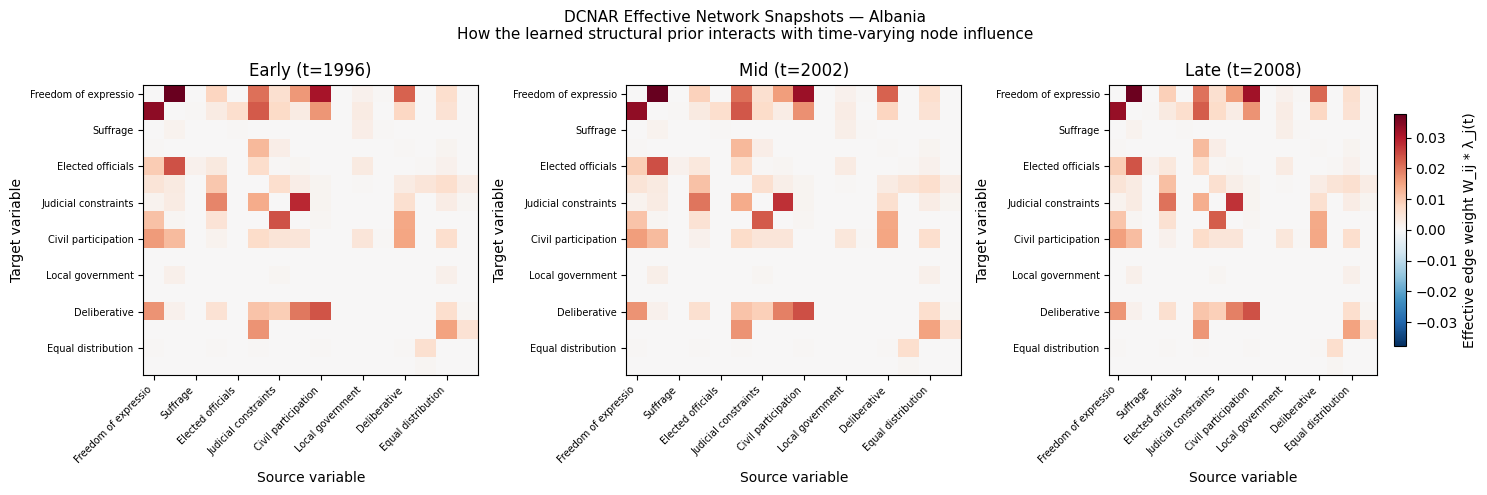

Saved: fig4_effective_network_snapshots.png

=== REBUTTAL SUMMARY: Lambda Path Statistics ===

Albania:
  DCNAR lambda range: [0.0000, 13.8843]
  DCNAR mean |lambda|: 1.0691
  DCNAR lambda std over time: 0.5144
  TV-VAR diag range: [-0.8431, 0.7306]
  TV-VAR diag std over time: 0.1222

United States of America:
  DCNAR lambda range: [0.0000, 1.0264]
  DCNAR mean |lambda|: 0.8934
  DCNAR lambda std over time: 0.0022
  TV-VAR diag range: [-0.0255, 0.6880]
  TV-VAR diag std over time: 0.0405

Mexico:
  DCNAR lambda range: [0.0000, 1.1680]
  DCNAR mean |lambda|: 0.9054
  DCNAR lambda std over time: 0.0173
  TV-VAR diag range: [-0.8060, 1.1904]
  TV-VAR diag std over time: 0.1188

All outputs saved to: paper_run_unionW/lambda_trajectories

Figures for rebuttal repository:
  fig1_lambda_paths_dcnar.png   — DCNAR lambda(t) per variable
  fig2_tvvar_diag_paths.png     — TV-VAR A_ii(t) per variable
  fig3_dcnar_vs_tvvar_comparison.png — Side-by-side for Albania
  fig4_effective_network_snapshot

In [ ]:
# ============================================================
# LAMBDA TRAJECTORY VISUALIZATION
# Compares time-varying coefficient paths for DCNAR vs TV-VAR
# showing the source of dynamic coherence in each model.
#
# Insert as a new cell AFTER Cell 17 (after tvnar_lambda_hat
# and tvnar_one_step_mean are defined).
#
# Requires:
#   - Y_train, var_cols, cfg
#   - W_VARIANTS, ACTIVE_W_NAME
#   - tvnar_lambda_hat() from Cell 17
#   - kernel_weights() from Cell 16
#   - fit_var1_ridge() from Cell 15
#
# Produces (saved to TRAJ_OUT and optionally Google Drive):
#   - lambda_paths_dcnar.csv       — DCNAR lambda(t) for each variable
#   - tvvar_coeff_paths.csv        — TV-VAR diagonal A(t) for each variable
#   - fig1_lambda_paths.png        — DCNAR lambda paths for selected variables
#   - fig2_tvvar_diag_paths.png    — TV-VAR diagonal coefficient paths
#   - fig3_dcnar_vs_tvvar.png      — Side-by-side comparison (selected vars)
#   - fig4_effective_network.png   — DCNAR effective edge weights W*lambda(t)
#                                    at early, mid, and late time points
# ============================================================

# -------------------------------------------------------
# 0. Google Drive mount (uncomment in Colab)
# -------------------------------------------------------
# from google.colab import drive
# drive.mount('/content/drive')
# GDRIVE_OUT = "/content/drive/MyDrive/KDD_463_trajectories"
# os.makedirs(GDRIVE_OUT, exist_ok=True)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# -------------------------------------------------------
# 1. Configuration
# -------------------------------------------------------
TRAJ_OUT = os.path.join(cfg.out_dir, "lambda_trajectories")
os.makedirs(TRAJ_OUT, exist_ok=True)

# Countries to analyze
COUNTRIES_TRAJ = ["Albania", "United States of America", "Mexico"]

# Variables to highlight in plots (top N by mean lambda magnitude)
N_VARS_PLOT = 5

# Time points for effective network snapshots
SNAPSHOT_FRACTIONS = [0.25, 0.50, 0.75]  # early, mid, late

# Model parameters
bandwidth = float(getattr(cfg, "bandwidth", 0.2))
ridge = float(getattr(cfg, "tvnar_ridge", 1e-4)) if hasattr(cfg, "tvnar_ridge") else 1e-4
kernel = "gaussian"

W_active = np.asarray(W_VARIANTS[ACTIVE_W_NAME], float)
V = len(var_cols)

# Clean variable names for plotting
def short_name(v):
    return v.replace("_", " ").replace("v2", "").strip()[:20]

var_labels = [short_name(v) for v in var_cols]

# -------------------------------------------------------
# 2. Helper: get country series
# -------------------------------------------------------
def get_series(country_name):
    sub = train_df_sorted[
        train_df_sorted[cfg.country_col] == country_name
    ].sort_values(cfg.time_col)
    if len(sub) == 0:
        raise KeyError(f"Country '{country_name}' not found.")
    years = sub[cfg.time_col].values
    data = sub[var_cols].to_numpy(float)
    return data, years

# -------------------------------------------------------
# 3. DCNAR: compute lambda(t) across full time grid
# -------------------------------------------------------
def compute_dcnar_lambda_paths(series, W, bandwidth, ridge, kernel):
    """
    Compute lambda(t) for t = 2..T-1 using one-sided kernel.
    Returns lam_paths [T-2, V] and time indices [T-2].
    """
    T, N = series.shape
    lam_paths = []
    t_indices = []

    for t in range(2, T):
        tau = t / T
        taus = np.arange(1, t) / T
        u = (taus - tau) / bandwidth

        if kernel == "gaussian":
            w = np.exp(-0.5 * u * u)
        elif kernel == "epanechnikov":
            w = 0.75 * (1.0 - u * u) * (np.abs(u) <= 1.0)
        else:
            raise ValueError("Unknown kernel")

        w_sum = float(w.sum())
        if w_sum <= 0:
            continue
        w = w / (w_sum + 1e-12)

        W_hat = W + np.eye(N)
        X_blocks, y_blocks = [], []
        for s, ws in zip(range(1, t), w):
            y_prev = series[s - 1]
            X_s = W_hat * y_prev[None, :]
            X_blocks.append(np.sqrt(ws) * X_s)
            y_blocks.append(np.sqrt(ws) * series[s])

        if len(X_blocks) == 0:
            continue

        X = np.vstack(X_blocks)
        y_vec = np.concatenate(y_blocks)
        XtX = X.T @ X + ridge * np.eye(N)
        lam = np.linalg.solve(XtX, X.T @ y_vec)
        lam_paths.append(lam)
        t_indices.append(t)

    return np.array(lam_paths), np.array(t_indices)

# -------------------------------------------------------
# 4. TV-VAR: compute diagonal of A(t) across full time grid
# -------------------------------------------------------
def compute_tvvar_diag_paths(series, bandwidth, ridge, kernel):
    """
    Compute diagonal of A(t) for t = 2..T-1 using one-sided kernel.
    Diagonal captures self-influence (persistence) per variable.
    Returns diag_paths [T-2, V] and t_indices [T-2].
    """
    T, N = series.shape
    diag_paths = []
    t_indices = []

    for t in range(2, T):
        tau = t / T
        taus = np.arange(1, t) / T
        u = (taus - tau) / bandwidth

        if kernel == "gaussian":
            w = np.exp(-0.5 * u * u)
        elif kernel == "epanechnikov":
            w = 0.75 * (1.0 - u * u) * (np.abs(u) <= 1.0)
        else:
            raise ValueError("Unknown kernel")

        w_sum = float(w.sum())
        if w_sum <= 0:
            continue
        w = w / (w_sum + 1e-12)
        sw = np.sqrt(w)[:, None]

        Y0 = series[:-1]  # [T-1, N]
        Y1 = series[1:]   # [T-1, N]

        # Use observations up to t only
        Y0_local = Y0[:t-1]
        Y1_local = Y1[:t-1]

        Xw = Y0_local * sw[:t-1]
        Yw = Y1_local * sw[:t-1]

        XtX = Xw.T @ Xw + ridge * np.eye(N)
        A_T = np.linalg.solve(XtX, Xw.T @ Yw)
        A = A_T.T
        diag_paths.append(np.diag(A))
        t_indices.append(t)

    return np.array(diag_paths), np.array(t_indices)

# -------------------------------------------------------
# 5. Run for each country
# -------------------------------------------------------
all_dcnar = {}
all_tvvar = {}
all_years = {}

for country in COUNTRIES_TRAJ:
    try:
        series, years = get_series(country)
        print(f"Computing lambda paths for {country} (T={len(series)})...")

        lam_paths, t_idx = compute_dcnar_lambda_paths(
            series, W_active, bandwidth, ridge, kernel
        )
        diag_paths, t_idx2 = compute_tvvar_diag_paths(
            series, bandwidth, ridge, kernel
        )

        all_dcnar[country] = (lam_paths, t_idx, years)
        all_tvvar[country] = (diag_paths, t_idx2, years)
        print(f"  DCNAR: {lam_paths.shape}, TV-VAR diag: {diag_paths.shape}")

    except KeyError as e:
        print(f"Skipping {country}: {e}")

# -------------------------------------------------------
# 6. Save CSVs
# -------------------------------------------------------
for country in all_dcnar:
    lam_paths, t_idx, years = all_dcnar[country]
    df_lam = pd.DataFrame(lam_paths, columns=var_cols)
    df_lam.insert(0, "t_index", t_idx)
    df_lam.insert(1, "year_approx", years[t_idx - 1] if len(years) > max(t_idx - 1) else t_idx)
    fname = f"lambda_paths_dcnar_{country.replace(' ', '_')}.csv"
    df_lam.to_csv(os.path.join(TRAJ_OUT, fname), index=False)

    diag_paths, t_idx2, years2 = all_tvvar[country]
    df_diag = pd.DataFrame(diag_paths, columns=var_cols)
    df_diag.insert(0, "t_index", t_idx2)
    fname2 = f"tvvar_diag_paths_{country.replace(' ', '_')}.csv"
    df_diag.to_csv(os.path.join(TRAJ_OUT, fname2), index=False)

print("CSVs saved.")

# -------------------------------------------------------
# 7. Figure 1: DCNAR lambda paths — selected variables
# -------------------------------------------------------
# Select top N_VARS_PLOT variables by mean absolute lambda
# across all countries
mean_abs_lam = np.zeros(V)
for country in all_dcnar:
    lam_paths, _, _ = all_dcnar[country]
    mean_abs_lam += np.mean(np.abs(lam_paths), axis=0)
top_vars_idx = np.argsort(mean_abs_lam)[::-1][:N_VARS_PLOT]
top_var_names = [var_labels[i] for i in top_vars_idx]

n_countries = len(all_dcnar)
fig, axes = plt.subplots(n_countries, 1, figsize=(12, 4 * n_countries), sharex=False)
if n_countries == 1:
    axes = [axes]

cmap_vars = plt.cm.tab10(np.linspace(0, 0.9, N_VARS_PLOT))

for ax, country in zip(axes, list(all_dcnar.keys())):
    lam_paths, t_idx, years = all_dcnar[country]
    # Use year labels if available
    x_vals = years[t_idx - 1] if len(years) >= max(t_idx) else t_idx

    for rank, var_i in enumerate(top_vars_idx):
        ax.plot(x_vals, lam_paths[:, var_i],
                color=cmap_vars[rank], lw=1.8,
                label=top_var_names[rank])

    ax.axhline(0, color="black", lw=0.8, ls=":")
    ax.set_title(f"DCNAR: Time-varying node influence λ(t) — {country}")
    ax.set_ylabel("λ (node influence)")
    ax.legend(fontsize=7, loc="upper right", ncol=2)
    ax.grid(True, linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Year")
plt.suptitle("DCNAR Lambda Paths: Node-level Influence Over Time\n"
             f"(top {N_VARS_PLOT} variables by mean |λ|, bandwidth={bandwidth})",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(TRAJ_OUT, "fig1_lambda_paths_dcnar.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_lambda_paths_dcnar.png")

# -------------------------------------------------------
# 8. Figure 2: TV-VAR diagonal paths — same variables
# -------------------------------------------------------
fig, axes = plt.subplots(n_countries, 1, figsize=(12, 4 * n_countries), sharex=False)
if n_countries == 1:
    axes = [axes]

for ax, country in zip(axes, list(all_tvvar.keys())):
    diag_paths, t_idx2, years = all_tvvar[country]
    x_vals = years[t_idx2 - 1] if len(years) >= max(t_idx2) else t_idx2

    for rank, var_i in enumerate(top_vars_idx):
        ax.plot(x_vals, diag_paths[:, var_i],
                color=cmap_vars[rank], lw=1.8,
                label=top_var_names[rank])

    ax.axhline(0, color="black", lw=0.8, ls=":")
    ax.set_title(f"TV-VAR: Time-varying diagonal coefficient A_{{ii}}(t) — {country}")
    ax.set_ylabel("A_ii(t) (self-influence)")
    ax.legend(fontsize=7, loc="upper right", ncol=2)
    ax.grid(True, linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Year")
plt.suptitle("TV-VAR Diagonal Coefficient Paths: Self-influence Over Time\n"
             f"(same variables as DCNAR plot, bandwidth={bandwidth})",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(TRAJ_OUT, "fig2_tvvar_diag_paths.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_tvvar_diag_paths.png")

# -------------------------------------------------------
# 9. Figure 3: Side-by-side comparison for one country
# -------------------------------------------------------
COMPARE_COUNTRY = COUNTRIES_TRAJ[0]  # Albania as default

if COMPARE_COUNTRY in all_dcnar and COMPARE_COUNTRY in all_tvvar:
    lam_paths, t_idx, years = all_dcnar[COMPARE_COUNTRY]
    diag_paths, t_idx2, years2 = all_tvvar[COMPARE_COUNTRY]

    x_dcnar = years[t_idx - 1] if len(years) >= max(t_idx) else t_idx
    x_tvvar = years2[t_idx2 - 1] if len(years2) >= max(t_idx2) else t_idx2

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for rank, var_i in enumerate(top_vars_idx):
        axes[0].plot(x_dcnar, lam_paths[:, var_i],
                     color=cmap_vars[rank], lw=1.8,
                     label=top_var_names[rank])
        axes[1].plot(x_tvvar, diag_paths[:, var_i],
                     color=cmap_vars[rank], lw=1.8,
                     label=top_var_names[rank])

    for ax, title in zip(axes, [
        f"DCNAR: Node influence λ(t)\n{COMPARE_COUNTRY}",
        f"TV-VAR: Self-influence A_ii(t)\n{COMPARE_COUNTRY}"
    ]):
        ax.axhline(0, color="black", lw=0.8, ls=":")
        ax.set_title(title)
        ax.set_xlabel("Year")
        ax.legend(fontsize=7, loc="upper right", ncol=1)
        ax.grid(True, linestyle="--", alpha=0.3)

    axes[0].set_ylabel("λ(t)")
    axes[1].set_ylabel("A_ii(t)")

    plt.suptitle("Dynamic Coherence: DCNAR vs TV-VAR Coefficient Paths\n"
                 "DCNAR uses learned structural prior; TV-VAR uses dense unstructured coefficients",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(TRAJ_OUT, "fig3_dcnar_vs_tvvar_comparison.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig3_dcnar_vs_tvvar_comparison.png")

# -------------------------------------------------------
# 10. Figure 4: Effective network snapshots W * lambda(t)
# -------------------------------------------------------
# Show how the effective edge weights (W_ij * lambda_j(t))
# change at early, mid, late time points for one country.

if COMPARE_COUNTRY in all_dcnar:
    lam_paths, t_idx, years = all_dcnar[COMPARE_COUNTRY]
    T_traj = len(t_idx)

    snap_indices = [
        int(T_traj * f) for f in SNAPSHOT_FRACTIONS
    ]
    snap_indices = [max(0, min(i, T_traj - 1)) for i in snap_indices]
    snap_labels = ["Early", "Mid", "Late"]

    W_hat = W_active + np.eye(V)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    vmax_global = 0
    eff_networks = []
    for si in snap_indices:
        lam_t = lam_paths[si]
        eff = W_active * lam_t[None, :]
        eff_networks.append(eff)
        vmax_global = max(vmax_global, np.abs(eff).max())

    norm = Normalize(vmin=-vmax_global, vmax=vmax_global)
    cmap_net = cm.RdBu_r

    for ax, eff, label, si in zip(axes, eff_networks, snap_labels, snap_indices):
        im = ax.imshow(eff, cmap=cmap_net, norm=norm, aspect="auto")
        year_label = years[t_idx[si] - 1] if len(years) >= t_idx[si] else t_idx[si]
        ax.set_title(f"{label} (t={year_label})")
        ax.set_xlabel("Source variable")
        ax.set_ylabel("Target variable")

        # Tick labels — use short names, sparse
        tick_step = max(1, V // 8)
        ticks = list(range(0, V, tick_step))
        ax.set_xticks(ticks)
        ax.set_xticklabels([var_labels[i] for i in ticks],
                           rotation=45, ha="right", fontsize=7)
        ax.set_yticks(ticks)
        ax.set_yticklabels([var_labels[i] for i in ticks], fontsize=7)

    plt.colorbar(im, ax=axes[-1], shrink=0.8, label="Effective edge weight W_ij * λ_j(t)")
    plt.suptitle(f"DCNAR Effective Network Snapshots — {COMPARE_COUNTRY}\n"
                 "How the learned structural prior interacts with time-varying node influence",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(TRAJ_OUT, "fig4_effective_network_snapshots.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig4_effective_network_snapshots.png")

# -------------------------------------------------------
# 11. Summary statistics for rebuttal
# -------------------------------------------------------
print("\n=== REBUTTAL SUMMARY: Lambda Path Statistics ===")
for country in all_dcnar:
    lam_paths, t_idx, years = all_dcnar[country]
    print(f"\n{country}:")
    print(f"  DCNAR lambda range: [{lam_paths.min():.4f}, {lam_paths.max():.4f}]")
    print(f"  DCNAR mean |lambda|: {np.mean(np.abs(lam_paths)):.4f}")
    print(f"  DCNAR lambda std over time: {np.mean(np.std(lam_paths, axis=0)):.4f}")

    if country in all_tvvar:
        diag_paths, _, _ = all_tvvar[country]
        print(f"  TV-VAR diag range: [{diag_paths.min():.4f}, {diag_paths.max():.4f}]")
        print(f"  TV-VAR diag std over time: {np.mean(np.std(diag_paths, axis=0)):.4f}")

print(f"\nAll outputs saved to: {TRAJ_OUT}")
print("\nFigures for rebuttal repository:")
print("  fig1_lambda_paths_dcnar.png   — DCNAR lambda(t) per variable")
print("  fig2_tvvar_diag_paths.png     — TV-VAR A_ii(t) per variable")
print("  fig3_dcnar_vs_tvvar_comparison.png — Side-by-side for Albania")
print("  fig4_effective_network_snapshots.png — Effective network at 3 time points")

# -------------------------------------------------------
# 12. Optional: copy to Google Drive
# -------------------------------------------------------
import shutil
shutil.copytree(TRAJ_OUT, os.path.join(GDRIVE_OUT, "lambda_trajectories"),
                dirs_exist_ok=True)
print(f"Copied to Google Drive: {GDRIVE_OUT}")

In [ ]:
import shutil
shutil.copytree(TRAJ_OUT, os.path.join(GDRIVE_OUT, "lambda_trajectories"),
                dirs_exist_ok=True)
print(f"Copied to Google Drive: {GDRIVE_OUT}")

Copied to Google Drive: /content/drive/MyDrive/DCNAR/KDD_463_sensitivity


In [ ]:
# -------------------------------------------------------
# 10. Optional: copy to Google Drive
# -------------------------------------------------------
import shutil
shutil.copytree(SENS_OUT, os.path.join(GDRIVE_OUT, "bandwidth_sensitivity"),
                dirs_exist_ok=True)
print(f"Copied to Google Drive: {GDRIVE_OUT}")

Copied to Google Drive: /content/drive/MyDrive/DCNAR/KDD_463_sensitivity


In [ ]:
# ----------------------------
# Step 8 LSTM with MC Dropout (PyTorch)
# REQUIRES torch
# ----------------------------
USE_TORCH = True
try:
    import torch
    import torch.nn as nn
except Exception:
    USE_TORCH = False

class SimpleLSTM(nn.Module):
    def __init__(self, input_dim: int, hidden: int = 64, layers: int = 1, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, num_layers=layers, batch_first=True, dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, input_dim)

    def forward(self, x):
        # x: [B, L, V]
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        h = self.drop(h)
        return self.head(h)

def build_seq_dataset(Y: np.ndarray, L: int):
    X, y = [], []
    for t in range(L, Y.shape[0]):
        X.append(Y[t-L:t])
        y.append(Y[t])
    return np.asarray(X, float), np.asarray(y, float)

def train_lstm_mc_dropout(Y_fit: np.ndarray, L: int = 8, hidden: int = 64, layers: int = 1, dropout: float = 0.2,
                          epochs: int = 30, batch: int = 256, lr: float = 1e-3, device: str = "cpu"):
    X, y = build_seq_dataset(Y_fit, L)
    if X.shape[0] < 10:
        raise ValueError("Not enough data to train LSTM with the chosen seq_len.")
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    y_t = torch.tensor(y, dtype=torch.float32, device=device)

    model = SimpleLSTM(input_dim=V, hidden=hidden, layers=layers, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    n = X_t.shape[0]
    for ep in range(epochs):
        perm = torch.randperm(n, device=device)
        for i0 in range(0, n, batch):
            idx = perm[i0:i0+batch]
            xb = X_t[idx]
            yb = y_t[idx]
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
    return model

def lstm_mc_sampler(model, Y_hist: np.ndarray, L: int, B: int, device: str = "cpu"):
    """
    One-step MC dropout draws given history Y_hist (full history up to t-1).
    Returns [B,V].
    """
    if Y_hist.shape[0] < L:
        pad = np.repeat(Y_hist[:1], L - Y_hist.shape[0], axis=0)
        seq = np.vstack([pad, Y_hist])
    else:
        seq = Y_hist[-L:]
    x = torch.tensor(seq[None, :, :], dtype=torch.float32, device=device)  # [1,L,V]

    model.train()  # enable dropout at inference
    outs = []
    with torch.no_grad():
        for _ in range(B):
            yhat = model(x).detach().cpu().numpy()[0]
            outs.append(yhat)
    return np.stack(outs, axis=0)  # [B,V]

In [ ]:
# ----------------------------
# Step 9 Fit models on Y_fit (same training used for NAVAR), then evaluate CRPS on the last H points
# ----------------------------
Y_fit = Y_train[:fit_end]

# VAR fit
var_ridge = 1e-4
A_var, resid_var = fit_var1_ridge(Y_fit, ridge=var_ridge)

# TV-VAR params (can be in cfg)
tvvar_bandwidth = float(getattr(cfg, "bandwidth", 0.2))
tvvar_ridge = float(getattr(cfg, "tvnar_ridge", 1e-4)) if hasattr(cfg, "tvnar_ridge") else 1e-4
tvvar_kernel = "gaussian"

# tvNAR params (can be in cfg)
W_active = np.asarray(W_VARIANTS[ACTIVE_W_NAME], float)
tvnar_bandwidth = float(getattr(cfg, "bandwidth", 0.2))
tvnar_ridge = float(getattr(cfg, "tvnar_ridge", 1e-4)) if hasattr(cfg, "tvnar_ridge") else 1e-4
tvnar_kernel = "gaussian"

# LSTM fit (optional but requested)
lstm_ready = False
if USE_TORCH:
    device = "cuda" if (hasattr(torch, "cuda") and torch.cuda.is_available()) else "cpu"
    L = int(getattr(cfg, "lstm_seq_len", 8))
    hidden = int(getattr(cfg, "lstm_hidden", 64))
    layers = int(getattr(cfg, "lstm_layers", 1))
    dropout = float(getattr(cfg, "lstm_dropout", 0.2))
    epochs = int(getattr(cfg, "lstm_epochs", 30))
    batch = int(getattr(cfg, "lstm_batch", 256))
    lr = float(getattr(cfg, "lstm_lr", 1e-3))
    lstm_model = train_lstm_mc_dropout(
        Y_fit=Y_fit, L=L, hidden=hidden, layers=layers, dropout=dropout,
        epochs=epochs, batch=batch, lr=lr, device=device
    )
    lstm_ready = True
else:
    print("WARNING: torch not available; LSTM baseline will be skipped.")

# Evaluate: collect samples [B,H,V] per model
Y_true = Y_train[eval_indices]  # [H,V]

def collect_samples_VAR():
    samps = np.zeros((B, H, V), float)
    for h_idx, t in enumerate(eval_indices):
        y_prev = Y_train[t - 1]
        samps[:, h_idx, :] = var1_bootstrap_sampler(A_var, resid_var, y_prev, B)
    return samps

def collect_samples_TVVAR():
    samps = np.zeros((B, H, V), float)
    for h_idx, t in enumerate(eval_indices):
        samps[:, h_idx, :] = tvvar1_sampler(
            Y_fit=Y_fit, t_star_global=int(t),
            bandwidth=tvvar_bandwidth, ridge=tvvar_ridge, kernel=tvvar_kernel, B=B
        )
    return samps

def collect_samples_tvNAR():
    samps = np.zeros((B, H, V), float)
    for h_idx, t in enumerate(eval_indices):
        samps[:, h_idx, :] = tvnar_sampler(
            Y_fit=Y_fit, W=W_active, t_star_global=int(t),
            bandwidth=tvnar_bandwidth, ridge=tvnar_ridge, kernel=tvnar_kernel, B=B
        )
    return samps

def collect_samples_LSTM():
    samps = np.zeros((B, H, V), float)
    for h_idx, t in enumerate(eval_indices):
        Y_hist = Y_train[:t]  # history up to t-1
        samps[:, h_idx, :] = lstm_mc_sampler(lstm_model, Y_hist, L=L, B=B, device=device)
    return samps

samples = {}
samples["VAR"] = collect_samples_VAR()
samples["TV-VAR"] = collect_samples_TVVAR()
samples["tvNAR"] = collect_samples_tvNAR()
if lstm_ready:
    samples["LSTM"] = collect_samples_LSTM()

# Compute CRPS per model
crps_scores = {name: crps_mean(Y_true, samps) for name, samps in samples.items()}

print("\nEmpirical predictive distribution accuracy (mean CRPS; lower is better)")
print(f"Evaluation window: last H={H} points of NAVAR-training data (fit on first {fit_end} points).")
print(f"Samples per forecast: B={B}")
print(f"ACTIVE_W_NAME for tvNAR: {ACTIVE_W_NAME}")
for name, score in sorted(crps_scores.items(), key=lambda kv: kv[1]):
    print(f"  {name:6s}  CRPS = {score:.6f}")

# Results object you can reuse for stability/coverage/dashboard later:
EVAL_RESULTS = {
    "Y_true": Y_true,         # [H,V]
    "samples": samples,       # dict[name -> [B,H,V]]
    "crps": crps_scores,      # dict[name -> float]
    "eval_indices": eval_indices,
    "fit_end": fit_end,
    "ACTIVE_W_NAME": ACTIVE_W_NAME,
}



Empirical predictive distribution accuracy (mean CRPS; lower is better)
Evaluation window: last H=10 points of NAVAR-training data (fit on first 3465 points).
Samples per forecast: B=500
ACTIVE_W_NAME for tvNAR: navar_ablated_weighted
  tvNAR   CRPS = 0.014254
  VAR     CRPS = 0.016984
  TV-VAR  CRPS = 0.017474
  LSTM    CRPS = 0.055926


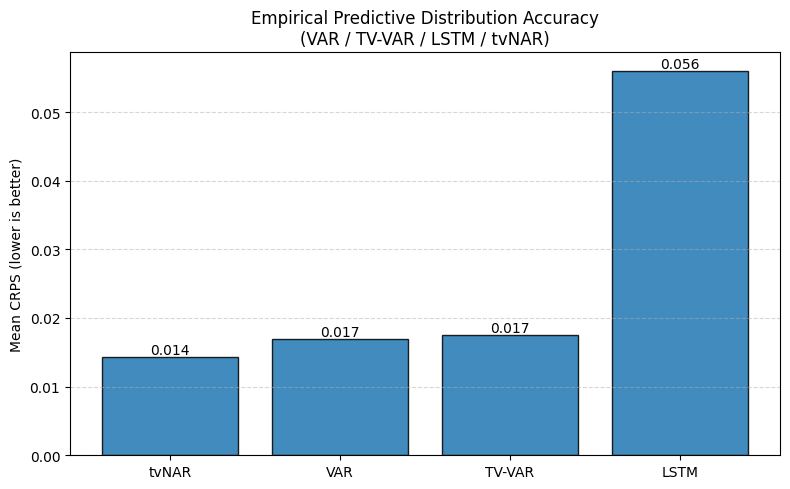


Model ranking by CRPS (lower is better):
 1. tvNAR   CRPS = 0.014254
 2. VAR     CRPS = 0.016984
 3. TV-VAR  CRPS = 0.017474
 4. LSTM    CRPS = 0.055926


In [ ]:
# ----------------------------
# Step 9a  One-cell plotting code for empirical predictive distribution accuracy
# ----------------------------

# Uses EVAL_RESULTS produced in the previous cell.
# Produces a clean comparison chart across models.

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Extract results
# ----------------------------
crps_scores = EVAL_RESULTS["crps"]          # dict: model -> CRPS
models = list(crps_scores.keys())
scores = np.array([crps_scores[m] for m in models])

# Sort models by performance (lower CRPS = better)
order = np.argsort(scores)
models_sorted = [models[i] for i in order]
scores_sorted = scores[order]

# ----------------------------
# Plot: CRPS comparison
# ----------------------------
plt.figure(figsize=(8, 5))

bars = plt.bar(
    models_sorted,
    scores_sorted,
    edgecolor="black",
    alpha=0.85
)

plt.ylabel("Mean CRPS (lower is better)")
plt.title("Empirical Predictive Distribution Accuracy\n(VAR / TV-VAR / LSTM / tvNAR)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Annotate bars with values
for b, s in zip(bars, scores_sorted):
    plt.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"{s:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# ----------------------------
# Optional: print ranking table
# ----------------------------
print("\nModel ranking by CRPS (lower is better):")
for i, (m, s) in enumerate(zip(models_sorted, scores_sorted), 1):
    print(f"{i:>2d}. {m:6s}  CRPS = {s:.6f}")


Using country=Albania | series_train shape=(25, 16)
Shock: +1σ=0.1479 to Freedom_of_expression (idx=0) | plotting response Freedom_of_expression
tvNAR uses ACTIVE_W=navar_ablated_weighted | lam_vecs shape=(1, 16)
IRF params: {'ridge_var': 0.0001, 'ridge_tv': 0.0001, 'bandwidth': 0.2}


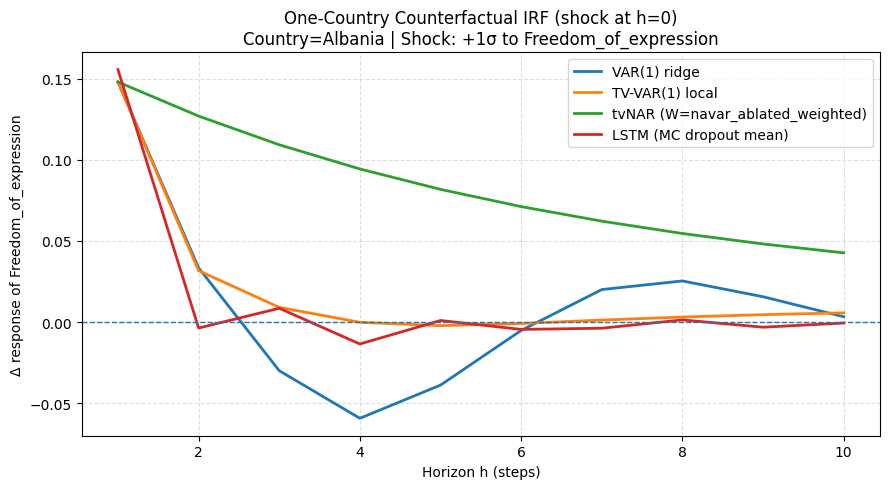

Saved IRF_ONE_COUNTRY (includes tvNAR contribution matrices).


In [ ]:
# ----------------------------
# Step 10 One-country counterfactual IRFs
# ----------------------------
# - run base vs shocked forecast paths
# - apply a one-time shock at forecast step h==0 to variable shock_var
# - propagate for horizon H
# Models: VAR/TV-VAR, LSTM (MC dropout), tvNAR (your decompose + lam_vecs)
#
# Assumes you already have:
#   - train_df_sorted (NAVAR training panel, sorted by cfg.country_col,cfg.time_col)
#   - var_cols
#   - cfg.country_col, cfg.time_col
#   - W_VARIANTS, ACTIVE_W_NAME (for tvNAR)
#   - lam_vecs for tvNAR (shape [p,N])  OR tv object from earlier fit (we'll try to infer)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) Choose ONE country series_train from the NAVAR training panel
# ----------------------------
country_col = getattr(cfg, "country_col", "country_id")
time_col = getattr(cfg, "time_col", "year")
H = 10

# pick a country (change either line)
COUNTRY_ID = train_df_sorted[country_col].iloc[0]  # or set explicitly like "USA" / 840 / etc.
# COUNTRY_ID = "USA"

one = train_df_sorted[train_df_sorted[country_col] == COUNTRY_ID].sort_values(time_col)
series_train = one[var_cols].to_numpy(float)  # [L,N]
L, N = series_train.shape
if L <= H + 2:
    raise ValueError(f"Country {COUNTRY_ID} has too few points (L={L}) for horizon H={H}")

print(f"Using country={COUNTRY_ID} | series_train shape={series_train.shape}")

# shock configuration (by name is safest)
SHOCK_VAR_NAME = var_cols[0]  # change e.g. "v2x_frassoc_thick"
shock_var = var_cols.index(SHOCK_VAR_NAME)
shock_size = float(np.std(series_train[:, shock_var]) + 1e-12)  # 1 std
RESPONSE_VAR_NAME = SHOCK_VAR_NAME
response_var = var_cols.index(RESPONSE_VAR_NAME)

print(f"Shock: +1σ={shock_size:.4g} to {SHOCK_VAR_NAME} (idx={shock_var}) | plotting response {RESPONSE_VAR_NAME}")

# ----------------------------
# 1) tvNAR utilities (your exact logic)
# ----------------------------
def tvnar_one_step_decompose(W, lam_vec, y_prev):
    W = np.asarray(W, float)
    lam_vec = np.asarray(lam_vec, float)
    y_prev = np.asarray(y_prev, float)
    N = y_prev.size
    WpI = W + np.eye(N)
    contrib = WpI * (lam_vec[None, :] * y_prev[None, :])
    yhat = contrib.sum(axis=1)
    return yhat, contrib

def counterfactual_shock_tvnar(series_train, W, lam_vecs, shock_var, shock_size=0.1, horizon=10):
    series_train = np.asarray(series_train, float)
    W = np.asarray(W, float)
    lam_vecs = np.asarray(lam_vecs, float)
    p, N = lam_vecs.shape

    idx = shock_var if isinstance(shock_var, int) else var_cols.index(shock_var)

    buf_base = series_train[-p:].copy()
    buf_shock = series_train[-p:].copy()

    y_base = np.zeros((horizon, N), float)
    y_shock = np.zeros((horizon, N), float)
    contrib_mats = []

    for h in range(horizon):
        # base
        yhat_b = np.zeros(N)
        for ell in range(1, p+1):
            y_step, _ = tvnar_one_step_decompose(W, lam_vecs[ell-1], buf_base[-ell])
            yhat_b += y_step
        y_base[h] = yhat_b
        buf_base = np.vstack([buf_base[1:], yhat_b[None, :]])

        # shock
        yhat_s = np.zeros(N)
        contrib_total = np.zeros((N, N), float)
        for ell in range(1, p+1):
            y_step, contrib = tvnar_one_step_decompose(W, lam_vecs[ell-1], buf_shock[-ell])
            yhat_s += y_step
            contrib_total += contrib
        if h == 0:
            yhat_s[idx] += shock_size
        y_shock[h] = yhat_s
        contrib_mats.append(contrib_total.copy())
        buf_shock = np.vstack([buf_shock[1:], yhat_s[None, :]])

    return y_base, y_shock, contrib_mats

# ----------------------------
# 2) VAR(p) ridge counterfactual (same semantics as your enet code)
# ----------------------------
def fit_var_ridge(Y, p=1, ridge=1e-4):
    """
    Fit VAR(p): y_t = B x_t + e_t, where x_t = [y_{t-1},...,y_{t-p}] stacked.
    Returns B: [N, N*p]
    """
    Y = np.asarray(Y, float)
    T, N = Y.shape
    if T <= p:
        raise ValueError("Not enough data for VAR(p).")
    X = []
    Yt = []
    for t in range(p, T):
        X.append(np.hstack([Y[t-lag-1] for lag in range(p)]))
        Yt.append(Y[t])
    X = np.asarray(X, float)      # [T-p, N*p]
    Yt = np.asarray(Yt, float)    # [T-p, N]
    XtX = X.T @ X + ridge * np.eye(N*p)
    B = np.linalg.solve(XtX, X.T @ Yt).T  # [N, N*p]
    return B

def var_predict_one(B, buf, p):
    x = np.hstack([buf[-lag-1] for lag in range(p)])[None, :]  # [1,N*p]
    return (B @ x.T).ravel()  # [N]

def counterfactual_shock_var(series_train, B, p, shock_var, shock_size=0.1, horizon=10):
    series_train = np.asarray(series_train, float)
    idx = shock_var if isinstance(shock_var, int) else var_cols.index(shock_var)

    buf_base = series_train[-p:].copy()
    buf_shock = series_train[-p:].copy()
    base = np.zeros((horizon, N), float)
    shock = np.zeros((horizon, N), float)

    for h in range(horizon):
        yb = var_predict_one(B, buf_base, p)
        base[h] = yb
        buf_base = np.vstack([buf_base[1:], yb[None, :]])

        ys = var_predict_one(B, buf_shock, p)
        if h == 0:
            ys = ys.copy()
            ys[idx] += shock_size
        shock[h] = ys
        buf_shock = np.vstack([buf_shock[1:], ys[None, :]])

    return base, shock, (shock - base)

# ----------------------------
# 3) TV-VAR(p): local ridge (kernel-weighted) then same counterfactual rollout
# ----------------------------
def kernel_weights(taus, tau_star, bandwidth, kernel="gaussian"):
    u = (taus - tau_star) / bandwidth
    if kernel == "gaussian":
        w = np.exp(-0.5 * u * u)
    elif kernel == "epanechnikov":
        w = 0.75 * (1 - u*u) * (np.abs(u) <= 1)
    else:
        raise ValueError("kernel must be gaussian/epanechnikov")
    s = float(w.sum())
    return w / (s + 1e-12)

def fit_tvvar_ridge_local(Y, p=1, ridge=1e-4, bandwidth=0.2, kernel="gaussian"):
    """
    Local-constant TV-VAR(p) fit at end of series_train (tau ~ 1), using kernel weights.
    Returns B_local: [N, N*p]
    """
    Y = np.asarray(Y, float)
    T, N = Y.shape
    if T <= p + 2:
        raise ValueError("Not enough data for TV-VAR(p).")
    X = []
    Yt = []
    taus = []
    for t in range(p, T):
        X.append(np.hstack([Y[t-lag-1] for lag in range(p)]))
        Yt.append(Y[t])
        taus.append(t / T)
    X = np.asarray(X, float)     # [T-p, N*p]
    Yt = np.asarray(Yt, float)   # [T-p, N]
    taus = np.asarray(taus, float)
    tau_star = (T-1) / T
    w = kernel_weights(taus, tau_star, bandwidth, kernel=kernel)
    sw = np.sqrt(w)[:, None]
    Xw = X * sw
    Yw = Yt * sw

    XtX = Xw.T @ Xw + ridge * np.eye(N*p)
    B_local = np.linalg.solve(XtX, Xw.T @ Yw).T  # [N, N*p]
    return B_local

# ----------------------------
# 4) LSTM (MC dropout) counterfactual rollout (single country)
# ----------------------------
USE_TORCH = True
try:
    import torch
    import torch.nn as nn
except Exception:
    USE_TORCH = False

class SimpleLSTM(nn.Module):
    def __init__(self, input_dim, hidden=64, layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, num_layers=layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, input_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        h = self.drop(h)
        return self.head(h)

def build_seq_dataset(Y, Lseq):
    X, y = [], []
    for t in range(Lseq, Y.shape[0]):
        X.append(Y[t-Lseq:t])
        y.append(Y[t])
    return np.asarray(X, float), np.asarray(y, float)

def train_lstm_one_country(Y, Lseq=8, hidden=64, layers=1, dropout=0.2, epochs=60, batch=256, lr=1e-3, device="cpu"):
    X, y = build_seq_dataset(Y, Lseq)
    if X.shape[0] < 10:
        raise ValueError("Not enough samples to train LSTM on this country.")
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    y_t = torch.tensor(y, dtype=torch.float32, device=device)
    model = SimpleLSTM(N, hidden=hidden, layers=layers, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    n = X_t.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n, device=device)
        for i0 in range(0, n, batch):
            idx = perm[i0:i0+batch]
            xb = X_t[idx]
            yb = y_t[idx]
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
    return model

def lstm_predict_one(model, hist, Lseq, device):
    if hist.shape[0] < Lseq:
        pad = np.repeat(hist[:1], Lseq - hist.shape[0], axis=0)
        seq = np.vstack([pad, hist])
    else:
        seq = hist[-Lseq:]
    x = torch.tensor(seq[None, :, :], dtype=torch.float32, device=device)
    yhat = model(x).detach().cpu().numpy()[0]
    return yhat

def counterfactual_shock_lstm(series_train, model, Lseq, shock_var, shock_size=0.1, horizon=10, mc_samples=200, device="cpu"):
    idx = shock_var if isinstance(shock_var, int) else var_cols.index(shock_var)

    base_acc = np.zeros((horizon, N), float)
    shock_acc = np.zeros((horizon, N), float)

    model.train()  # enable dropout during inference

    for _ in range(mc_samples):
        hist0 = series_train.copy()
        hist1 = series_train.copy()

        base = np.zeros((horizon, N), float)
        shock = np.zeros((horizon, N), float)

        for h in range(horizon):
            yb = lstm_predict_one(model, hist0, Lseq, device)
            base[h] = yb
            hist0 = np.vstack([hist0, yb[None, :]])

            ys = lstm_predict_one(model, hist1, Lseq, device)
            if h == 0:
                ys = ys.copy()
                ys[idx] += shock_size
            shock[h] = ys
            hist1 = np.vstack([hist1, ys[None, :]])

        base_acc += base
        shock_acc += shock

    base_acc /= mc_samples
    shock_acc /= mc_samples
    return base_acc, shock_acc, (shock_acc - base_acc)

# ----------------------------
# 5) Get tvNAR inputs: W and lam_vecs[p,N]
# ----------------------------
W_tvnar = np.asarray(W_VARIANTS[ACTIVE_W_NAME], float)

# Try to find lam_vecs already computed in your notebook; otherwise derive a simple lam_vecs from tv["lambda"]
# - If you have lam_vecs from prior tvNAR fit: it should already be [p,N]
# - Else, if you have tv dict with tv["lambda"] as [grid,N], take last and repeat p times.
lam_vecs_inferred = None
if "lam_vecs" in globals():
    arr = np.asarray(globals()["lam_vecs"], float)
    if arr.ndim == 2 and arr.shape[1] == N:
        lam_vecs_inferred = arr
if lam_vecs_inferred is None and "tv" in globals() and isinstance(globals()["tv"], dict) and "lambda" in globals()["tv"]:
    lam_grid = np.asarray(globals()["tv"]["lambda"], float)  # [grid,N]
    lam_last = lam_grid[-1]
    p = int(getattr(cfg, "tvnar_lags", 1))
    lam_vecs_inferred = np.vstack([lam_last[None, :] for _ in range(p)])

if lam_vecs_inferred is None:
    # fallback: p=1, estimate lam from last step using a simple ridge on this country only (very minimal)
    p = int(getattr(cfg, "tvnar_lags", 1))
    lam_vecs_inferred = np.zeros((p, N), float)
    lam_vecs_inferred[:] = 0.1  # avoids crash; replace with your fitted lam_vecs ASAP
    print("WARNING: lam_vecs not found; using a placeholder. Provide lam_vecs from your tvNAR fit for meaningful tvNAR IRFs.")

p_tvnar = lam_vecs_inferred.shape[0]
print(f"tvNAR uses ACTIVE_W={ACTIVE_W_NAME} | lam_vecs shape={lam_vecs_inferred.shape}")

# ----------------------------
# 6) Run counterfactual IRFs (one country)
#
# Required hyperparams (makes cell self-contained)
# ----------------------------
ridge_var = float(getattr(cfg, "ridge_alpha_grid", (1e-4,))[0]) if hasattr(cfg, "ridge_alpha_grid") else 1e-4
# If you prefer a fixed value:
ridge_var = 1e-4

ridge_tv = float(getattr(cfg, "tvnar_ridge", 1e-4)) if hasattr(cfg, "tvnar_ridge") else 1e-4
bandwidth = float(getattr(cfg, "bandwidth", 0.2)) if hasattr(cfg, "bandwidth") else 0.2

print("IRF params:", {"ridge_var": ridge_var, "ridge_tv": ridge_tv, "bandwidth": bandwidth})
# VAR(p)
p_var = int(getattr(cfg, "ridge_p", 1))
B_var = fit_var_ridge(series_train, p=p_var, ridge=ridge_var)
base_var, shock_varp, delta_var = counterfactual_shock_var(series_train, B_var, p_var, shock_var, shock_size, H)

# TV-VAR(p)
B_tv = fit_tvvar_ridge_local(series_train, p=p_var, ridge=ridge_tv, bandwidth=bandwidth, kernel="gaussian")
base_tv, shock_tv, delta_tv = counterfactual_shock_var(series_train, B_tv, p_var, shock_var, shock_size, H)

# tvNAR
base_tn, shock_tn, contrib_mats = counterfactual_shock_tvnar(series_train, W_tvnar, lam_vecs_inferred, shock_var, shock_size, H)

# LSTM (MC dropout)
delta_lstm = None
base_lstm = None
shock_lstm = None
if USE_TORCH:
    device = "cuda" if (hasattr(torch, "cuda") and torch.cuda.is_available()) else "cpu"
    Lseq = int(getattr(cfg, "lstm_seq_len", 8))
    hidden = int(getattr(cfg, "lstm_hidden", 64))
    layers = int(getattr(cfg, "lstm_layers", 1))
    dropout = float(getattr(cfg, "lstm_dropout", 0.2))
    epochs = int(getattr(cfg, "lstm_epochs", 60))
    batch = int(getattr(cfg, "lstm_batch", 256))
    lr = float(getattr(cfg, "lstm_lr", 1e-3))
    mc = int(getattr(cfg, "lstm_mc_samples", 200))

    lstm_model_country = train_lstm_one_country(
        series_train, Lseq=Lseq, hidden=hidden, layers=layers, dropout=dropout,
        epochs=epochs, batch=batch, lr=lr, device=device
    )
    base_lstm, shock_lstm, delta_lstm = counterfactual_shock_lstm(series_train, lstm_model_country, Lseq, shock_var, shock_size, H, mc_samples=mc, device=device)
else:
    print("NOTE: torch not available; skipping LSTM.")

# ----------------------------
# 7) Plot (delta IRF) for this country
# ----------------------------
h = np.arange(1, H+1)

plt.figure(figsize=(9, 5))
plt.plot(h, delta_var[:, response_var], linewidth=2, label=f"VAR({p_var}) ridge")
plt.plot(h, delta_tv[:, response_var], linewidth=2, label=f"TV-VAR({p_var}) local")
plt.plot(h, (shock_tn - base_tn)[:, response_var], linewidth=2, label=f"tvNAR (W={ACTIVE_W_NAME})")
if delta_lstm is not None:
    plt.plot(h, delta_lstm[:, response_var], linewidth=2, label="LSTM (MC dropout mean)")

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Horizon h (steps)")
plt.ylabel(f"Δ response of {RESPONSE_VAR_NAME}")
plt.title(f"One-Country Counterfactual IRF (shock at h=0)\nCountry={COUNTRY_ID} | Shock: +1σ to {SHOCK_VAR_NAME}")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 8) Save outputs
# ----------------------------
IRF_ONE_COUNTRY = {
    "country": COUNTRY_ID,
    "shock_var_name": SHOCK_VAR_NAME,
    "shock_var_idx": shock_var,
    "shock_size": shock_size,
    "response_var_name": RESPONSE_VAR_NAME,
    "response_var_idx": response_var,
    "H": H,
    "VAR": {"base": base_var, "shock": shock_varp, "delta": delta_var},
    "TVVAR": {"base": base_tv, "shock": shock_tv, "delta": delta_tv},
    "tvNAR": {"base": base_tn, "shock": shock_tn, "delta": (shock_tn-base_tn), "contrib": contrib_mats},
    **({"LSTM": {"base": base_lstm, "shock": shock_lstm, "delta": delta_lstm}} if delta_lstm is not None else {}),
}
print("Saved IRF_ONE_COUNTRY (includes tvNAR contribution matrices).")


In [ ]:
# ----------------------------
# Step 11 Prediction Interval Coverage
# ----------------------------
# One-cell: 90% prediction interval coverage for VAR(ridge), TV-VAR, DCNAR, and LSTM (MC dropout)
# Uses empirical predictive samples for each model, then checks coverage on held-out points.
#
# IMPORTANT:
# - VAR/TV-VAR/tvNAR are fit on the same NAVAR training data (train_df_sorted[var_cols]).
# - Evaluation is on the last H points of that same training block (leak-free within-training backtest):
#     fit on Y[:T-H], evaluate on Y[T-H : T]
#
# Requires:
#   - train_df_sorted, var_cols
#   - cfg (optional: H_eval, B_paths, seed, bandwidth, tvnar_ridge, lstm_* hyperparams)
#   - W_VARIANTS, ACTIVE_W_NAME  (for tvNAR)
#
# Output:
#   - COVERAGE_RESULTS dict with per-model coverage and interval width stats
#   - Also stores empirical samples so you can reuse for dashboard plots

import numpy as np

# ----------------------------
# 0) Data / eval configuration
# ----------------------------
Y = train_df_sorted[var_cols].to_numpy(float)   # [T,V] (flattened NAVAR training panel)
T, V = Y.shape

H = int(getattr(cfg, "H_eval", 10))
H = max(5, min(H, T - 3))
fit_end = T - H
eval_idx = np.arange(fit_end, T)

B = int(getattr(cfg, "B_paths", 500))
B = max(100, B)

seed = int(getattr(cfg, "seed", 1))
rng = np.random.default_rng(seed)

alpha = 0.10  # 90% PI
q_lo, q_hi = alpha/2, 1 - alpha/2

# Model hyperparams
ridge_var = 1e-4
bandwidth = float(getattr(cfg, "bandwidth", 0.2))
ridge_tv = float(getattr(cfg, "tvnar_ridge", 1e-4)) if hasattr(cfg, "tvnar_ridge") else 1e-4
kernel = "gaussian"

W_active = np.asarray(W_VARIANTS[ACTIVE_W_NAME], float)

print(f"T={T}, V={V}, fit_end={fit_end}, H={H}, B={B}, ACTIVE_W_NAME={ACTIVE_W_NAME}")

Y_fit = Y[:fit_end]
Y_true = Y[eval_idx]   # [H,V]

# ----------------------------
# 1) Utilities: CRPS not needed here; we need empirical PIs and coverage
# ----------------------------
def interval_coverage_90(Y_true, Y_samps):
    """
    Y_true:  [H,V]
    Y_samps: [B,H,V]
    Returns:
      coverage: scalar fraction of (t,v) within [q05,q95]
      avg_width: scalar mean interval width over (t,v)
      widths_per_t: [H] mean width over vars at each horizon
    """
    lo = np.quantile(Y_samps, q_lo, axis=0)  # [H,V]
    hi = np.quantile(Y_samps, q_hi, axis=0)  # [H,V]
    inside = (Y_true >= lo) & (Y_true <= hi)
    coverage = inside.mean()
    widths = (hi - lo)
    avg_width = widths.mean()
    widths_per_t = widths.mean(axis=1)
    return float(coverage), float(avg_width), widths_per_t, lo, hi

def kernel_weights(taus, tau_star, bandwidth, kernel="gaussian"):
    u = (taus - tau_star) / bandwidth
    if kernel == "gaussian":
        w = np.exp(-0.5 * u*u)
    elif kernel == "epanechnikov":
        w = 0.75 * (1 - u*u) * (np.abs(u) <= 1)
    else:
        raise ValueError("kernel must be 'gaussian' or 'epanechnikov'")
    s = float(w.sum())
    if s <= 0:
        w = np.ones_like(w)
        s = float(w.sum())
    return w / (s + 1e-12)

# ----------------------------
# 2) VAR(1) ridge sampler (empirical residual resampling)
# ----------------------------
def fit_var1_ridge(Y_fit, ridge=1e-4):
    Y0 = Y_fit[:-1]  # [T-1,V]
    Y1 = Y_fit[1:]
    XtX = Y0.T @ Y0 + ridge * np.eye(V)
    A_T = np.linalg.solve(XtX, Y0.T @ Y1)  # [V,V]
    A = A_T.T
    resid = Y1 - (Y0 @ A.T)
    return A, resid

def var1_draws(A, resid_pool, y_prev, B):
    idx = rng.integers(0, resid_pool.shape[0], size=B)
    eps = resid_pool[idx]
    mean = (A @ y_prev)
    return mean[None, :] + eps  # [B,V]

A_var, resid_var = fit_var1_ridge(Y_fit, ridge=ridge_var)

def collect_samples_VAR():
    samps = np.zeros((B, H, V), float)
    for h_idx, t in enumerate(eval_idx):
        y_prev = Y[t-1]
        samps[:, h_idx, :] = var1_draws(A_var, resid_var, y_prev, B)
    return samps

# ----------------------------
# 3) TV-VAR(1) local ridge sampler
# - Fit a local A at end of fit window; residuals sampled with importance weights
# ----------------------------
def fit_tvvar1_local(Y_fit, bandwidth=0.2, ridge=1e-4, kernel="gaussian"):
    Tfit = Y_fit.shape[0]
    Y0 = Y_fit[:-1]
    Y1 = Y_fit[1:]
    taus = np.arange(1, Tfit) / Tfit
    tau_star = (Tfit - 1) / Tfit
    w = kernel_weights(taus, tau_star, bandwidth, kernel=kernel)  # [Tfit-1]
    sw = np.sqrt(w)[:, None]
    Xw = Y0 * sw
    Yw = Y1 * sw
    XtX = Xw.T @ Xw + ridge * np.eye(V)
    A_T = np.linalg.solve(XtX, Xw.T @ Yw)
    A = A_T.T
    resid = Y1 - (Y0 @ A.T)
    return A, resid, w

A_tv, resid_tv, w_tv = fit_tvvar1_local(Y_fit, bandwidth=bandwidth, ridge=ridge_tv, kernel=kernel)

def tvvar1_draws(A, resid_pool, resid_weights, y_prev, B):
    p = resid_weights / (resid_weights.sum() + 1e-12)
    idx = rng.choice(np.arange(resid_pool.shape[0]), size=B, replace=True, p=p)
    eps = resid_pool[idx]
    mean = (A @ y_prev)
    return mean[None, :] + eps

def collect_samples_TVVAR():
    samps = np.zeros((B, H, V), float)
    for h_idx, t in enumerate(eval_idx):
        y_prev = Y[t-1]
        samps[:, h_idx, :] = tvvar1_draws(A_tv, resid_tv, w_tv, y_prev, B)
    return samps

# ----------------------------
# 4) tvNAR sampler (local lambda estimated on fit window, residual resampling)
# Paper form: Y_t = (W+I) diag(lambda) Y_{t-1} + e_t
# We estimate lambda at end-of-fit and reuse it for one-step predictive draws.
# ----------------------------
def row_normalize_L1_signed(W, eps=1e-12):
    denom = np.sum(np.abs(W), axis=1, keepdims=True)
    denom = np.where(denom < eps, 1.0, denom)
    return W / denom

def tvnar_lambda_hat(Y_fit, W, bandwidth=0.2, ridge=1e-4, kernel="gaussian"):
    Tfit, N = Y_fit.shape
    Wn = row_normalize_L1_signed(W)
    W_hat = Wn + np.eye(N)

    # Estimate lambda at end-of-fit (t_idx = Tfit-1) using kernel weights on past pairs
    t_idx = Tfit - 1
    tau = t_idx / Tfit
    taus = np.arange(1, t_idx) / Tfit
    w = kernel_weights(taus, tau, bandwidth, kernel=kernel)  # [t_idx-1]

    X_blocks, y_blocks = [], []
    for s, ws in zip(range(1, t_idx), w):
        y_prev = Y_fit[s-1]
        X_s = W_hat * y_prev[None, :]    # [N,N]
        X_blocks.append(np.sqrt(ws) * X_s)
        y_blocks.append(np.sqrt(ws) * Y_fit[s])

    X = np.vstack(X_blocks)             # [(t_idx-1)*N, N]
    y_vec = np.concatenate(y_blocks)    # [(t_idx-1)*N]
    XtX = X.T @ X + ridge * np.eye(N)
    Xty = X.T @ y_vec
    lam = np.linalg.solve(XtX, Xty)     # [N]
    return lam, Wn

def tvnar_mean_one_step(y_prev, Wn, lam):
    W_hat = Wn + np.eye(V)
    return (W_hat * y_prev[None, :]) @ lam

# Fit lambda + residual pool from fit window (one-step residuals)
lam_tvnar, Wn_tvnar = tvnar_lambda_hat(Y_fit, W_active, bandwidth=bandwidth, ridge=ridge_tv, kernel=kernel)

# residuals on fit window (one-step)
resid_pool_tvnar = []
for t in range(1, Y_fit.shape[0]):
    yhat = tvnar_mean_one_step(Y_fit[t-1], Wn_tvnar, lam_tvnar)
    resid_pool_tvnar.append(Y_fit[t] - yhat)
resid_pool_tvnar = np.vstack(resid_pool_tvnar)  # [Tfit-1,V]

def tvnar_draws(y_prev, B):
    idx = rng.integers(0, resid_pool_tvnar.shape[0], size=B)
    eps = resid_pool_tvnar[idx]
    mean = tvnar_mean_one_step(y_prev, Wn_tvnar, lam_tvnar)
    return mean[None, :] + eps

def collect_samples_tvNAR():
    samps = np.zeros((B, H, V), float)
    for h_idx, t in enumerate(eval_idx):
        y_prev = Y[t-1]
        samps[:, h_idx, :] = tvnar_draws(y_prev, B)
    return samps

# ----------------------------
# 5) LSTM sampler (MC dropout)
# Train on Y_fit only; predict one-step with dropout B times per evaluation point
# ----------------------------
USE_TORCH = True
try:
    import torch
    import torch.nn as nn
except Exception:
    USE_TORCH = False

class SimpleLSTM(nn.Module):
    def __init__(self, input_dim, hidden=64, layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, num_layers=layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, input_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        h = self.drop(h)
        return self.head(h)

def build_seq_dataset(Y, Lseq):
    X, y = [], []
    for t in range(Lseq, Y.shape[0]):
        X.append(Y[t-Lseq:t])
        y.append(Y[t])
    return np.asarray(X, float), np.asarray(y, float)

def train_lstm(Y_fit, Lseq=8, hidden=64, layers=1, dropout=0.2, epochs=60, batch=256, lr=1e-3, device="cpu"):
    X, y = build_seq_dataset(Y_fit, Lseq)
    if X.shape[0] < 50:
        raise ValueError(f"Not enough sequences to train LSTM: have {X.shape[0]} (reduce Lseq or increase fit size).")
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    y_t = torch.tensor(y, dtype=torch.float32, device=device)

    model = SimpleLSTM(V, hidden=hidden, layers=layers, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    n = X_t.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n, device=device)
        for i0 in range(0, n, batch):
            idx = perm[i0:i0+batch]
            xb = X_t[idx]
            yb = y_t[idx]
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
    return model

def lstm_one_step_mc(model, Y_hist, Lseq, B, device):
    # Y_hist includes up to time t-1; take last Lseq as input
    if Y_hist.shape[0] < Lseq:
        pad = np.repeat(Y_hist[:1], Lseq - Y_hist.shape[0], axis=0)
        seq = np.vstack([pad, Y_hist])
    else:
        seq = Y_hist[-Lseq:]
    x = torch.tensor(seq[None, :, :], dtype=torch.float32, device=device)
    model.train()  # enable dropout
    outs = []
    with torch.no_grad():
        for _ in range(B):
            outs.append(model(x).detach().cpu().numpy()[0])
    return np.stack(outs, 0)  # [B,V]

lstm_ready = False
if USE_TORCH:
    device = "cuda" if (hasattr(torch, "cuda") and torch.cuda.is_available()) else "cpu"
    Lseq = int(getattr(cfg, "lstm_seq_len", 8))
    hidden = int(getattr(cfg, "lstm_hidden", 64))
    layers = int(getattr(cfg, "lstm_layers", 1))
    dropout = float(getattr(cfg, "lstm_dropout", 0.2))
    epochs = int(getattr(cfg, "lstm_epochs", 60))
    batch = int(getattr(cfg, "lstm_batch", 256))
    lr = float(getattr(cfg, "lstm_lr", 1e-3))

    # Ensure enough sequences
    Lseq = min(Lseq, max(2, Y_fit.shape[0] - 50))
    lstm_model = train_lstm(Y_fit, Lseq=Lseq, hidden=hidden, layers=layers, dropout=dropout,
                            epochs=epochs, batch=batch, lr=lr, device=device)
    lstm_ready = True
else:
    print("WARNING: torch not available; skipping LSTM.")

def collect_samples_LSTM():
    samps = np.zeros((B, H, V), float)
    for h_idx, t in enumerate(eval_idx):
        Y_hist = Y[:t]  # history up to t-1
        samps[:, h_idx, :] = lstm_one_step_mc(lstm_model, Y_hist, Lseq, B, device)
    return samps

# ----------------------------
# 6) Collect samples for each model and compute 90% PI coverage
# ----------------------------
samples = {}
samples["VAR_ridge"] = collect_samples_VAR()
samples["TVVAR"] = collect_samples_TVVAR()
samples["tvNAR"] = collect_samples_tvNAR()
if lstm_ready:
    samples["LSTM"] = collect_samples_LSTM()

COVERAGE_RESULTS = {}
for name, samps in samples.items():
    cov, avg_width, widths_per_t, lo, hi = interval_coverage_90(Y_true, samps)
    COVERAGE_RESULTS[name] = {
        "coverage_90": cov,
        "abs_error_from_90": abs(cov - 0.90),
        "avg_width_90": avg_width,
        "widths_per_t": widths_per_t,
        "pi_lo": lo,
        "pi_hi": hi,
    }

print("\n90% Prediction Interval Coverage (empirical)")
for name, d in sorted(COVERAGE_RESULTS.items(), key=lambda kv: kv[1]["abs_error_from_90"]):
    print(f"  {name:9s}  coverage={d['coverage_90']:.3f}  |err|={d['abs_error_from_90']:.3f}  avg_width={d['avg_width_90']:.4f}")

# Store for dashboard reuse
PI_EVAL = {
    "Y_true": Y_true,
    "eval_idx": eval_idx,
    "fit_end": fit_end,
    "samples": samples,              # [B,H,V] per model (big, but useful for later plots)
    "coverage": COVERAGE_RESULTS,
    "alpha": alpha,
    "ACTIVE_W_NAME": ACTIVE_W_NAME,
}


T=3475, V=16, fit_end=3465, H=10, B=500, ACTIVE_W_NAME=navar_ablated_weighted

90% Prediction Interval Coverage (empirical)
  tvNAR      coverage=0.881  |err|=0.019  avg_width=0.3139
  TVVAR      coverage=0.931  |err|=0.031  avg_width=0.1067
  VAR_ridge  coverage=0.844  |err|=0.056  avg_width=0.0980
  LSTM       coverage=0.644  |err|=0.256  avg_width=0.1968


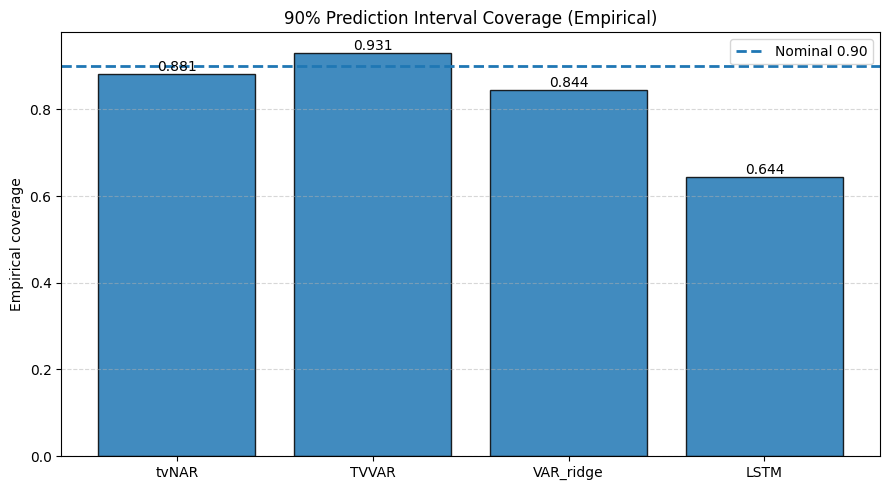


Coverage + Width summary:
tvNAR      coverage=0.881  avg_width=0.3139
TVVAR      coverage=0.931  avg_width=0.1067
VAR_ridge  coverage=0.844  avg_width=0.0980
LSTM       coverage=0.644  avg_width=0.1968


In [ ]:
# ----------------------------
# Step 11 Plot: 90% PI coverage + average PI width for the four models
# ----------------------------
# Uses COVERAGE_RESULTS produced in previous cell.

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Extract and order models
# ----------------------------
names = list(COVERAGE_RESULTS.keys())
coverage = np.array([COVERAGE_RESULTS[n]["coverage_90"] for n in names], float)
widths = np.array([COVERAGE_RESULTS[n]["avg_width_90"] for n in names], float)

# Sort by closeness to nominal 0.90
order = np.argsort(np.abs(coverage - 0.90))
names_s = [names[i] for i in order]
cov_s = coverage[order]
wid_s = widths[order]

# ----------------------------
# 1) Coverage chart
# ----------------------------
plt.figure(figsize=(9, 5))
bars = plt.bar(names_s, cov_s, edgecolor="black", alpha=0.85)
plt.axhline(0.90, linestyle="--", linewidth=2, label="Nominal 0.90")

plt.ylabel("Empirical coverage")
plt.title("90% Prediction Interval Coverage (Empirical)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# annotate bars
for b, s in zip(bars, cov_s):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{s:.3f}", ha="center", va="bottom", fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()
"""
# ----------------------------
# 2) Average PI width chart
# ----------------------------
plt.figure(figsize=(9, 5))
bars2 = plt.bar(names_s, wid_s, edgecolor="black", alpha=0.85)
plt.ylabel("Average PI width (q95 - q05)")
plt.title("90% Prediction Interval Width (Average)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for b, s in zip(bars2, wid_s):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{s:.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()
"""
# ----------------------------
# Optional: print a compact table
# ----------------------------
print("\nCoverage + Width summary:")
for n in names_s:
    print(f"{n:9s}  coverage={COVERAGE_RESULTS[n]['coverage_90']:.3f}  avg_width={COVERAGE_RESULTS[n]['avg_width_90']:.4f}")


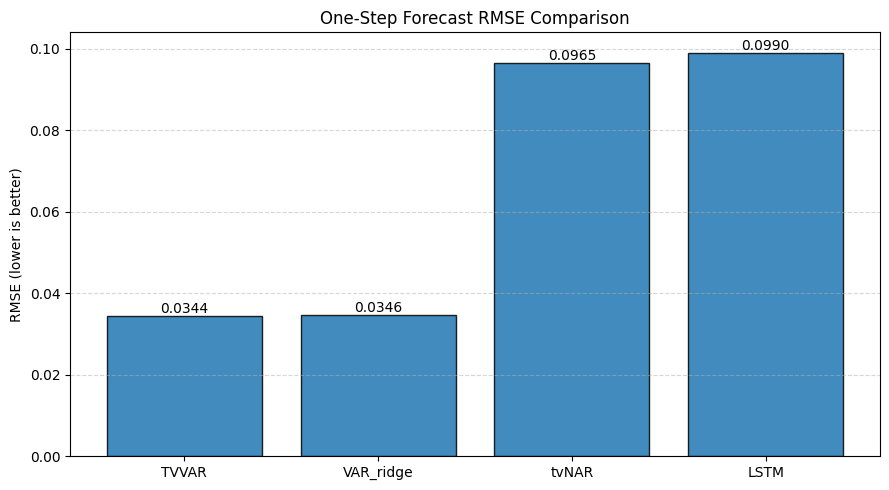


RMSE summary:
TVVAR      RMSE=0.034361
VAR_ridge  RMSE=0.034629
tvNAR      RMSE=0.096451
LSTM       RMSE=0.099038

Saved RMSE_EVAL.


In [ ]:
# ----------------------------
# Step 11a Plot: One-cell: RMSE comparison for VAR(ridge), TV-VAR, tvNAR, and LSTM
# ----------------------------
# Uses the SAME evaluation window and samples already produced for PI/coverage.
#
# Assumes:
#   - PI_EVAL exists (from the PI/coverage cell)
#   - PI_EVAL["samples"][model] is [B,H,V]
#   - PI_EVAL["Y_true"] is [H,V]
#
# RMSE is computed on the MEAN prediction (Monte Carlo mean) for each model.

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Extract data
# ----------------------------
Y_true = PI_EVAL["Y_true"]          # [H,V]
samples = PI_EVAL["samples"]        # dict: model -> [B,H,V]

models = list(samples.keys())

# ----------------------------
# RMSE computation
# ----------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

RMSE_RESULTS = {}

for name, samps in samples.items():
    # mean prediction over samples
    y_mean = samps.mean(axis=0)     # [H,V]
    RMSE_RESULTS[name] = rmse(Y_true, y_mean)

# Sort by RMSE (lower is better)
models_s = sorted(RMSE_RESULTS.keys(), key=lambda k: RMSE_RESULTS[k])
rmse_s = [RMSE_RESULTS[m] for m in models_s]

# ----------------------------
# Plot RMSE comparison
# ----------------------------
plt.figure(figsize=(9, 5))
bars = plt.bar(models_s, rmse_s, edgecolor="black", alpha=0.85)

plt.ylabel("RMSE (lower is better)")
plt.title("One-Step Forecast RMSE Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for b, s in zip(bars, rmse_s):
    plt.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{s:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# ----------------------------
# Print table
# ----------------------------
print("\nRMSE summary:")
for m in models_s:
    print(f"{m:9s}  RMSE={RMSE_RESULTS[m]:.6f}")

# Store for dashboard / paper tables
RMSE_EVAL = {
    "rmse": RMSE_RESULTS,
    "sorted_models": models_s,
    "ACTIVE_W_NAME": PI_EVAL.get("ACTIVE_W_NAME", None),
}
print("\nSaved RMSE_EVAL.")


Created HORIZON_METRICS: {'Ridge VAR': [500, 10, 16], 'TV-VAR': [500, 10, 16], 'DCNAR': [500, 10, 16], 'LSTM (MC Dropout)': [500, 10, 16]}


/tmp/ipykernel_11376/3556729150.py:353: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = plt.cm.get_cmap("tab10")


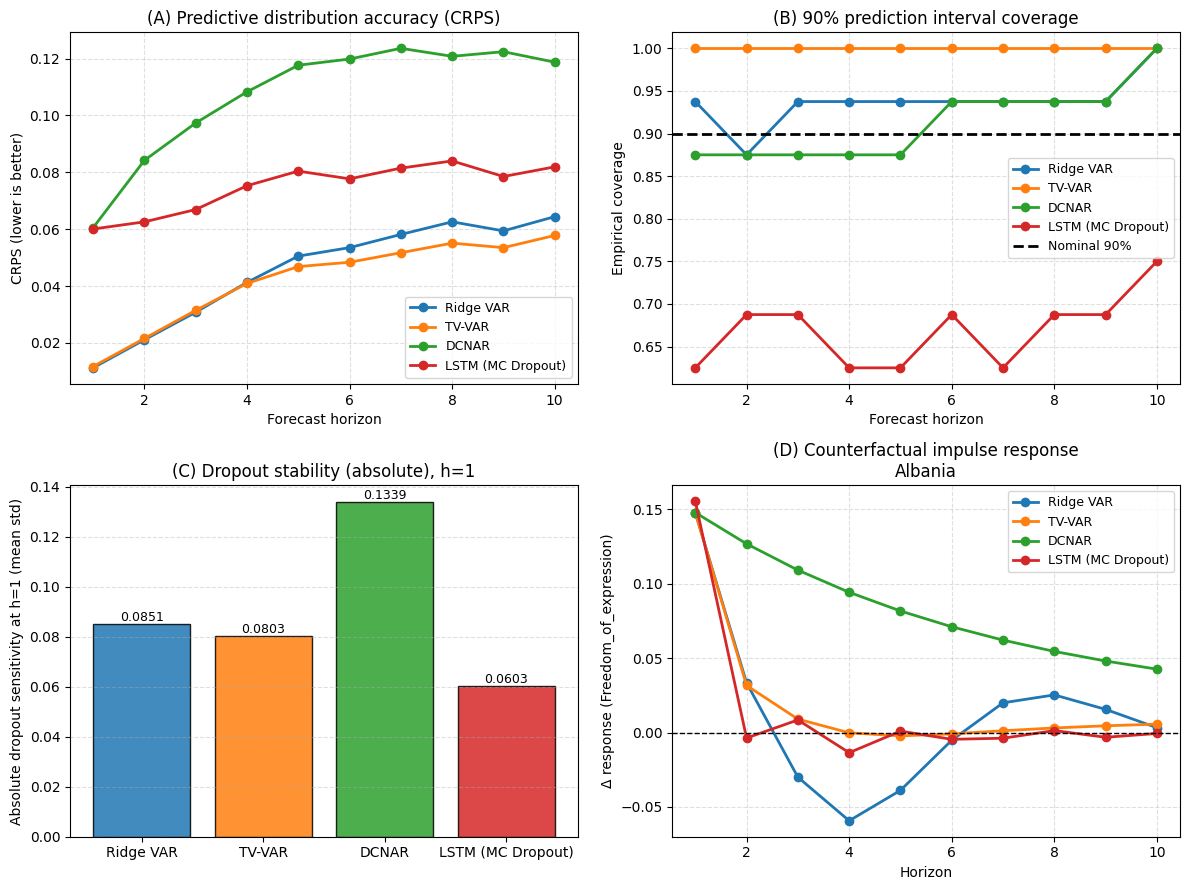

Saved DASHBOARD_SUMMARY.


In [ ]:
# ----------------------------
# Step 11b Plot: Helper functions, preliminary plots
# ----------------------------

# One-cell: build HORIZON_METRICS (if missing) + plot 2x2 dashboard (NO RMSE)
# - Absolute dropout stability (h=1)
# - Consistent colors across quadrants
#
# Requires already defined:
#   - train_df_sorted, var_cols
#   - W_VARIANTS, ACTIVE_W_NAME
#   - cfg (for H_eval, B_paths, bandwidth, tvnar_ridge, lstm_* hyperparams)
#   - IRF_ONE_COUNTRY (for panel D)
#


import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Part 1) Create HORIZON_METRICS if missing
# ============================================================
if "HORIZON_METRICS" not in globals():

    # ----------------------------
    # Data / horizon setup
    # ----------------------------
    Y = train_df_sorted[var_cols].to_numpy(float)  # [T,V]
    T, V = Y.shape

    H = int(getattr(cfg, "H_eval", 10))
    H = max(2, min(H, T - 5))
    fit_end = T - H
    Y_fit = Y[:fit_end]
    Y_true_path = Y[fit_end:fit_end+H]  # [H,V]

    B = int(getattr(cfg, "B_paths", 500))
    B = max(200, B)

    seed = int(getattr(cfg, "seed", 1))
    rng = np.random.default_rng(seed)

    alpha = 0.10
    q_lo, q_hi = alpha/2, 1 - alpha/2

    bandwidth = float(getattr(cfg, "bandwidth", 0.2)) if hasattr(cfg, "bandwidth") else 0.2
    ridge = float(getattr(cfg, "tvnar_ridge", 1e-4)) if hasattr(cfg, "tvnar_ridge") else 1e-4

    W_active = np.asarray(W_VARIANTS[ACTIVE_W_NAME], float)

    # ----------------------------
    # Metrics helpers
    # ----------------------------
    def crps_1d_from_samples(samples_1d: np.ndarray, y_true: float) -> float:
        x = np.sort(samples_1d.astype(float))
        Bn = x.size
        term1 = np.mean(np.abs(x - y_true))
        i = np.arange(1, Bn + 1, dtype=float)
        sum_abs = 2.0 * np.sum((2.0 * i - Bn - 1.0) * x)
        term2 = 0.5 * (sum_abs / (Bn * Bn))
        return float(term1 - term2)

    def crps_by_horizon(Y_true: np.ndarray, Y_samps: np.ndarray) -> np.ndarray:
        Bn, Hn, Vn = Y_samps.shape
        out = np.zeros(Hn, float)
        for h in range(Hn):
            out[h] = np.mean([crps_1d_from_samples(Y_samps[:, h, v], Y_true[h, v]) for v in range(Vn)])
        return out

    def coverage90_by_horizon(Y_true: np.ndarray, Y_samps: np.ndarray) -> np.ndarray:
        lo = np.quantile(Y_samps, q_lo, axis=0)  # [H,V]
        hi = np.quantile(Y_samps, q_hi, axis=0)  # [H,V]
        inside = (Y_true >= lo) & (Y_true <= hi)
        return inside.mean(axis=1)

    # ----------------------------
    # VAR(1) ridge: fit + multi-step bootstrap rollout
    # ----------------------------
    def fit_var1_ridge(Y_fit: np.ndarray, ridge: float = 1e-4):
        Y0 = Y_fit[:-1]
        Y1 = Y_fit[1:]
        XtX = Y0.T @ Y0 + ridge * np.eye(V)
        A_T = np.linalg.solve(XtX, Y0.T @ Y1)
        A = A_T.T
        resid = Y1 - (Y0 @ A.T)
        return A, resid

    def rollout_VAR_paths(y0: np.ndarray, A: np.ndarray, resid_pool: np.ndarray, H: int, B: int) -> np.ndarray:
        out = np.zeros((B, H, V), float)
        Tpool = resid_pool.shape[0]
        for b in range(B):
            y_prev = y0.copy()
            idx = rng.integers(0, Tpool, size=H)
            eps = resid_pool[idx]
            for h in range(H):
                y_next = (A @ y_prev) + eps[h]
                out[b, h] = y_next
                y_prev = y_next
        return out

    A_var, resid_var = fit_var1_ridge(Y_fit, ridge=1e-4)

    # ----------------------------
    # TV-VAR(1): local ridge at end-of-fit + weighted residual sampling
    # ----------------------------
    def kernel_weights(taus: np.ndarray, tau_star: float, bandwidth: float, kernel: str = "gaussian"):
        u = (taus - tau_star) / bandwidth
        if kernel == "gaussian":
            w = np.exp(-0.5 * u*u)
        elif kernel == "epanechnikov":
            w = 0.75 * (1 - u*u) * (np.abs(u) <= 1)
        else:
            raise ValueError("kernel must be 'gaussian' or 'epanechnikov'")
        s = float(w.sum())
        if s <= 0:
            w = np.ones_like(w)
            s = float(w.sum())
        return w / (s + 1e-12)

    def fit_tvvar1_local(Y_fit: np.ndarray, bandwidth: float, ridge: float, kernel: str = "gaussian"):
        Tfit = Y_fit.shape[0]
        Y0 = Y_fit[:-1]
        Y1 = Y_fit[1:]
        taus = np.arange(1, Tfit) / Tfit
        tau_star = (Tfit - 1) / Tfit
        w = kernel_weights(taus, tau_star, bandwidth, kernel=kernel)
        sw = np.sqrt(w)[:, None]
        Xw = Y0 * sw
        Yw = Y1 * sw
        XtX = Xw.T @ Xw + ridge * np.eye(V)
        A_T = np.linalg.solve(XtX, Xw.T @ Yw)
        A = A_T.T
        resid = Y1 - (Y0 @ A.T)
        return A, resid, w

    def rollout_TVVAR_paths(y0: np.ndarray, A: np.ndarray, resid_pool: np.ndarray, resid_w: np.ndarray, H: int, B: int):
        out = np.zeros((B, H, V), float)
        p = resid_w / (resid_w.sum() + 1e-12)
        idxs = np.arange(resid_pool.shape[0])
        for b in range(B):
            y_prev = y0.copy()
            idx = rng.choice(idxs, size=H, replace=True, p=p)
            eps = resid_pool[idx]
            for h in range(H):
                y_next = (A @ y_prev) + eps[h]
                out[b, h] = y_next
                y_prev = y_next
        return out

    A_tv, resid_tv, w_tv = fit_tvvar1_local(Y_fit, bandwidth=bandwidth, ridge=ridge, kernel="gaussian")

    # ----------------------------
    # tvNAR (DCNAR): local lambda at end-of-fit + residual sampling
    # ----------------------------
    def row_normalize_L1_signed(W: np.ndarray, eps: float = 1e-12) -> np.ndarray:
        denom = np.sum(np.abs(W), axis=1, keepdims=True)
        denom = np.where(denom < eps, 1.0, denom)
        return W / denom

    def tvnar_lambda_hat(Y_fit: np.ndarray, W: np.ndarray, bandwidth: float, ridge: float, kernel: str = "gaussian"):
        Tfit, N = Y_fit.shape
        Wn = row_normalize_L1_signed(W)
        W_hat = Wn + np.eye(N)

        t_idx = Tfit - 1
        tau = t_idx / Tfit
        taus = np.arange(1, t_idx) / Tfit
        w = kernel_weights(taus, tau, bandwidth, kernel=kernel)

        X_blocks, y_blocks = [], []
        for s, ws in zip(range(1, t_idx), w):
            y_prev = Y_fit[s-1]
            X_s = W_hat * y_prev[None, :]
            X_blocks.append(np.sqrt(ws) * X_s)
            y_blocks.append(np.sqrt(ws) * Y_fit[s])

        X = np.vstack(X_blocks)
        y_vec = np.concatenate(y_blocks, axis=0)
        XtX = X.T @ X + ridge * np.eye(N)
        Xty = X.T @ y_vec
        lam = np.linalg.solve(XtX, Xty)
        return lam, Wn

    def tvnar_mean_step(y_prev: np.ndarray, Wn: np.ndarray, lam: np.ndarray):
        W_hat = Wn + np.eye(V)
        return (W_hat * y_prev[None, :]) @ lam

    lam_tn, Wn_tn = tvnar_lambda_hat(Y_fit, W_active, bandwidth=bandwidth, ridge=ridge, kernel="gaussian")

    resid_pool_tn = []
    for t in range(1, Y_fit.shape[0]):
        yhat = tvnar_mean_step(Y_fit[t-1], Wn_tn, lam_tn)
        resid_pool_tn.append(Y_fit[t] - yhat)
    resid_pool_tn = np.vstack(resid_pool_tn)

    def rollout_tvNAR_paths(y0: np.ndarray, Wn: np.ndarray, lam: np.ndarray, resid_pool: np.ndarray, H: int, B: int):
        out = np.zeros((B, H, V), float)
        Tpool = resid_pool.shape[0]
        for b in range(B):
            y_prev = y0.copy()
            idx = rng.integers(0, Tpool, size=H)
            eps = resid_pool[idx]
            for h in range(H):
                y_next = tvnar_mean_step(y_prev, Wn, lam) + eps[h]
                out[b, h] = y_next
                y_prev = y_next
        return out

    # ----------------------------
    # LSTM (MC dropout): train on fit window, multi-step rollout
    # ----------------------------
    USE_TORCH = True
    try:
        import torch
        import torch.nn as nn
    except Exception:
        USE_TORCH = False

    lstm_ready = False
    if USE_TORCH:
        class SimpleLSTM(nn.Module):
            def __init__(self, input_dim, hidden=64, layers=1, dropout=0.2):
                super().__init__()
                self.lstm = nn.LSTM(input_dim, hidden, num_layers=layers, batch_first=True,
                                    dropout=dropout if layers > 1 else 0.0)
                self.drop = nn.Dropout(dropout)
                self.head = nn.Linear(hidden, input_dim)
            def forward(self, x):
                out, _ = self.lstm(x)
                h = out[:, -1, :]
                h = self.drop(h)
                return self.head(h)

        def build_seq_dataset(Y_arr, Lseq):
            X, y = [], []
            for t in range(Lseq, Y_arr.shape[0]):
                X.append(Y_arr[t-Lseq:t])
                y.append(Y_arr[t])
            return np.asarray(X, float), np.asarray(y, float)

        def train_lstm(Y_fit, Lseq, hidden, layers, dropout, epochs, batch, lr, device):
            X, y = build_seq_dataset(Y_fit, Lseq)
            if X.shape[0] < 100:
                raise ValueError(f"Not enough sequences for LSTM: have {X.shape[0]}. Reduce Lseq or increase fit window.")
            X_t = torch.tensor(X, dtype=torch.float32, device=device)
            y_t = torch.tensor(y, dtype=torch.float32, device=device)
            model = SimpleLSTM(V, hidden=hidden, layers=layers, dropout=dropout).to(device)
            opt = torch.optim.Adam(model.parameters(), lr=lr)
            loss_fn = nn.MSELoss()
            model.train()
            n = X_t.shape[0]
            for _ in range(epochs):
                perm = torch.randperm(n, device=device)
                for i0 in range(0, n, batch):
                    idx = perm[i0:i0+batch]
                    xb = X_t[idx]
                    yb = y_t[idx]
                    opt.zero_grad()
                    pred = model(xb)
                    loss = loss_fn(pred, yb)
                    loss.backward()
                    opt.step()
            return model

        def lstm_predict_next(model, hist, Lseq, device):
            if hist.shape[0] < Lseq:
                pad = np.repeat(hist[:1], Lseq - hist.shape[0], axis=0)
                seq = np.vstack([pad, hist])
            else:
                seq = hist[-Lseq:]
            x = torch.tensor(seq[None, :, :], dtype=torch.float32, device=device)
            return model(x).detach().cpu().numpy()[0]

        def rollout_LSTM_paths(model, hist0, Lseq, H, B, device):
            out = np.zeros((B, H, V), float)
            model.train()
            with torch.no_grad():
                for b in range(B):
                    hist = hist0.copy()
                    for h in range(H):
                        y_next = lstm_predict_next(model, hist, Lseq, device)
                        out[b, h] = y_next
                        hist = np.vstack([hist, y_next])
            return out

        device = "cuda" if (hasattr(torch, "cuda") and torch.cuda.is_available()) else "cpu"
        Lseq = int(getattr(cfg, "lstm_seq_len", 8))
        hidden = int(getattr(cfg, "lstm_hidden", 64))
        layers = int(getattr(cfg, "lstm_layers", 1))
        dropout = float(getattr(cfg, "lstm_dropout", 0.2))
        epochs = int(getattr(cfg, "lstm_epochs", 40))
        batch = int(getattr(cfg, "lstm_batch", 256))
        lr = float(getattr(cfg, "lstm_lr", 1e-3))

        Lseq = min(Lseq, max(2, Y_fit.shape[0] - 100))
        lstm_model = train_lstm(Y_fit, Lseq, hidden, layers, dropout, epochs, batch, lr, device)
        lstm_ready = True
    else:
        lstm_model = None
        device = "cpu"
        Lseq = 8

    # ----------------------------
    # Generate samples from a single forecast origin
    # ----------------------------
    y0 = Y[fit_end - 1]
    hist0 = Y[:fit_end].copy()

    SAMPLES = {}
    SAMPLES["Ridge VAR"] = rollout_VAR_paths(y0, A_var, resid_var, H, B)
    SAMPLES["TV-VAR"] = rollout_TVVAR_paths(y0, A_tv, resid_tv, w_tv, H, B)
    SAMPLES["DCNAR"] = rollout_tvNAR_paths(y0, Wn_tn, lam_tn, resid_pool_tn, H, B)
    if lstm_ready:
        SAMPLES["LSTM (MC Dropout)"] = rollout_LSTM_paths(lstm_model, hist0, Lseq, H, B, device)

    CRPS_H = {k: crps_by_horizon(Y_true_path, v) for k, v in SAMPLES.items()}
    COV_H  = {k: coverage90_by_horizon(Y_true_path, v) for k, v in SAMPLES.items()}

    HORIZON_METRICS = {
        "Y_true_path": Y_true_path,
        "fit_end": fit_end,
        "H": H,
        "B": B,
        "ACTIVE_W_NAME": ACTIVE_W_NAME,
        "samples": SAMPLES,
        "crps_by_h": CRPS_H,
        "coverage90_by_h": COV_H,
    }

    print("Created HORIZON_METRICS:", {k: list(v.shape) for k, v in SAMPLES.items()})

# ============================================================
# Dashboard code
# ============================================================
CRPS_H = HORIZON_METRICS["crps_by_h"]
COV_H  = HORIZON_METRICS["coverage90_by_h"]
SAMPLES = HORIZON_METRICS.get("samples", None)
H = int(HORIZON_METRICS["H"])
horizons = np.arange(1, H+1)

if SAMPLES is None:
    raise RuntimeError("HORIZON_METRICS['samples'] not found.")

MODEL_KEYS = {
    "Ridge VAR": "Ridge VAR",
    "TV-VAR": "TV-VAR",
    "DCNAR": "DCNAR",
    "LSTM (MC Dropout)": "LSTM (MC Dropout)",
}
plot_order = [k for k in MODEL_KEYS.keys() if k in CRPS_H]
def pretty(k): return MODEL_KEYS.get(k, k)

tab10 = plt.cm.get_cmap("tab10")
COLOR = {
    "Ridge VAR": tab10(0),
    "TV-VAR": tab10(1),
    "DCNAR": tab10(2),
    "LSTM (MC Dropout)": tab10(3),
}

def abs_dropout_stability_h1(samples_BHV: np.ndarray) -> float:
    std_v = np.std(samples_BHV[:, 0, :], axis=0)
    return float(std_v.mean())

ABS_STAB = {k: abs_dropout_stability_h1(SAMPLES[k]) for k in plot_order}

IRF = IRF_ONE_COUNTRY
H_irf = int(IRF["H"])
h_irf = np.arange(1, H_irf+1)
resp_idx = IRF.get("response_var_idx", IRF.get("shock_var_idx", 0))
country_name = IRF.get("country", "Country")
resp_name = IRF.get("response_var_name", var_cols[resp_idx] if resp_idx < len(var_cols) else f"var{resp_idx}")

IRF_SERIES = {
    "Ridge VAR": np.asarray(IRF["VAR"]["delta"][:, resp_idx], float),
    "TV-VAR": np.asarray(IRF["TVVAR"]["delta"][:, resp_idx], float),
    "DCNAR": np.asarray(IRF["tvNAR"]["delta"][:, resp_idx], float),
}
if "LSTM" in IRF and isinstance(IRF["LSTM"].get("delta", None), np.ndarray):
    IRF_SERIES["LSTM (MC Dropout)"] = np.asarray(IRF["LSTM"]["delta"][:, resp_idx], float)

plt.figure(figsize=(12, 9))

# (A) CRPS
ax1 = plt.subplot(2, 2, 1)
for k in plot_order:
    ax1.plot(horizons, np.asarray(CRPS_H[k], float), marker="o", linewidth=2, label=pretty(k), color=COLOR.get(k, None))
ax1.set_xlabel("Forecast horizon")
ax1.set_ylabel("CRPS (lower is better)")
ax1.set_title("(A) Predictive distribution accuracy (CRPS)")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend(fontsize=9)

# (B) Coverage
ax2 = plt.subplot(2, 2, 2)
for k in plot_order:
    ax2.plot(horizons, np.asarray(COV_H[k], float), marker="o", linewidth=2, label=pretty(k), color=COLOR.get(k, None))
ax2.axhline(0.90, linestyle="--", linewidth=2, color="black", label="Nominal 90%")
ax2.set_xlabel("Forecast horizon")
ax2.set_ylabel("Empirical coverage")
ax2.set_title("(B) 90% prediction interval coverage")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend(fontsize=9)

# (C) Absolute dropout stability (h=1)
ax3 = plt.subplot(2, 2, 3)
bar_labels = [pretty(k) for k in plot_order]
bar_vals = [ABS_STAB[k] for k in plot_order]
bar_colors = [COLOR.get(k, tab10(7)) for k in plot_order]
bars = ax3.bar(bar_labels, bar_vals, edgecolor="black", alpha=0.85, color=bar_colors)
ax3.set_ylabel("Absolute dropout sensitivity at h=1 (mean std)")
ax3.set_title("(C) Dropout stability (absolute), h=1")
ax3.grid(axis="y", linestyle="--", alpha=0.4)
for b, val in zip(bars, bar_vals):
    ax3.text(b.get_x() + b.get_width()/2, b.get_height(), f"{val:.4f}", ha="center", va="bottom", fontsize=9)

# (D) IRF
ax4 = plt.subplot(2, 2, 4)
for k, series in IRF_SERIES.items():
    ax4.plot(h_irf, series, marker="o", linewidth=2, label=pretty(k), color=COLOR.get(k, None))
ax4.axhline(0.0, linestyle="--", linewidth=1, color="black")
ax4.set_xlabel("Horizon")
ax4.set_ylabel(f"Δ response ({resp_name})")
ax4.set_title(f"(D) Counterfactual impulse response\n{country_name}")
ax4.grid(True, linestyle="--", alpha=0.4)
ax4.legend(fontsize=9)

plt.tight_layout()
plt.show()

DASHBOARD_SUMMARY = {
    "crps_by_h": CRPS_H,
    "coverage90_by_h": COV_H,
    "dropout_abs_h1": ABS_STAB,
    "irf_country": country_name,
    "irf_response_var": resp_name,
    "irf_delta": {pretty(k): v for k, v in IRF_SERIES.items()},
}
print("Saved DASHBOARD_SUMMARY.")


/tmp/ipykernel_11376/4033339308.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = plt.cm.get_cmap("tab10")


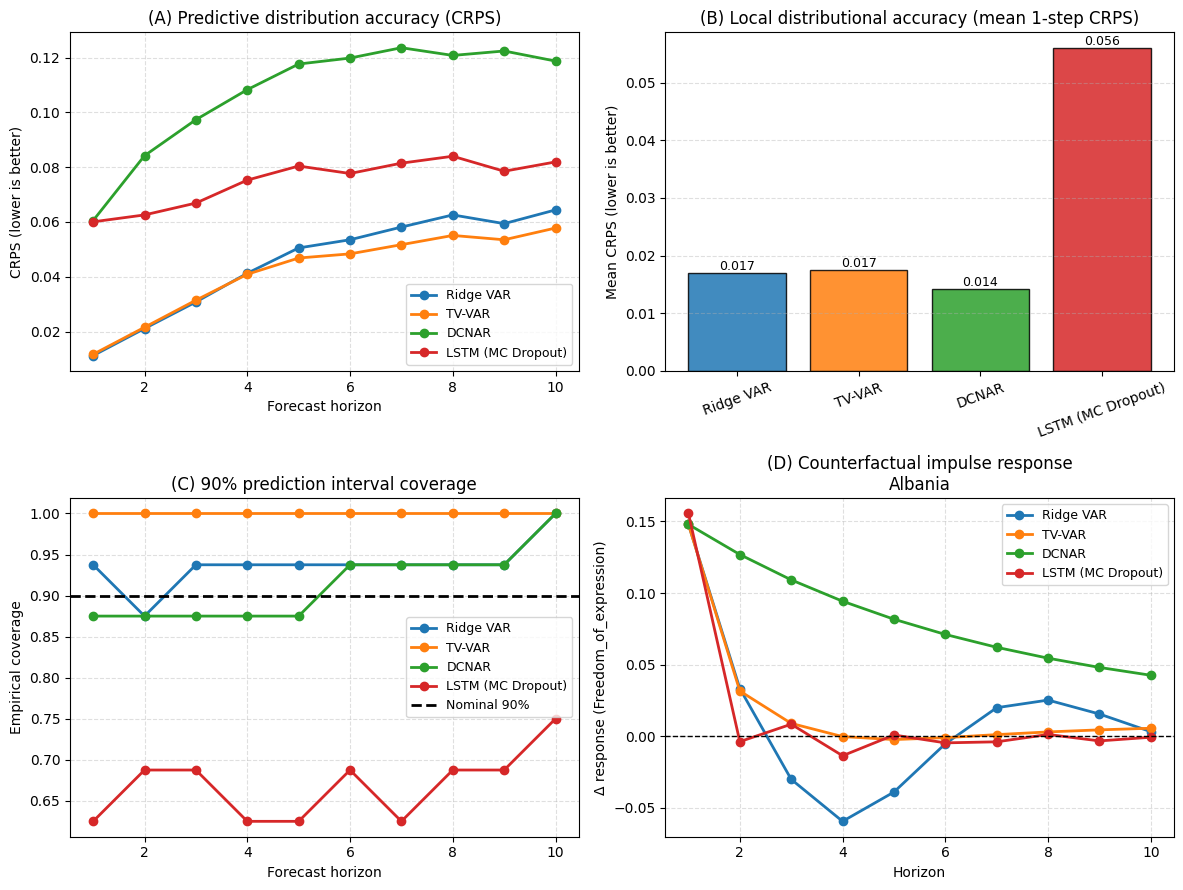

In [ ]:
# ----------------------------
# Step 11c Plot: Full comparison for VAR(ridge), TV-VAR, tvNAR, and LSTM
# ----------------------------


# --- Canonical keys and colors (use one set everywhere) ---
tab10 = plt.cm.get_cmap("tab10")
COLOR = {
    "Ridge VAR": tab10(0),
    "TV-VAR": tab10(1),
    "DCNAR": tab10(2),
    "LSTM (MC Dropout)": tab10(3),
}

# --- Map local-CRPS names -> canonical names ---
LOCAL_TO_CANON = {
    "VAR": "Ridge VAR",
    "TV-VAR": "TV-VAR",
    "tvNAR": "DCNAR",
    "LSTM": "LSTM (MC Dropout)",
}

# Build a canonical local-CRPS dict from EVAL_RESULTS
local_crps = {LOCAL_TO_CANON[k]: float(v) for k, v in EVAL_RESULTS["crps"].items() if k in LOCAL_TO_CANON}

# Order for plots
plot_order = [k for k in ["Ridge VAR", "TV-VAR", "DCNAR", "LSTM (MC Dropout)"] if k in HORIZON_METRICS["crps_by_h"]]

# --- Absolute dropout stability at h=1 from HORIZON_METRICS samples ---
def abs_dropout_stability_h1(samples_BHV: np.ndarray) -> float:
    std_v = np.std(samples_BHV[:, 0, :], axis=0)  # horizon 1 => index 0
    return float(std_v.mean())

ABS_STAB = {k: abs_dropout_stability_h1(HORIZON_METRICS["samples"][k]) for k in plot_order}

# --- IRF series (one-country) ---
IRF = IRF_ONE_COUNTRY
resp_idx = IRF.get("response_var_idx", IRF.get("shock_var_idx", 0))
resp_name = IRF.get("response_var_name", var_cols[resp_idx])
country_name = IRF.get("country", "Country")
h_irf = np.arange(1, int(IRF["H"]) + 1)

IRF_SERIES = {
    "Ridge VAR": np.asarray(IRF["VAR"]["delta"][:, resp_idx], float),
    "TV-VAR": np.asarray(IRF["TVVAR"]["delta"][:, resp_idx], float),
    "DCNAR": np.asarray(IRF["tvNAR"]["delta"][:, resp_idx], float),
}
if "LSTM" in IRF and isinstance(IRF["LSTM"].get("delta", None), np.ndarray):
    IRF_SERIES["LSTM (MC Dropout)"] = np.asarray(IRF["LSTM"]["delta"][:, resp_idx], float)

# --- Plot ---
H = int(HORIZON_METRICS["H"])
horizons = np.arange(1, H + 1)

CRPS_H = HORIZON_METRICS["crps_by_h"]
COV_H  = HORIZON_METRICS["coverage90_by_h"]

plt.figure(figsize=(12, 9))

# (A) CRPS vs horizon
ax1 = plt.subplot(2, 2, 1)
for k in plot_order:
    ax1.plot(horizons, np.asarray(CRPS_H[k], float), marker="o", linewidth=2, label=k, color=COLOR[k])
ax1.set_title("(A) Predictive distribution accuracy (CRPS)")
ax1.set_xlabel("Forecast horizon")
ax1.set_ylabel("CRPS (lower is better)")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend(fontsize=9)

# (B) Local distributional accuracy (mean 1-step CRPS) — BAR
ax2 = plt.subplot(2, 2, 2)
bar_models = [k for k in plot_order if k in local_crps]
bar_vals = [local_crps[k] for k in bar_models]
bars = ax2.bar(bar_models, bar_vals, edgecolor="black", alpha=0.85, color=[COLOR[k] for k in bar_models])
ax2.set_title("(B) Local distributional accuracy (mean 1-step CRPS)")
ax2.set_ylabel("Mean CRPS (lower is better)")
ax2.grid(axis="y", linestyle="--", alpha=0.4)
for b, val in zip(bars, bar_vals):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height(), f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax2.tick_params(axis="x", rotation=20)

# (C) 90% coverage vs horizon
ax3 = plt.subplot(2, 2, 3)
for k in plot_order:
    ax3.plot(horizons, np.asarray(COV_H[k], float), marker="o", linewidth=2, label=k, color=COLOR[k])
ax3.axhline(0.90, linestyle="--", linewidth=2, color="black", label="Nominal 90%")
ax3.set_title("(C) 90% prediction interval coverage")
ax3.set_xlabel("Forecast horizon")
ax3.set_ylabel("Empirical coverage")
ax3.grid(True, linestyle="--", alpha=0.4)
ax3.legend(fontsize=9)

# (D) Counterfactual impulse response
ax4 = plt.subplot(2, 2, 4)
for k in plot_order:
    if k in IRF_SERIES:
        ax4.plot(h_irf, IRF_SERIES[k], marker="o", linewidth=2, label=k, color=COLOR[k])
ax4.axhline(0.0, linestyle="--", linewidth=1, color="black")
ax4.set_title(f"(D) Counterfactual impulse response\n{country_name}")
ax4.set_xlabel("Horizon")
ax4.set_ylabel(f"Δ response ({resp_name})")
ax4.grid(True, linestyle="--", alpha=0.4)
ax4.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
print({k: HORIZON_METRICS["crps_by_h"][k][0] for k in HORIZON_METRICS["crps_by_h"]})


{'Ridge VAR': np.float64(0.011225717638461911), 'TV-VAR': np.float64(0.011696734764931133), 'DCNAR': np.float64(0.06134233637788485), 'LSTM (MC Dropout)': np.float64(0.06437487274088337)}


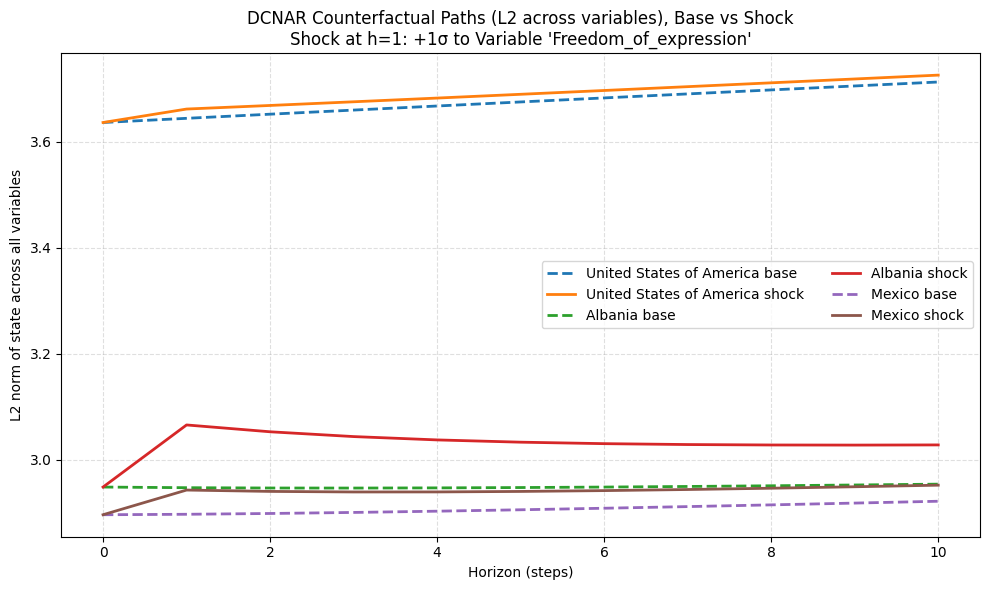

In [ ]:
# One-cell: tvNAR only — L2 norm across ALL variables, base vs shock (levels),
# overlaying three countries: Albania + United States + Mexico
#
# Requires:
#   - train_df_sorted, var_cols
#   - cfg.country_col, cfg.time_col
#   - W_VARIANTS, ACTIVE_W_NAME
#   - lam_vecs_inferred (shape [p,N]) OR lam_vecs global [p,N] from your tvNAR fit
#   - counterfactual_shock_tvnar() from your earlier cell (uses lam_vecs + W)
#
# If you used a different variable list order for lam_vecs, ensure it matches var_cols.

import numpy as np
import matplotlib.pyplot as plt

country_col = getattr(cfg, "country_col", "country_id")
time_col = getattr(cfg, "time_col", "year")

# ---- choose countries by *name as it appears in your country_col* ----
COUNTRIES_TO_PLOT = ["United States of America", "Albania", "Mexico"]  #["Albania", "Mexico"]

H = 10
shock_var_name = "Freedom_of_expression" if "Freedom_of_expression" in var_cols else var_cols[0]
shock_var = var_cols.index(shock_var_name)

# ---- tvNAR inputs ----
W_tvnar = np.asarray(W_VARIANTS[ACTIVE_W_NAME], float)

# Prefer an existing lam_vecs from your tvNAR run
if "lam_vecs_inferred" in globals():
    lam_vecs = np.asarray(lam_vecs_inferred, float)
elif "lam_vecs" in globals():
    lam_vecs = np.asarray(lam_vecs, float)
else:
    raise RuntimeError("lam_vecs not found. Provide lam_vecs_inferred or lam_vecs from your tvNAR fit.")

p, N = lam_vecs.shape
assert N == len(var_cols), f"lam_vecs has N={N} but var_cols has {len(var_cols)}"

if lam_vecs_inferred is None or np.allclose(lam_vecs_inferred, 0.1):
    raise RuntimeError(
        "lam_vecs not available (placeholder detected). "
        "Run the tvNAR fitting step to produce lam_vecs (shape [p,N]) before running IRFs."
    )


# ---- shock size: +1 std within each country's training series (more interpretable) ----
def shock_size_for_country(series_train, idx):
    return float(np.std(series_train[:, idx]) + 1e-12)

def l2_levels(series, base_path, shock_path):
    """
    series: [L,N] (history); base_path/shock_path: [H,N]
    return:
      t: [0..H]
      base_L2: [H+1]
      shock_L2:[H+1]
    """
    y0 = series[-1]  # last observed value before forecasting
    base_L2 = np.concatenate([[np.linalg.norm(y0)], np.linalg.norm(base_path, axis=1)])
    shock_L2 = np.concatenate([[np.linalg.norm(y0)], np.linalg.norm(shock_path, axis=1)])
    return np.arange(0, H+1), base_L2, shock_L2

# ---- fetch per-country series from train_df_sorted ----
def get_country_series(country_name):
    sub = train_df_sorted[train_df_sorted[country_col] == country_name].sort_values(time_col)
    if len(sub) == 0:
        raise KeyError(f"Country '{country_name}' not found in {country_col}.")
    return sub[var_cols].to_numpy(float)

# ---- run tvNAR counterfactual + plot ----
plt.figure(figsize=(10, 6))

for cname in COUNTRIES_TO_PLOT:
    series_train = get_country_series(cname)  # [L,N]
    if series_train.shape[0] < p + 2:
        print(f"Skipping {cname}: too few points (L={series_train.shape[0]}) for p={p}")
        continue

    ss = shock_size_for_country(series_train, shock_var)

    y_base, y_shock, _ = counterfactual_shock_tvnar(
        series_train=series_train,
        W=W_tvnar,
        lam_vecs=lam_vecs,
        shock_var=shock_var,
        shock_size=ss,
        horizon=H
    )

    t, base_L2, shock_L2 = l2_levels(series_train, y_base, y_shock)

    # Base dashed, shock solid
    plt.plot(t, base_L2, linestyle="--", linewidth=2, label=f"{cname} base")
    plt.plot(t, shock_L2, linestyle="-", linewidth=2, label=f"{cname} shock")

plt.xlabel("Horizon (steps)")
plt.ylabel("L2 norm of state across all variables")
plt.title(
    f"DCNAR Counterfactual Paths (L2 across variables), Base vs Shock\n"
    f"Shock at h=1: +1σ to Variable '{shock_var_name}'"
)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


# Appendix

In [ ]:
print("Bar chart source keys (PI_EVAL):", list(PI_EVAL["samples"].keys()) if "PI_EVAL" in globals() else "PI_EVAL missing")
print("Dashboard source keys (HORIZON_METRICS):", list(HORIZON_METRICS["samples"].keys()) if "HORIZON_METRICS" in globals() else "HORIZON_METRICS missing")

# Compare CRPS at horizon 1 from dashboard vs CRPS computed directly from its samples
def crps_1d(samples, y):
    x = np.sort(samples)
    Bn = x.size
    term1 = np.mean(np.abs(x - y))
    i = np.arange(1, Bn+1, dtype=float)
    sum_abs = 2*np.sum((2*i - Bn - 1)*x)
    term2 = 0.5*(sum_abs/(Bn*Bn))
    return term1 - term2

def mean_crps_h1_from_samples(samples_BHV, y_true_HV):
    # horizon 1 => index 0
    s = samples_BHV[:, 0, :]
    y = y_true_HV[0, :]
    return float(np.mean([crps_1d(s[:, v], y[v]) for v in range(s.shape[1])]))

for k in HORIZON_METRICS["samples"].keys():
    c = mean_crps_h1_from_samples(HORIZON_METRICS["samples"][k], HORIZON_METRICS["Y_true_path"])
    print("Dashboard horizon1 CRPS recomputed:", k, c)

# And the same for PI_EVAL (one-step)
if "PI_EVAL" in globals():
    for k in PI_EVAL["samples"].keys():
        # here horizon1 corresponds to that one-step window; treat it as h=1
        # PI_EVAL["Y_true"] is [H,V] for one-step window; use its first row
        c = mean_crps_h1_from_samples(PI_EVAL["samples"][k], PI_EVAL["Y_true"])
        print("PI_EVAL horizon1 CRPS recomputed:", k, c)


Bar chart source keys (PI_EVAL): ['VAR_ridge', 'TVVAR', 'tvNAR', 'LSTM']
Dashboard source keys (HORIZON_METRICS): ['Ridge VAR', 'TV-VAR', 'DCNAR', 'LSTM (MC Dropout)']
Dashboard horizon1 CRPS recomputed: Ridge VAR 0.007415678899384944
Dashboard horizon1 CRPS recomputed: TV-VAR 0.007748535471016803
Dashboard horizon1 CRPS recomputed: DCNAR 0.07242726394132283
Dashboard horizon1 CRPS recomputed: LSTM (MC Dropout) 0.03629457160051307
PI_EVAL horizon1 CRPS recomputed: VAR_ridge 0.007158810972772274
PI_EVAL horizon1 CRPS recomputed: TVVAR 0.008089416972238403
PI_EVAL horizon1 CRPS recomputed: tvNAR 0.07407668565300796
PI_EVAL horizon1 CRPS recomputed: LSTM 0.04311295410502958


## Testing different appendix types

In [ ]:
# ------------------------------------------------------------
# Step X  Testing various matrices with respect to error
# ------------------------------------------------------------

import numpy as np
import pandas as pd
from tvNAR import fit_tvNAR_lambda_paths

# --- Preconditions ---
# Must exist: Y_train (full panel), W_VARIANTS, split_spec, cfg
Y = np.asarray(Y_train, float)
T, N = Y.shape

H = int(getattr(cfg, "H_eval", 10))
H = max(5, min(H, T - 3))

bandwidth = float(getattr(cfg, "bandwidth", 0.2)) if hasattr(cfg, "bandwidth") else 0.2
ridge = float(getattr(cfg, "tvnar_ridge", 1e-4)) if hasattr(cfg, "tvnar_ridge") else 1e-4
grid_size = 50
kernel = "gaussian"

B = int(getattr(cfg, "B_paths", 500))
B = max(200, B)
rng = np.random.default_rng(int(getattr(cfg, "seed", 1)))

# --- Metrics helpers ---
def mse(y, yhat): return float(np.mean((y - yhat) ** 2))
def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat) ** 2)))
def mae(y, yhat): return float(np.mean(np.abs(y - yhat)))

def crps_1d_from_samples(samples_1d: np.ndarray, y_true: float) -> float:
    x = np.sort(samples_1d.astype(float))
    Bn = x.size
    term1 = np.mean(np.abs(x - y_true))
    i = np.arange(1, Bn + 1, dtype=float)
    sum_abs = 2.0 * np.sum((2.0 * i - Bn - 1.0) * x)
    term2 = 0.5 * (sum_abs / (Bn * Bn))
    return float(term1 - term2)

def mean_crps(y_true_vec: np.ndarray, samples_BN: np.ndarray) -> float:
    return float(np.mean([crps_1d_from_samples(samples_BN[:, j], y_true_vec[j]) for j in range(y_true_vec.size)]))

def tvnar_mean_one_step(W: np.ndarray, lam_vec: np.ndarray, y_prev: np.ndarray) -> np.ndarray:
    W_hat = W + np.eye(N)
    return (W_hat * y_prev[None, :]) @ lam_vec

# --- Evaluation window: last H points of the FULL panel (as in your local CRPS code) ---
eval_start = T - H
Y_true = Y[eval_start:]  # [H,N]

rows = []
TVNAR_FITS_BY_W = {}  # optional: keep tv + lam_vecs for later IRFs

for W_name, W_active in W_VARIANTS.items():
    W_active = np.asarray(W_active, float)

    if W_active.shape != (N, N):
        print(f"[skip] {W_name}: W shape {W_active.shape} != {(N,N)}")
        continue
    if np.allclose(W_active, 0.0):
        print(f"[skip] {W_name}: all-zero W")
        continue

    try:
        # ------------------------------------------------------------
        # EXACTLY your Step 5(B): train tvNAR on FULL Y_train with THIS W
        # ------------------------------------------------------------
        tv = fit_tvNAR_lambda_paths(
            Y=Y,
            W=W_active,
            split_timeseries=split_spec,
            grid_size=grid_size,
            bandwidth=bandwidth,
            kernel=kernel,
            ridge=ridge,
            tau_mode="within_series",
            center=False,
        )

        lam_grid = np.asarray(tv["lambda"], float)  # [grid_size, N]
        lam_last = lam_grid[-1] if cfg.tvnar_lambda_policy == "last" else lam_grid.mean(axis=0)

        p = int(getattr(cfg, "tvnar_lags", 1))
        lam_vecs = np.vstack([lam_last[None, :] for _ in range(p)])  # [p, N]

        # store for later use (IRFs etc.)
        TVNAR_FITS_BY_W[W_name] = {"tv": tv, "lam_grid": lam_grid, "lam_vecs": lam_vecs, "W_active": W_active}

        # ------------------------------------------------------------
        # Quick evaluation (one-step, last H points) on FULL panel
        # Empirical predictive distribution: mean_pred + bootstrapped residuals
        # ------------------------------------------------------------
        # residual pool from FULL panel (one-step, using lam_last)
        resid_pool = []
        for t in range(1, T):
            resid_pool.append(Y[t] - tvnar_mean_one_step(W_active, lam_last, Y[t-1]))
        resid_pool = np.vstack(resid_pool)  # [T-1, N]

        preds = np.zeros((H, N), float)
        crps_vals = []

        for h in range(H):
            t_global = eval_start + h
            y_prev = Y[t_global - 1]
            mean_pred = tvnar_mean_one_step(W_active, lam_last, y_prev)
            preds[h] = mean_pred

            idx = rng.integers(0, resid_pool.shape[0], size=B)
            samp = mean_pred[None, :] + resid_pool[idx]  # [B,N]
            crps_vals.append(mean_crps(Y_true[h], samp))

        row = {
            "W_name": W_name,
            "nnz": int((np.abs(W_active) > 1e-12).sum()),
            "RMSE": rmse(Y_true, preds),
            "MAE": mae(Y_true, preds),
            "MSE": mse(Y_true, preds),
            "CRPS": float(np.mean(crps_vals)),
            "max_abs_lam": float(np.max(np.abs(lam_last))),
        }
        rows.append(row)

        print(f"[{W_name:28s}] RMSE={row['RMSE']:.6f}  MAE={row['MAE']:.6f}  MSE={row['MSE']:.6f}  CRPS={row['CRPS']:.6f}  nnz={row['nnz']}")

    except Exception as e:
        print(f"[FAIL] {W_name}: {e}")

df_w = pd.DataFrame(rows)
if len(df_w) == 0:
    raise RuntimeError("All W variants failed tvNAR training. Check split_spec, W shapes, and tvNAR constraints.")

df_w = df_w.sort_values("CRPS")
print("\n=== tvNAR W sweep summary (sorted by CRPS; lower is better) ===")
display(df_w)


[navar_dense_weighted        ] RMSE=0.035105  MAE=0.019687  MSE=0.001232  CRPS=0.016043  nnz=240
[navar_dense_binary          ] RMSE=0.276249  MAE=0.236538  MSE=0.076314  CRPS=0.115260  nnz=240
[navar_ablated_weighted      ] RMSE=0.035044  MAE=0.019420  MSE=0.001228  CRPS=0.015977  nnz=160
[navar_ablated_binary        ] RMSE=0.328585  MAE=0.273070  MSE=0.107968  CRPS=0.121519  nnz=160
[topk_weighted               ] RMSE=0.034861  MAE=0.019332  MSE=0.001215  CRPS=0.016044  nnz=64
[topk_binary                 ] RMSE=0.207313  MAE=0.154551  MSE=0.042979  CRPS=0.121945  nnz=64
[union_weighted              ] RMSE=0.035085  MAE=0.019565  MSE=0.001231  CRPS=0.016125  nnz=174
[union_binary                ] RMSE=0.404531  MAE=0.342341  MSE=0.163645  CRPS=0.235325  nnz=174
[navar_dense_weighted_rownorm] RMSE=0.120470  MAE=0.102269  MSE=0.014513  CRPS=0.074152  nnz=240
[navar_dense_binary_rownorm  ] RMSE=0.118916  MAE=0.098319  MSE=0.014141  CRPS=0.068880  nnz=240
[navar_ablated_weighted_rownorm]

,W_name,nnz,RMSE,MAE,MSE,CRPS,max_abs_lam
2,navar_ablated_weighted,160,0.035044,0.019420,0.001228,0.015977,0.999970
0,navar_dense_weighted,240,0.035105,0.019687,0.001232,0.016043,0.998078
4,topk_weighted,64,0.034861,0.019332,0.001215,0.016044,0.998880
6,union_weighted,174,0.035085,0.019565,0.001231,0.016125,0.998487
9,navar_dense_binary_rownorm,240,0.118916,0.098319,0.014141,0.068880,0.655849
14,union_weighted_rownorm,174,0.125323,0.101759,0.015706,0.069665,0.761456
11,navar_ablated_binary_rownorm,160,0.140102,0.112884,0.019628,0.071098,0.768823
12,topk_weighted_rownorm,64,0.129309,0.099442,0.016721,0.071225,0.951282
13,topk_binary_rownorm,64,0.122920,0.099112,0.015109,0.071939,0.660374
15,union_binary_rownorm,174,0.123821,0.102758,0.015332,0.072303,0.670577


#Ablation Study

In [ ]:
# ============================================================
# DISCOVERY STAGE SENSITIVITY ANALYSIS
# Tests how robust DCNAR's dynamic behavior is to errors
# in the causal discovery stage.
#
# Simulates two types of NAVAR errors at three levels:
#   - False positives: spurious edges added (10%, 20%, 30%)
#   - False negatives: true edges removed (10%, 20%, 30%)
#
# Uses v1 design: lam re-estimated for each W — this is the
# realistic scenario where DCNAR adapts to whatever graph
# NAVAR provides.
#
#
# Requires (all available after Cell 32):
#   - Y_train, var_cols, cfg, train_df_sorted
#   - W_VARIANTS, ACTIVE_W_NAME
#   - crps_1d_from_samples (from Cell 14)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SENS_OUT = os.path.join(cfg.out_dir, "discovery_sensitivity")
os.makedirs(SENS_OUT, exist_ok=True)

# -------------------------------------------------------
# 0. Google Drive mount (uncomment in Colab)
# -------------------------------------------------------
# from google.colab import drive
# drive.mount('/content/drive')
# GDRIVE_OUT = "/content/drive/MyDrive/KDD_463_sensitivity"

# -------------------------------------------------------
# 1. Base configuration
# -------------------------------------------------------
Y = np.asarray(Y_train, float)
T, N = Y.shape

W_dcnar = np.asarray(W_VARIANTS[ACTIVE_W_NAME], float).copy()
np.fill_diagonal(W_dcnar, 0.0)

# Existing edges and their mean weight
edge_mask  = (np.abs(W_dcnar) > 0)
np.fill_diagonal(edge_mask, False)
edge_positions = [(i, j) for i in range(N) for j in range(N)
                  if i != j and edge_mask[i, j]]
non_edge_positions = [(i, j) for i in range(N) for j in range(N)
                      if i != j and not edge_mask[i, j]]
mean_weight = float(np.abs(W_dcnar[edge_mask]).mean())
n_edges     = len(edge_positions)

print(f"DCNAR W: {n_edges} edges, mean |weight|={mean_weight:.4f}")
print(f"Available non-edges for false positives: {len(non_edge_positions)}")

PERTURBATION_LEVELS = [0.10, 0.20, 0.30]
COUNTRIES_SENS = ["Albania", "United States of America", "Mexico"]

SHOCK_VAR_NAME = ("Freedom_of_expression"
                  if "Freedom_of_expression" in var_cols
                  else var_cols[0])
shock_var = var_cols.index(SHOCK_VAR_NAME)

bandwidth = float(getattr(cfg, "bandwidth", 0.2))
ridge     = float(getattr(cfg, "tvnar_ridge", 1e-4)) if hasattr(cfg, "tvnar_ridge") else 1e-4
kernel    = "gaussian"
H_eval    = int(getattr(cfg, "H_eval", 10))
H_eval    = max(5, min(H_eval, T - 3))
eval_start = T - H_eval
B_sens     = 300
rng_sens   = np.random.default_rng(42)

# -------------------------------------------------------
# 2. Build perturbed W matrices
# -------------------------------------------------------
def make_false_positive_W(W_base, non_edges, perturbation_rate,
                           mean_w, rng, seed_offset=0):
    """Add spurious edges (false positives from NAVAR)."""
    rng_local = np.random.default_rng(42 + seed_offset)
    W_new = W_base.copy()
    n_add = max(1, int(len(edge_positions) * perturbation_rate))
    n_add = min(n_add, len(non_edges))
    chosen = rng_local.choice(len(non_edges), size=n_add, replace=False)
    for idx in chosen:
        i, j = non_edges[idx]
        # Use random sign with mean magnitude
        sign = rng_local.choice([-1, 1])
        W_new[i, j] = sign * mean_w
    return W_new

def make_false_negative_W(W_base, edges, perturbation_rate, rng,
                           seed_offset=100):
    """Remove true edges (false negatives from NAVAR)."""
    rng_local = np.random.default_rng(42 + seed_offset)
    W_new = W_base.copy()
    n_remove = max(1, int(len(edges) * perturbation_rate))
    n_remove = min(n_remove, len(edges))
    chosen = rng_local.choice(len(edges), size=n_remove, replace=False)
    for idx in chosen:
        i, j = edges[idx]
        W_new[i, j] = 0.0
    return W_new

# Build all conditions
CONDITIONS = {"DCNAR (baseline)": W_dcnar}

for level in PERTURBATION_LEVELS:
    pct = int(level * 100)
    CONDITIONS[f"False positives +{pct}%"] = make_false_positive_W(
        W_dcnar, non_edge_positions, level, mean_weight, rng_sens,
        seed_offset=pct
    )
    CONDITIONS[f"False negatives -{pct}%"] = make_false_negative_W(
        W_dcnar, edge_positions, level, rng_sens,
        seed_offset=pct + 100
    )

# Add worst-case random W for reference
W_random = np.zeros((N, N), float)
rng_rand = np.random.default_rng(999)
chosen_rand = rng_rand.choice(len(non_edge_positions) + len(edge_positions),
                               size=n_edges, replace=False)
all_off_diag = non_edge_positions + edge_positions
for idx in chosen_rand:
    i, j = all_off_diag[idx % len(all_off_diag)]
    W_random[i, j] = mean_weight
np.fill_diagonal(W_random, 0.0)
CONDITIONS["Random-W (worst case)"] = W_random

print(f"\nConditions to evaluate: {list(CONDITIONS.keys())}")

# -------------------------------------------------------
# 3. CRPS evaluation (re-estimate lam per W — realistic scenario)
# -------------------------------------------------------
def compute_crps_for_W(W, Y, eval_start, H, B, bandwidth, ridge,
                        kernel, rng):
    W_hat    = W + np.eye(N)
    crps_vals = []

    for t in range(eval_start, eval_start + H):
        if t < 2:
            continue
        tau  = t / T
        taus = np.arange(1, t) / T
        u    = (taus - tau) / bandwidth
        w    = (np.exp(-0.5 * u * u) if kernel == "gaussian"
                else 0.75 * (1 - u * u) * (np.abs(u) <= 1))
        w_sum = float(w.sum())
        if w_sum <= 0:
            continue
        w = w / (w_sum + 1e-12)

        X_blocks, y_blocks = [], []
        for s, ws in zip(range(1, t), w):
            yp = Y[s - 1]
            X_blocks.append(np.sqrt(ws) * (W_hat * yp[None, :]))
            y_blocks.append(np.sqrt(ws) * Y[s])
        if not X_blocks:
            continue

        X   = np.vstack(X_blocks)
        yv  = np.concatenate(y_blocks)
        lam = np.linalg.solve(X.T @ X + ridge * np.eye(N), X.T @ yv)
        y_mean = (W_hat * Y[t - 1][None, :]) @ lam

        # Residual pool
        pool_start = max(2, t - 50)
        pool = []
        for tt in range(pool_start, t):
            tau_tt = tt / T
            taus_tt = np.arange(1, tt) / T
            u_tt = (taus_tt - tau_tt) / bandwidth
            w_tt = (np.exp(-0.5 * u_tt * u_tt) if kernel == "gaussian"
                    else 0.75 * (1 - u_tt * u_tt) * (np.abs(u_tt) <= 1))
            ws_tt = float(w_tt.sum())
            if ws_tt <= 0:
                continue
            w_tt = w_tt / (ws_tt + 1e-12)
            Xb, yb = [], []
            for s, ws in zip(range(1, tt), w_tt):
                yp = Y[s - 1]
                Xb.append(np.sqrt(ws) * (W_hat * yp[None, :]))
                yb.append(np.sqrt(ws) * Y[s])
            if not Xb:
                continue
            Xm  = np.vstack(Xb)
            ym  = np.concatenate(yb)
            lam_tt = np.linalg.solve(
                Xm.T @ Xm + ridge * np.eye(N), Xm.T @ ym)
            pool.append(Y[tt] - (W_hat * Y[tt - 1][None, :]) @ lam_tt)

        if not pool:
            continue
        pool  = np.vstack(pool)
        idx   = rng.integers(0, len(pool), size=B)
        samps = y_mean[None, :] + pool[idx]

        crps_t = float(np.mean([
            crps_1d_from_samples(samps[:, v], Y[t][v])
            for v in range(N)
        ]))
        crps_vals.append(crps_t)

    return float(np.mean(crps_vals)) if crps_vals else np.nan

# -------------------------------------------------------
# 4. IRF evaluation (re-estimate lam per W)
# -------------------------------------------------------
def get_series(country_name):
    sub = train_df_sorted[
        train_df_sorted[cfg.country_col] == country_name
    ].sort_values(cfg.time_col)
    if len(sub) == 0:
        raise KeyError(f"Country '{country_name}' not found.")
    return sub[var_cols].to_numpy(float)

def compute_irf_for_W(series, W, bandwidth, ridge, kernel,
                       shock_var, H=10):
    L, Nv = series.shape
    if L < 3:
        return None
    W_hat = W + np.eye(Nv)
    t_idx = L - 1
    tau   = t_idx / L
    taus  = np.arange(1, t_idx) / L
    u     = (taus - tau) / bandwidth
    w     = (np.exp(-0.5 * u * u) if kernel == "gaussian"
             else 0.75 * (1 - u * u) * (np.abs(u) <= 1))
    w_sum = float(w.sum())
    if w_sum <= 0:
        return None
    w = w / (w_sum + 1e-12)

    X_blocks, y_blocks = [], []
    for s, ws in zip(range(1, t_idx), w):
        yp = series[s - 1]
        X_blocks.append(np.sqrt(ws) * (W_hat * yp[None, :]))
        y_blocks.append(np.sqrt(ws) * series[s])
    if not X_blocks:
        return None

    X   = np.vstack(X_blocks)
    yv  = np.concatenate(y_blocks)
    lam = np.linalg.solve(X.T @ X + ridge * np.eye(Nv), X.T @ yv)

    shock_size = float(np.std(series[:, shock_var]) + 1e-12)
    buf_base   = series[-1:].copy()
    buf_shock  = series[-1:].copy()
    base_path  = np.zeros((H, Nv))
    shock_path = np.zeros((H, Nv))

    for h in range(H):
        yhat_b = (W_hat * buf_base[-1][None, :])  @ lam
        yhat_s = (W_hat * buf_shock[-1][None, :]) @ lam
        if h == 0:
            yhat_s[shock_var] += shock_size
        base_path[h]  = yhat_b
        shock_path[h] = yhat_s
        buf_base  = np.vstack([buf_base,  yhat_b])
        buf_shock = np.vstack([buf_shock, yhat_s])

    delta = shock_path - base_path
    resp  = delta[:, shock_var]
    return {
        "sign_consistent": bool(np.all(resp >= 0) or np.all(resp <= 0)),
        "monotonic":       bool(np.all(np.diff(resp) <= 0) or
                                np.all(np.diff(resp) >= 0)),
        "sign_changes":    int(np.sum(np.diff(np.sign(resp)) != 0)),
        "peak_horizon":    int(np.argmax(np.abs(resp))) + 1,
        "resp":            resp,
    }

# -------------------------------------------------------
# 5. Run analysis
# -------------------------------------------------------
print("\nRunning discovery stage sensitivity analysis...")
print(f"Perturbation levels: {[int(l*100) for l in PERTURBATION_LEVELS]}%")
print(f"Shock variable: {SHOCK_VAR_NAME}\n")

crps_results = {}
irf_results  = {}

for name, W in CONDITIONS.items():
    n_off = int((np.abs(W - np.diag(np.diag(W))) > 0).sum())
    print(f"  [{name}] edges={n_off} | Computing CRPS...",
          end=" ", flush=True)
    crps_val = compute_crps_for_W(
        W=W, Y=Y, eval_start=eval_start, H=H_eval,
        B=B_sens, bandwidth=bandwidth, ridge=ridge,
        kernel=kernel, rng=rng_sens
    )
    crps_results[name] = crps_val
    print(f"CRPS={crps_val:.6f}")

    irf_results[name] = {}
    for country in COUNTRIES_SENS:
        try:
            series = get_series(country)
            props  = compute_irf_for_W(
                series, W, bandwidth, ridge, kernel, shock_var, H=10
            )
            irf_results[name][country] = props
        except KeyError as e:
            print(f"    Skipping {country}: {e}")
            irf_results[name][country] = None

# -------------------------------------------------------
# 6. Summary table
# -------------------------------------------------------
rows = []
for name, W in CONDITIONS.items():
    W_tmp = W.copy()
    np.fill_diagonal(W_tmp, 0.0)
    n_off = int((np.abs(W_tmp) > 0).sum())

    sc_votes, mon_votes, sc_list = [], [], []
    for country in COUNTRIES_SENS:
        props = irf_results[name].get(country)
        if props:
            sc_votes.append(props["sign_consistent"])
            mon_votes.append(props["monotonic"])
            sc_list.append(props["sign_changes"])

    rows.append({
        "Condition":        name,
        "Edges":            n_off,
        "CRPS":             crps_results[name],
        "Sign consistent":  f"{sum(sc_votes)}/{len(sc_votes)}",
        "Monotonic":        f"{sum(mon_votes)}/{len(mon_votes)}",
        "Avg sign changes": (f"{np.mean(sc_list):.1f}"
                             if sc_list else "N/A"),
    })

sens_df = pd.DataFrame(rows)
print("\n=== DISCOVERY SENSITIVITY RESULTS ===")
print(sens_df.to_string(index=False))
sens_df.to_csv(os.path.join(SENS_OUT, "discovery_sensitivity.csv"),
               index=False)

# -------------------------------------------------------
# 7. Plot 1: CRPS by condition
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
names  = list(crps_results.keys())
values = [crps_results[n] for n in names]

# Color scheme: blue=baseline, orange=FP, green=FN, red=random
colors = []
for n in names:
    if "baseline" in n:       colors.append("tab:blue")
    elif "positive" in n:     colors.append("tab:orange")
    elif "negative" in n:     colors.append("tab:green")
    else:                     colors.append("tab:red")

bars = ax.bar(names, values, color=colors, edgecolor="black", alpha=0.85)
ax.set_ylabel("Mean CRPS (lower is better)")
ax.set_title("Discovery Stage Sensitivity: CRPS by Perturbation Condition\n"
             "(orange = false positives added; "
             "green = true edges removed; red = random worst case)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height(), f"{val:.5f}",
            ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(SENS_OUT, "sensitivity_crps.png"), dpi=150)
plt.show()
print("Saved: sensitivity_crps.png")

# -------------------------------------------------------
# 8. Plot 2: IRF curves — one panel per country
# -------------------------------------------------------
n_countries  = len(COUNTRIES_SENS)
n_conditions = len(CONDITIONS)
cmap         = plt.cm.tab10(np.linspace(0, 0.9, n_conditions))

fig, axes = plt.subplots(n_countries, 1,
                          figsize=(12, 4 * n_countries),
                          sharex=True)
if n_countries == 1:
    axes = [axes]

for ax, country in zip(axes, COUNTRIES_SENS):
    for idx, (name, _) in enumerate(CONDITIONS.items()):
        props = irf_results[name].get(country)
        if props is None:
            continue
        lw = 3.0 if "baseline" in name else 1.5
        ls = "-"  if "baseline" in name else "--"
        ax.plot(range(1, 11), props["resp"],
                color=cmap[idx], lw=lw, ls=ls, label=name)
    ax.axhline(0, color="black", lw=0.8, ls=":")
    ax.set_title(f"IRF sensitivity — {country}")
    ax.set_ylabel("Response (ΔY)")
    ax.legend(fontsize=7, loc="upper right", ncol=2)
    ax.grid(True, linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Horizon (steps)")
plt.suptitle(
    "Discovery Stage Sensitivity: IRF Qualitative Behavior\n"
    "by Perturbation Type and Level (DCNAR baseline solid)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(SENS_OUT, "sensitivity_irf.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sensitivity_irf.png")

# -------------------------------------------------------
# 9. Plot 3: CRPS degradation vs perturbation level
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
baseline_crps = crps_results["DCNAR (baseline)"]

fp_crps = [crps_results[f"False positives +{int(l*100)}%"]
           for l in PERTURBATION_LEVELS]
fn_crps = [crps_results[f"False negatives -{int(l*100)}%"]
           for l in PERTURBATION_LEVELS]
levels_pct = [int(l * 100) for l in PERTURBATION_LEVELS]

ax.axhline(baseline_crps, color="tab:blue", lw=2,
           ls="-", label="DCNAR baseline")
ax.plot(levels_pct, fp_crps, "o--", color="tab:orange", lw=2,
        label="False positives added")
ax.plot(levels_pct, fn_crps, "s--", color="tab:green", lw=2,
        label="True edges removed")
ax.axhline(crps_results["Random-W (worst case)"],
           color="tab:red", lw=1.5, ls=":",
           label="Random-W (worst case)")

ax.set_xlabel("Perturbation level (%)")
ax.set_ylabel("Mean CRPS (lower is better)")
ax.set_title("CRPS Degradation vs Discovery Stage Error Rate")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xticks(levels_pct)
plt.tight_layout()
plt.savefig(os.path.join(SENS_OUT, "sensitivity_degradation.png"), dpi=150)
plt.show()
print("Saved: sensitivity_degradation.png")

# -------------------------------------------------------
# 10. Rebuttal summary
# -------------------------------------------------------
print("\n=== REBUTTAL SUMMARY ===")
print(f"Baseline CRPS: {baseline_crps:.6f}")
print()
print(f"{'Condition':<35} {'CRPS':>8} {'Delta':>8} "
      f"{'Sign cons.':>12} {'Monotonic':>10} {'Avg sign chg':>14}")
print("-" * 90)
for row in rows:
    delta = crps_results[row['Condition']] - baseline_crps
    print(f"{row['Condition']:<35} {row['CRPS']:>8.5f} "
          f"{delta:>+8.5f} {row['Sign consistent']:>12} "
          f"{row['Monotonic']:>10} {row['Avg sign changes']:>14}")

print(f"\nAll outputs saved to: {SENS_OUT}")

# -------------------------------------------------------
# 11. Optional: copy to Google Drive
# -------------------------------------------------------
import shutil
shutil.copytree(SENS_OUT,
                os.path.join(GDRIVE_OUT, "discovery_sensitivity"),
                dirs_exist_ok=True)
print(f"Copied to Google Drive: {GDRIVE_OUT}")